# 利率预期、政策意外与行业相对表现

**最终版 · 单文件 Notebook · 中文说明 · 研究截至 2026-09-14**

从上到下 **Restart Kernel → Run All**。默认不联网，用完全模拟的数据运行；下方已保存模拟图表和检查结果。
核心函数、Bloomberg 配置及拉数代码都在本文件内，单独复制这个 Notebook 即可使用，**不依赖本项目的 `.py`、JSON 或 Markdown 文件**。

需要 Python **3.10+** 和下方依赖。缺依赖时先取消安装单元格的注释并运行，再重启内核。Bloomberg `blpapi` 仅在真实拉数时才需要。

> **所有已保存的利率、会议、行业收益、回归和显著性都是模拟。** 这些输出证明流程可以运行，不构成真实市场结论、行业排名或投资建议。90% 加息仅是用户给定的条件情景，并未核验为实时概率。

研究主线：① 行业 vs SPX；② 加息/降息/暂停；③ 预期路径差 vs 会议 surprise；④ recession 的独立及交互影响；⑤ OIS 与 2Y 的同样本比较；⑥ 有信息时间约束的样本外预测。

In [1]:
# 首次使用且环境缺依赖时，取消以下一行的注释：
# %pip install "numpy>=1.26,<3" "pandas>=2.2,<4" "scipy>=1.12,<2" "statsmodels>=0.14,<0.16" "matplotlib>=3.8,<4" "openpyxl>=3.1,<4" "Markdown>=3.5,<4"

# 仅在已登录 Bloomberg Terminal 的 Desktop API 环境，按官方方式安装：
# %pip install --index-url https://blpapi.bloomberg.com/repository/releases/python/simple blpapi


## 1. 运行配置

`MODE="demo"`：生成模拟数据。`MODE="csv"`：读取 `REAL_INPUT_DIR` 下的 `daily.csv`，并读取可选 `events.csv`、`macro_releases.csv`。

如需直接拉 Bloomberg：改为 `MODE="csv"`、`RUN_BLOOMBERG_PULL=True`，先修改本 Notebook 第 3 节候选 ticker / field。该 cell 在运行本机 API 时才连接；默认关闭。
原始 Bloomberg 快照已存在时默认不覆盖。可以换一个新的输入目录；显式 `BLOOMBERG_OVERWRITE=True` 才会整份替换。

行业和 SPX 均输入 **total return index level**，不是收益百分比。利率 4.33 表示 4.33%，25bp = 0.25 个百分点。若只有月频表，可以开展月频描述，但不能伪装成日频输入运行事件研究。

In [2]:
from pathlib import Path
import importlib.util
import sys
if sys.version_info < (3, 10):
    raise RuntimeError("需要 Python 3.10+。")
required = ["numpy","pandas","scipy","statsmodels","matplotlib","openpyxl","markdown"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError("请先运行上方安装 cell；缺少: " + ", ".join(missing))

MODE = "demo"                       # "demo" 或 "csv"
AS_OF = "2026-09-14"                # 改为实际研究的截止日期
START_DATE = "1990-01-01"
SEED = 20260914
PROJECT_ROOT = Path.cwd() / "interest_rate_results"
REAL_INPUT_DIR = PROJECT_ROOT / "data" / "bloomberg"
RUN_BLOOMBERG_PULL = False
BLOOMBERG_OVERWRITE = False
BLOOMBERG_HOST = "localhost"
BLOOMBERG_PORT = 8194
FUTURES_CONTRACTS = []              # 可填已核验的逐到期合约配置，见下文
if MODE not in {"demo","csv"}:
    raise ValueError("MODE 必须是 demo 或 csv")
if RUN_BLOOMBERG_PULL and MODE != "csv":
    raise ValueError("Bloomberg 拉数需要 MODE='csv'。")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
print("输出工作目录:", PROJECT_ROOT)
print("运行模式:", MODE, "| 数据截至:", AS_OF)


输出工作目录: /private/var/folders/v5/_fg6d6fj243fh0kt8r14pjpw0000gn/T/rate_notebook_verify_lmzwtwwo/interest_rate_results
运行模式: demo | 数据截至: 2026-09-14


## 2. 研究设计与投资解释

# 利率预期、政策意外与行业相对收益：研究设计

研究日期：2026-09-14。本文是研究规格与投资解释框架；具体已实现功能以项目 README 为准。模拟数据仅用于检验流程，模拟回归系数、显著性和行业排名均不是市场证据。

**建议同时保留 OIS 和 2 年美债，以会议级 surprise 识别政策消息，以长历史月度样本研究环境依赖性，再检验是否能预测可交易的行业相对收益。** 真正值得回答的是：市场已经计入多少紧缩，新增消息改变了本次决定还是未来路径，以及增长和信用环境是否让行业反应发生反转。

## 1. 先把“90% 加息”变成可检验的情景

目前没有核实用户看到的实时概率，因此 90% 只是条件假设。还要锁定概率快照时间和对应会议：截至本研究日期，官方日历的下一场会议是 **9 月 15–16 日**，下个月那场是 **10 月 27–28 日**；两者不能混为同一个事件。[Fed 会议日历](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm)

若会前市场仅赋予“不变”10%、“加 25bp”90%，市场计入的变化为 `0.1×0 + 0.9×25 = 22.5bp`：

| 实际决定 | 相对会前预期的目标利率意外 | 需要进一步观察 |
|---|---:|---|
| 加 25bp | +2.5bp | 是否上调未来路径、强化继续加息信号 |
| 不变 | −22.5bp | 是通胀缓和，还是增长/金融压力恶化 |
| 加 50bp | +27.5bp | 超出上述两结果分布的压力情景 |

这些是利率算术，不能直接转换成行业涨跌幅。若市场还赋予 50bp 或降息非零概率，要使用完整分布重新计算期望；FedWatch 的“加息概率”也可能是所有更高目标区间的概率之和。其概率来自月均 EFFR 期货和特定建模假设，不等于客观真实概率。[CME FedWatch 方法](https://www.cmegroup.com/articles/2023/understanding-the-cme-group-fedwatch-tool-methodology.html)

“很久未加息后第一次加息”是一个有意义的交互项，但政策已被充分预期时，本次 25bp 决定可能只带来很小的新信息。应同时研究会前 1–3 个月的预期重定价、公告时的意外、会后 1–6 个月的增长兑现。文献将本次目标利率消息与未来路径消息分开，正是因为两者的资产价格影响可以不同。[Gürkaynak、Sack、Swanson](https://www.federalreserve.gov/econres/feds/do-actions-speak-louder-than-words-the-response-of-asset-prices-to-monetary-policy-actions-and-statements.htm)

## 2. 三种 spread 必须分别命名

1. **预期路径差（path gap）**：`OIS_12m(t) − EFFR(t)`，近似反映未来一年利率路径相对当前隔夜利率的高低，同时含风险溢价与定价约定。它不是“市场预测错了多少”，也不是一年后某一天的政策利率预期。正值可能来自预计加息、减少预计降息或相关溢价变化。[Fed 对 OIS 预期测度的说明](https://www.federalreserve.gov/econres/notes/feds-notes/shadow-rate-model-of-intermediate-term-policy-rate-expectations-20171004.html)
2. **会议意外（meeting surprise）**：`实际政策变化 − 公告前隐含变化`。两项都应是同一会议、同一目标区间中点口径；若从 EFFR 期货推导，需处理 EFFR 与目标中点的 basis。更理想的补充是公告窄窗口内期货/会议 OIS 的变化，另提取路径因子。[Fed 期货测量论文](https://www.federalreserve.gov/econres/feds/using-federal-funds-futures-contracts-for-monetary-policy-analysis.htm)
3. **期限匹配的事后偏差（realized-minus-implied）**：以时间 t 的 OIS 固定利率，对比同一起息日、到期日和日计数下随后实际实现的隔夜浮息复利年化率。严谨版本复现合约现金流和支付安排；“随后日历期平均 EFFR 减 OIS”只能是近似指标。它包含风险溢价等，不宜直接叫无偏预测误差，更不能拿 `EFFR(t+12m) − OIS_12m(t)` 冒充一年期 OIS 的实现偏差。[纽约联储衍生品说明](https://libertystreeteconomics.newyorkfed.org/2014/12/interest-rate-derivatives-and-monetary-policy-expectations/)

统一存储年率百分数，例如 4.33 代表 4.33%；上述利差乘 100 转为 bp。同时研究 gap 的水平和变化：`Δgap = ΔOIS − ΔEFFR`，二者具有机械联系，不应盲目一起加入回归。

## 3. OIS 与 2 年 Treasury：用不同数据回答不同问题

| 数据 | 最适合的任务 | 主要限制 |
|---|---|---|
| 会议日期 OIS / 指定到期 Fed funds futures | 下一次会议与预期外决定 | 需合约、会议、时间戳和日历权重 |
| EFFR OIS 1/3/6/12/24m | 未来政策路径及重定价 | 历史覆盖、报价可用性、风险溢价、par rate 与 forward 区别 |
| 2Y Treasury yield | 较长历史的综合利率环境与稳健性 | 除预期短率外包含期限溢价，以及流动性等影响 |
| SOFR OIS | SOFR 基准下的现代曲线 | 不可直接视为 EFFR OIS 的无缝续接 |

2Y 数据是否在你的 Bloomberg 权限下更长，应以逐序列首尾有效日期和缺失率回答，不能仅凭 ticker 推断。公共 [FRED DGS2](https://fred.stlouisfed.org/series/DGS2) 可做独立核验；纽约联储也发布期限溢价、拟合收益率和预期短率分解，但模型估计本身有误差和版本问题。[纽约联储 Treasury term premia](https://www.newyorkfed.org/research/data_indicators/term-premia-tabs)

主结果做三套：2Y 可用长样本、OIS 可用样本、**二者完全相同的重叠样本**。比较后者才知道差异来自测度还是年代。不要用回归生成的“历史 OIS”填平缺失后当作真实数据。2Y 的公告窄窗口变动可作为政策消息代理，Fed 研究有此用法；整日、整月的变化则混入就业、通胀等新闻。[Fed 窄窗口研究](https://www.federalreserve.gov/econres/notes/feds-notes/monetary-policy-surprises-and-monetary-policy-uncertainty-20180518.html)

核对 Bloomberg 的参考浮息指数、币种、报价来源、期限、字段和单位。SOFR 反映 Treasury 抵押融资，EFFR 反映无抵押 fed funds 交易，两者并不相同；正式发布、历史回溯值与可交易 OIS 曲线的起点要分别核对，不能因为名字都含 OIS 就直接拼接。保留 benchmark 标签，重叠段检查 SOFR–EFFR basis，按基准分样本检验。[纽约联储 SOFR](https://www.newyorkfed.org/markets/reference-rates/sofr)、[EFFR](https://www.newyorkfed.org/markets/reference-rates/effr)

## 4. 截图暴露出的数据检查优先级

- 截图 1/3/6m OIS 大片 `NaN`，12/24m 有值。先检查 ticker/field、权限、历史起点和响应错误；NaN 不能变成零，也不能向更早历史回填。
- 1990–1991 年月末 EFFR 出现上百 bp 的跳动，应回看日频原始值、月均值及目标政策利率。这可能涉及单日资金市场波动或取样方式，截图本身不足以断言抓错。**加降息事件用目标利率决定识别，不能按 EFFR 的微小或月末变动识别。** EFFR 和 FOMC 设定的目标区间是不同概念。[纽约联储 EFFR 定义](https://www.newyorkfed.org/markets/reference-rates/effr)
- 抓取截止为 2026-09-14，结果却标 `2026-09-30`，可能只是月末重采样标签。保存实际最后观测日期，并将该行标为未完成月份；不得用于已完成月度收益回归。
- 保存数据日期与可用时间。EFFR 通常约次日 09:00 公布前一营业日数值，实际当日盘中策略不能提前使用。[EFFR 发布时间](https://www.newyorkfed.org/markets/reference-rates/effr)
- 行业和 SPX 均使用一致币种、股息处理的总收益指数；不能把 sector price return 和 SPX total return 混用。记录指数历史是否回算，以及 2016 年房地产独立、2018 年通信服务重组等分类变化。[S&P 2016 调整](https://press.spglobal.com/2014-11-10-S-P-Dow-Jones-Indices-And-MSCI-Announce-The-Creation-Of-A-Real-Estate-Sector-In-The-Global-Industry-Classification-Standard-GICS-Structure)、[S&P 2018 调整](https://press.spglobal.com/2017-11-15-S-P-Dow-Jones-Indices-And-MSCI-Announce-Revisions-To-The-Global-Industry-Classification-Standard-GICS-R-Structure-In-2018)

期货必须保留实际合约而非只拿滚动近月连续价。若一个月只有一次决定，`隐含月均利率 = (会前日数×会前利率 + 会后日数×隐含会后利率)/月总日数`；已实现的日期要代入实际 EFFR，周末沿用规则、政策生效日与会议日也须区分。多会议/临时行动要建立多段路径，不能套单会议公式。[CME 方法](https://www.cmegroup.com/articles/2023/understanding-the-cme-group-fedwatch-tool-methodology.html)

## 5. 从描述到可投资检验的五层研究

**第一层：行业相对市场。** 同时报绝对总收益、相对 SPX 的累计收益差，以及相对财富比 `TR_sector增长倍数 / TR_SPX增长倍数 − 1`。另以仅用事前窗口估计的 beta 计算残差收益，判断是否只是高 beta 行业随大盘波动。累计收益须先复利，不能直接累加简单收益率。

**第二层：周期与首次行动。** 分开记录“当次动作”（加/减/不变）和“截至当时的政策阶段”（上次非零行动方向及距今时间）。预先把长暂停定义为 180 个日历日，90/365 日作为敏感性；首次加息拆成降息后反转、长暂停后重启。按事件画会前 63 日至会后 126 日的相对收益路径，另外标注 1/5/21/63/126 日结果、事件数、独立周期数。实际开始日须核对公告和生效日。首轮结果展示每次事件散点，防止均值被单个周期支配。

**第三层：目标与路径 surprise。** 公告时点回归使用目标意外和路径意外，并区分声明、新闻发布会、临时会议。若无分时数据，只做明确标记的日频事件关联。月度 OIS 重定价不能命名为纯货币冲击。利率与股票同涨可能包含增长或 Fed 信息消息；仅凭符号分类不能独立证明原因，尤其不能用待解释的行业收益反过来定义冲击。[Fed 政策冲击综述](https://www.federalreserve.gov/econres/feds/the-effect-of-the-federal-reserve-on-the-stock-market-magnitudes-channels-and-shocks.htm)

**第四层：增长、通胀与衰退交互。** 先预设少量变量：利率 gap/变化、曲线斜率、信用利差、通胀与增长指标。把“利率升、增长稳”和“利率升、增长弱”分开；再查 EPS 修正、杠杆、债务到期、浮息敞口和估值能否解释行业差异。不要一次塞入许多高度相关期限，主测度事先固定，其他期限作稳健性。

**第五层：前瞻可交易预测。** 月末形成信号，下一可交易时点进入，预测未来 1 个月为主、3 个月为次。使用当时已发布数据、滚动/扩展训练，保留最终测试段；有重叠持有期时剔除训练集末端尚未实现的标签。和历史均值、等权行业、简单动量基线比较，再计交易成本、换手、做空成本、行业及 beta 约束。无法稳定改善样本外结果的变量仍可用于风险监测，但不应升级成交易信号。

## 6. 怎样回答“加息和衰退哪个影响更强”

需要分别回答**历史解释力**和**当时能预测多少**。历史描述可用 NBER 事后衰退标签；投资测试要用当时发布的增长/信用数据构造衰退风险。NBER 不实时标记拐点，例如 2001 年 3 月峰值到 11 月才宣布；完整历史标签不能拿来指导当时买卖。[NBER 方法](https://www.nber.org/research/business-cycle-dating/business-cycle-dating-procedure-frequently-asked-questions)、[2001 年公告](https://www.nber.org/news/business-cycle-dating-committee-announcement-november-26-2001)。宏观数据版本可从 [ALFRED](https://alfred.stlouisfed.org/help) 核对；简单统一滞后一个月不能消除修订偏差。

在**完全相同日期、行业和控制变量样本**上比较四个模型：利率组、增长/衰退组、两组合并、加上交互项。一个前瞻规格为：

```text
行业未来相对收益 = 截距 + β×利率信号(t)
                 + γ×事前衰退风险(t)
                 + δ×利率信号(t)×事前衰退风险(t)
                 + 事前控制变量 + 误差
```

报告每 25bp 或一个样本内标准差变化对应的收益百分点、置信区间、整组 partial R²、联合检验，以及滚动样本外 R²/损失改善。**p 值更小并不等于影响更大；各自显著也不等于系数差异显著。** 若比较两个行业敏感度，要直接检验系数差并保留行业间相关性。利率政策与衰退互相影响，未来衰退还可能是政策的传导结果，不能简单加一个未来 recession dummy 就宣称识别了因果。

月度重叠前瞻收益使用适当滞后的 HAC，并以保留时间及行业相关性的 block bootstrap 验证；面板需要考虑跨行业共同冲击。多行业、多期限、多状态的检验预先划定 family 并控制 FDR。首次加息和衰退只有少量独立周期，应补充逐周期剔除、周期散点和非重叠窗口；少量周期下 cluster/bootstrap 也无法凭空创造有效样本。控制项若位于利率影响股票的传导链上，需分别展示总关联与加入机制变量后的结果，避免误读。

## 7. 行业层面的可检验假说与投资应用

以下是机制假说，不是模拟数据得出的投资结论：

| 行业/子行业 | 加息或路径上修时的关键分歧 | 优先补充数据 |
|---|---|---|
| 银行、保险 | 资产重定价与再投资收益，能否抵消存款成本、倒挂与信用损失 | 存款 beta、净息差、贷款损失、曲线、资本 |
| 科技、通信服务 | 实际折现率压力，是否被盈利增长或净现金收入抵消 | 估值、EPS 修正、净债务、成长/价值风格 |
| REIT、公用事业 | 债务再融资成本，是否被租金增长、定价机制和资产需求抵消 | 固浮息结构、到期墙、经营细分、现金流 |
| 工业、可选消费、材料 | 加息反映需求强劲，还是开始压制订单、住房和耐用品 | 订单、盈利修正、消费信用、住房 |
| 能源 | 通胀、供给与油价驱动可能盖过利率效应 | 油价、供给消息、资本开支 |
| 必需消费、医疗 | 防御盈利能否抵消估值偏高、融资和自身政策风险 | 定价能力、估值、盈利稳定性 |

把结果用于四个情景：已预期加息且增长稳、目标意外偏鹰且增长稳、路径持续上修但增长转弱、意外不加息。第四种还应区分通胀改善和危机应对。给每个行业呈现方向、区间、跨周期稳定性及失败条件；没有可靠系数时只展示机制与监测指标。

组合层面优先估计现有持仓对目标/路径/增长的暴露，做条件压力测试。若要行业轮动，要求优势在相同样本、不同利率测度、GICS 分段和子行业拆分后仍存在，再判断预期超额收益是否足以覆盖成本。所谓“银行受益、科技受损”若依赖单一周期，应停留在假说。

## 8. Bloomberg 数据优先清单与交付顺序

| 优先级 | 数据 | 用途 |
|---|---|---|
| P0 | 日频 EFFR、历史政策目标/上下限、2Y/10Y、SPX 与行业总收益指数 | 可靠动作标签、长样本、相对收益 |
| P0 | OIS 各期限及完整 instrument metadata、首尾报价日期、抓取错误 | 区分缺历史与错证券/错基准 |
| P1 | 指定月份 Fed funds futures、历史 FOMC 公告/生效日、会议前概率或期货快照 | 会议预期与 surprise |
| P1 | 信用利差、增长/就业/通胀的发布日和历史版本、NBER 日期 | 环境交互、解释与预测分离 |
| P2 | FOMC 分时 futures/OIS/2Y/指数，声明及发布会时间 | 减少日频新闻混杂、目标/路径分解 |
| P2 | 行业 EPS 修正、估值、债务/存款数据、历史 GICS/成分 | 解释机制与可投资子行业 |
| P3 | 利率期权分布、dealer surveys、真实利率/盈亏平衡通胀、期限溢价版本 | 不确定性、风险溢价及替代情景 |

交付依次为：数据质量与覆盖报告；周期/行业热力图和单次事件路径；相同样本回归比较及置信区间；会前概率情景表；独立的样本外信号验证。优先拉取真实 P0/P1 数据再估计行业效应。月度总收益与日频利率足以启动描述研究，但不足以完成严格的公告冲击识别。

## 参考来源索引

- [CME：FedWatch 推导与假设](https://www.cmegroup.com/articles/2023/understanding-the-cme-group-fedwatch-tool-methodology.html)
- [Federal Reserve：FOMC 会议日历](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm)
- [New York Fed：EFFR](https://www.newyorkfed.org/markets/reference-rates/effr)、[SOFR](https://www.newyorkfed.org/markets/reference-rates/sofr)、[Treasury 期限溢价](https://www.newyorkfed.org/research/data_indicators/term-premia-tabs)
- [New York Fed：衍生品与政策预期](https://libertystreeteconomics.newyorkfed.org/2014/12/interest-rate-derivatives-and-monetary-policy-expectations/)
- [Federal Reserve：本次目标与未来路径因素](https://www.federalreserve.gov/econres/feds/do-actions-speak-louder-than-words-the-response-of-asset-prices-to-monetary-policy-actions-and-statements.htm)、[OIS 风险中性预期](https://www.federalreserve.gov/econres/notes/feds-notes/shadow-rate-model-of-intermediate-term-policy-rate-expectations-20171004.html)
- [Federal Reserve：货币政策与股市文献综述](https://www.federalreserve.gov/econres/feds/the-effect-of-the-federal-reserve-on-the-stock-market-magnitudes-channels-and-shocks.htm)
- [NBER：衰退认定方法](https://www.nber.org/research/business-cycle-dating/business-cycle-dating-procedure-frequently-asked-questions)、[ALFRED：历史数据版本](https://alfred.stlouisfed.org/help)
- [S&P：2016 年 GICS 调整](https://press.spglobal.com/2014-11-10-S-P-Dow-Jones-Indices-And-MSCI-Announce-The-Creation-Of-A-Real-Estate-Sector-In-The-Global-Industry-Classification-Standard-GICS-Structure)、[2018 年 GICS 调整](https://press.spglobal.com/2017-11-15-S-P-Dow-Jones-Indices-And-MSCI-Announce-Revisions-To-The-Global-Industry-Classification-Standard-GICS-R-Structure-In-2018)


### 已实现范围与后续扩展

已实现：完整月份；目标利率定义周期；180 日暂停/未加息两种重启定义；1/3/6/12 月绝对和相对复利收益；OIS/2Y 路径差分组；HAC 回归和 BH-FDR；同样本利率/风险增量检验；两种 proxy 的同样本回归及预测；扩展窗口且训练标签必须已实现；公告当日及后 1/5/21 个股票交易日事件研究；时区和预期先后校验；逐列覆盖审计。

**尚未实现、不得当作完成的实证结论：** 高频 target/path 因子识别、完整 CME 多会议概率树、合约现金流匹配的事后 OIS 偏差、block/wild bootstrap、逐周期留出、正式跨行业系数差检验、因果衰退识别、EPS/杠杆机制回归、交易执行及交易成本回测。上述是下一轮增强研究；相应数据不能用模拟值替代后产生投资结论。

月度预测以观察到的月末收盘作为研究起点，尚未处理信号形成后下一可成交价的执行落差。`beta_adjusted_forward_return` 是事前 36 月 beta 缩放市场收益后的诊断量（最少 24 月），不是扣除无风险利率后的 CAPM alpha。各 sector 历史不一致时，跨行业排序须额外限制共同起止样本。

日频输入日期必须是当地交易/参考日期；宏观 CSV 的 date 是市场可获得信息的日期。若某次宏观发布在收盘后，应把“可用于收盘信号的日期”移到下一股票交易日。实时宏观列需要历史版本，不能把最新修订序列整体滞后后冒充 point-in-time 数据。

## 3. Bloomberg 数据字典与拉数接口

# Bloomberg 数据接口与字典

`bloomberg_pull.py` 可以直接复制到有 Bloomberg Desktop API 的机器运行。默认从 1990-01-01 拉到运行当天，全部请求 **DAILY 原始 level**。本项目没有连接 Bloomberg；配置中的 ticker 与 field 都是候选项，必须在你自己的 Terminal 检查经济含义。API 返回数字只证明有数据，不能证明数据就是预想的 benchmark。

## 运行

在有可用 Bloomberg API 会话的 Python 环境：

```bash
python -m pip install -r requirements-bloomberg.txt
python bloomberg_pull.py --start 1990-01-01 --end 2026-09-14
```

先做小范围检查也可以：

```bash
python bloomberg_pull.py --start 2025-01-01 --series fed_funds target_lower target_upper ust_2y ois_12m spx_tr --out data/bloomberg_check
```

完整拉数命令默认写入 `data/bloomberg`。如果输出目录已经有 `daily.csv` 或 `futures_contracts_daily.csv`，脚本默认拒绝覆盖，并在连接 API 之前退出。不同拉数版本请指定新的 `--out`，保留研究所用快照。确实需要替换时显式加 `--overwrite`；它替换整个输出快照，`--series` 的小范围请求也不会与旧列合并。输出不是追加或增量数据库。

```bash
python bloomberg_pull.py --out data/bloomberg_20260914 --strict
python bloomberg_pull.py --out data/bloomberg_check --series fed_funds ust_2y --overwrite
python bloomberg_pull.py --templates-only
python bloomberg_pull.py --help
```

`--templates-only` 与 `--help` 不需要安装 blpapi，也不连接网络。默认 host 为 localhost，port 为 8194。其他部署可传 `--host`、`--port`；需要额外认证的服务端 B-PIPE 部署应按照机构的授权方式扩展，当前代码针对已登录用户的 Desktop API。

安装源来自 [Bloomberg 官方 API Library](https://professional.bloomberg.com/support/api-library/)。分析依赖与 Bloomberg 依赖分开安装，因此没有 Terminal 的机器仍能运行模拟数据研究。

## 配置与核验

编辑 `config/bloomberg_series.json` 中的 `ticker`、`field`、`enabled`、可选 `start/end` 与 `overrides`。`key` 是研究程序使用的标准列名，替换真实 ticker 时保持 key 不变。

先在 Terminal 的 `DES` / `FLDS` 核查证券名称、字段定义、币种、单位、报价时点、起始历史；再抽查几天，尤其是 FOMC 日期和月末。不要把 tickers 拼写规律当作验证。配置里没有自动试多个 ticker 的机制，也不会把失败的 total return 请求换成 price return。

| 标准列 | 配置候选 | 字段与单位 | 研究含义 / 核验重点 |
|---|---|---|---|
| `fed_funds` | `FEDL01 Index` | `PX_LAST`，百分数 | 照片中已出现；EFFR 实际成交利率，不是政策目标 |
| `target_lower` | `FDTRF Index` | `PX_LAST`，百分数 | 核查目标区间下限；配置从 2008-12-16 开始 |
| `target_upper` | `FDTR Index` | `PX_LAST`，百分数 | 核查目标区间上限；配置从 2008-12-16 开始 |
| `target_single` | `FDTR Index` | `PX_LAST`，百分数 | 配置截至 2008-12-15；核查早期单一目标历史 |
| `ust_2y`, `ust_10y` | `USGG2YR Index`, `USGG10YR Index` | `PX_LAST`，百分数 | 同一政府债 benchmark 口径；不是直接的会议概率 |
| `ois_1m/3m/6m` | `USS01M/USS03M/USS06M Index` | `PX_LAST`，百分数 | 照片中为 NaN；ticker、权限与历史覆盖都要排查 |
| `ois_12m/24m` | `USS01 Index`, `USS02 Index` | `PX_LAST`，百分数 | 照片中有值；仍需核查浮动端是 EFFR 还是 SOFR |
| `vix` | `VIX Index` | `PX_LAST`，指数点 | 风险条件；预测模型用当时已知值 |
| `hy_oas` | `LF98OAS Index` | `PX_LAST`，单位待核查 | 候选 HY OAS；明确是 bp 还是百分数后统一单位 |
| `breakeven_10y` | `USGGBE10 Index` | `PX_LAST`，百分数 | 候选；同时含流动性与风险溢价成分 |
| `real_yield_10y` | `GTII10 Govt` | `YLD_YTM_MID`，百分数 | 候选通用 TIPS；这里不能将债券 `PX_LAST` 当 yield |
| `oil` | `CL1 Comdty` | `PX_LAST`，美元/桶 | 连续近月报价有换月效应，也可能为负；不能直接当可投资收益 |
| `usd` | `DXY Curncy` | `PX_LAST`，指数点 | 美元指数候选；核查报价时间与篮子定义 |
| `spx_tr` | `SPX Index` | `TOT_RETURN_INDEX_GROSS_DVDS`，TR level | 字段是否支持该指数必须验证；失败保留缺失 |
| `recession_expost` | 默认空且禁用 | 0/1，事后标签 | 不虚构 ticker；可添加核验后的系列，或从官方历史标签 CSV 合并 |

所有 `*_tr` 默认请求候选字段 `TOT_RETURN_INDEX_GROSS_DVDS`。如该字段不支持某个指数，可以手动改为已经核验的 total-return 专用 ticker 配合其 level 字段。SPX 与各行业必须匹配 gross/net dividend、币种、收盘时间和重投口径。

| 列 | 行业 | 候选 ticker |
|---|---|---|
| `energy_tr` | Energy | `S5ENRS Index` |
| `materials_tr` | Materials | `S5MATR Index` |
| `industrials_tr` | Industrials | `S5INDU Index` |
| `consumer_discretionary_tr` | Consumer Discretionary | `S5COND Index` |
| `consumer_staples_tr` | Consumer Staples | `S5CONS Index` |
| `health_care_tr` | Health Care | `S5HLTH Index` |
| `financials_tr` | Financials | `S5FINL Index` |
| `information_technology_tr` | Information Technology | `S5INFT Index` |
| `communication_services_tr` | Communication Services | `S5TELS Index` |
| `utilities_tr` | Utilities | `S5UTIL Index` |
| `real_estate_tr` | Real Estate | `S5RLST Index` |

历史长度必须由拉数结果决定，不能因为 start=1990 就认为所有系列都有 1990 年历史。特别检查 Financials/Real Estate 的 2016 年分类变化，以及 2018 年 Communication Services 重组；旧 Telecom 不能不加说明地等同今天的通信服务。指数上线前回溯计算的数据也不代表当年存在同样的可投资组合。

## 输出与缺失处理

| 文件 | 内容 |
|---|---|
| `daily.csv` | `date` 列加配置中的标准 series 列，使用返回日期的并集；未取得数值为空 |
| `coverage.csv` | 每列观察数、首末有效日期、缺失比例、错误数和状态 |
| `errors.csv` | 请求级、证券级、字段级错误；还包括超时或数值解析错误 |
| `series_metadata.csv` | 候选 ticker/field、单位、定义核验状态、日期限制与备注 |
| `run_metadata.json` | 完整配置快照、请求起止时间、运行时间、是否 synthetic、源信息 |
| `event_data_template.csv` | 空白会议事件表；如已存在则保留用户填写内容 |
| `macro_releases_template.csv` | 空白实时宏观表；如已存在则保留用户填写内容 |
| `futures_contracts_daily.csv` | 仅当给出 `--contracts` 时生成，保留逐个到期合约的历史 |

`coverage.csv` 的缺失率分母是符合该系列日期限制的、所有现货配置系列的观测日期并集；它不是交易所日历完整率，更不是经济定义正确率。节假日错位可能是合理缺失。状态 `data_received_unvalidated_definition` 表示已收到数值但尚未验证定义；`no_data`、`incomplete`、`data_with_errors` 必须调查，`--strict` 会因此返回 exit code 2。会话失败返回 1；正常取得数据返回 0。部分系列失败时仍保存其他系列，绝不伪造成功。

代码按单一 ticker/field 和最长约十年的区间请求，处理 `PARTIAL_RESPONSE`，直到最终 `RESPONSE`；超时未完成的整个分块丢弃，避免悄悄保留不完整历史。它记录 `responseError`、`securityError` 与 `fieldExceptions`。实现依据 [Bloomberg Python Session 文档](https://bloomberg.github.io/blpapi-docs/python/3.26.3/_autosummary/blpapi.Session.html) 与 [Bloomberg Developer's Guide 的历史数据响应结构](https://data.bloomberglp.com/professional/sites/4/blpapi-developers-guide-2.54.pdf)。

不进行 forward-fill、backfill、月度重采样、单位猜测、价格转总收益或 OIS benchmark 替代。日频数据也不能识别盘中因果冲击。请区分：

- `4.33` 表示 4.33%，变化 0.25 个百分点等于 25 bp；利率差以 `(rate_a - rate_b) * 100` 转成 bp。
- `TR_t / TR_(t-1) - 1` 才是收益；比较行业与 SPX 时避免混用 price 与 total return。
- 照片中的月末 EFFR 大幅跳动可能含资金市场噪声；不能用 EFFR 月末差分定义加息、降息或政策重启。
- 照片最后一行标为月末但截图日期是月中，可能只是重采样标签；不能将尚未结束的月份作为完整月。保存实际 last_observation_date，并排除未完成月份。

## FOMC 事件表：当前拉数不能自动得到历史预期

填写 `event_data_template.csv` 后，另存为 `events.csv`。一行代表一次决定，包括 hold、scheduled 和 unscheduled events；不要只挑发生加息的会议。列名如下：

| 列 | 格式与定义 |
|---|---|
| `date` | `YYYY-MM-DD`，决定公告的当地日期 |
| `actual_change_bp` | 当次**宣布的**目标利率/目标区间变化，bp；hold=0 |
| `expected_change_bp` | 公告之前的概率加权预期变化，bp；与 actual 同一目标和计量基准 |
| `path_surprise_bp` | 可空；独立取得的盘中远期政策路径变动或已识别路径冲击，bp |
| `expectation_asof` | 带时区的 ISO 时间，例如 `2025-01-29T13:50:00-05:00`；必须早于公告 |
| `announcement_time` | 带时区的真实公告时间；不能把 14:00 固定套到所有历史事件 |
| `cycle_id` | 用户核验的政策周期标识，用于事件聚类/按周期留出验证 |

expected 不应来自会议之后的收盘报价；actual 不应来自下一天 EFFR 的噪声。高频研究应保存政策声明和记者会的具体窗口，处理股市、利率的时钟及节假日差异。1990 年代早期公告制度与今天不同，不宜机械套用同一窗口。

`path_surprise_bp` 不是 `ois_12m - fed_funds`，也不是凭空设为 0。缺失时相关模型应跳过；不能因为没有路径冲击数据就用日频 2Y 变动替代并称为高频因果识别。正式 target/path 分解通常还需要对短端惊喜正交化，保留所用识别方法和符号约定。

## 逐到期 Fed funds futures：可选增强数据

`--contracts contracts.json` 接受列表，或 `{"contracts": [...]}`。每个条目包含普通 series 参数以及 `contract_month`。下面仅为结构模板；把占位符换成 Terminal 查到的**实际到期合约**再运行：

```json
[
  {
    "key": "ff_2026_09",
    "ticker": "REPLACE_WITH_VERIFIED_INDIVIDUAL_CONTRACT",
    "field": "PX_LAST",
    "contract_month": "2026-09",
    "unit": "100_minus_percent_rate",
    "enabled": true,
    "start": "2025-09-01",
    "end": "2026-09-30",
    "validation": "terminal_validation_required",
    "notes": "Verify individual contract identity, month, settlement field and observation timestamp."
  }
]
```

```bash
python bloomberg_pull.py --contracts contracts.json --out data/bloomberg_with_futures
```

逐月合约数据只是构建历史预期的原料；代码不会将它们直接变成未经核验的会议概率。CME 30-Day Fed Funds futures 针对合约月的平均 EFFR；由月均推导会议后预期，需按日历日拆分已实现/会前/会后部分，核对决定生效日、周末计息、同月多次会议及 EFFR 与目标的基差。近月底会议对本月合约影响天数少，数值更不稳定。CME FedWatch 概率依赖其离散步长与路径等假设。[CME FedWatch 方法说明](https://www.cmegroup.com/articles/2023/understanding-the-cme-group-fedwatch-tool-methodology.html)

`FF1 Comdty` 一类滚动 generic 的历史会不断切换到期月，不能直接还原“历史上某天对某次会议”的概率。至少保存合约月、报价时点、结算/last/mid 定义、对应会议日历。只有明确的二元情景（hold 或 +25 bp）才可用 `预期变化 / 25` 转成加息概率；若还存在降息或 +50 bp 等结果，则必须使用完整分布。1m OIS 也未必恰好覆盖一次会议，需要匹配起止日期与 underlying。

## 宏观与 recession 数据：按可得时间组织

填写 `macro_releases_template.csv` 后另存为 `macro_releases.csv`。这里的 `date` 必须是**数据实际可获得的日期**，而不是经济活动所属月份。

| 列 | 定义 |
|---|---|
| `date` | release/availability date；如果当天交易时点尚未发布，应顺延到下一可交易时点 |
| `recession_risk` | 当时已发布/当时训练模型得到的衰退概率，0 到 1；不是事后 NBER 0/1 |
| `inflation_yoy` | 当时首次发布或指定当时 vintage 的同比通胀率，百分数 |
| `growth_indicator` | 已说明尺度与方向的实时增长指标；越高代表增长越强 |

标准 Bloomberg historical pull 往往给出当前可见的历史序列，**不保证复原当时的 vintage 或发布日期**。应使用你机构可用的经济发布历史/调查预期/历史快照，或经过验证的官方 vintage 数据；本脚本不把今天修订后的 GDP、就业等历史序列标成实时数据。表中不同指标可以在不同 release date 更新，仅在确认发布后向前持有；不可把未来已知值向前回填。

事后 recession 0/1 适合分组描述和解释历史，不适合直接决定历史交易仓位。可以从 [NBER Business Cycle Dating](https://www.nber.org/research/business-cycle-dating) 获取事后周期标签，再单独保留公告时间；真正预测模型使用当时已知的风险概率或指标，并作时间顺序的样本外检验。

## OIS 与 2Y 如何一起用

主分析先做两套可比结果：较长样本的 `2Y − EFFR`，以及相同日期交集上的 OIS 指标。比较 2Y 与 OIS 时固定样本窗口，避免把数据长度差异误认为代理优劣。根据 `coverage.csv` 确定真实起点，再做共同样本和各自最长样本两种报告。

OIS 更直接对应其浮动端隔夜利率路径，但期限平均/par rate、风险溢价、复利与贴现仍存在；2Y 还含国债期限、流动性等影响。研究下一次会议惊喜时优先会议匹配的 futures/dated OIS 加公告前快照；研究较长周期和稳健性时保留 2Y。若 OIS 浮动端是 SOFR，先处理 SOFR–EFFR 基差，不要将 `SOFR OIS − EFFR` 全部解释为政策预期。

用于研究的真实数据与 `data/synthetic` 应始终分开。synthetic 只检验代码和图表流程，不为 sector 排名、显著性或投资建议提供证据。


### 3.1 内置配置

下面配置可直接编辑。`validation` 保留候选状态；收到数据后仍需核验 benchmark、单位和 total return 字段。`recession_expost` 默认禁用，避免虚构 Bloomberg ticker。

In [3]:
BLOOMBERG_CONFIG = {'schema_version': 1,
 'warning': 'All identifiers and fields below are candidates, not Terminal-verified. Check DES/FLDS, units, '
            'OIS underlying (EFFR versus SOFR), return definition and historical coverage. Successful API '
            'output does not verify economic meaning.',
 'series': [{'key': 'fed_funds',
             'label': 'Effective federal funds rate',
             'ticker': 'FEDL01 Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'photo_observed_terminal_definition_required',
             'benchmark': 'EFFR',
             'notes': "Ticker visible in user's photo. Daily effective rate is not the announced target "
                      'rate. Month-end funding noise must not define policy hikes/cuts.'},
            {'key': 'target_lower',
             'label': 'Fed target range lower bound',
             'ticker': 'FDTRF Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'start': '2008-12-16',
             'notes': 'Candidate only; verify lower-bound definition and effective versus announcement '
                      'date.'},
            {'key': 'target_upper',
             'label': 'Fed target range upper bound',
             'ticker': 'FDTR Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'start': '2008-12-16',
             'notes': 'Candidate only; verify upper bound. Before the range era use target_single.'},
            {'key': 'target_single',
             'label': 'Fed single target before target-range era',
             'ticker': 'FDTR Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'end': '2008-12-15',
             'notes': 'Candidate only; confirm history. Actual event decisions still come from '
                      'announcements.'},
            {'key': 'ust_2y',
             'label': 'US Treasury 2-year yield',
             'ticker': 'USGG2YR Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'notes': 'Government benchmark yield candidate. Not a meeting-specific expected Fed target '
                      'rate.'},
            {'key': 'ust_10y',
             'label': 'US Treasury 10-year yield',
             'ticker': 'USGG10YR Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'notes': 'Verify generic government benchmark convention against 2-year series.'},
            {'key': 'ois_1m',
             'label': 'USD OIS 1-month',
             'ticker': 'USS01M Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'photo_candidate_returned_nan',
             'benchmark': 'VERIFY_EFFR_OR_SOFR',
             'notes': 'Photo candidate was all NaN. Could be identifier, entitlement or coverage problem. No '
                      'fallback permitted; verify tenor and floating benchmark in Terminal.'},
            {'key': 'ois_3m',
             'label': 'USD OIS 3-month',
             'ticker': 'USS03M Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'photo_candidate_returned_nan',
             'benchmark': 'VERIFY_EFFR_OR_SOFR',
             'notes': 'Photo candidate was all NaN; independently validate ticker and tenor.'},
            {'key': 'ois_6m',
             'label': 'USD OIS 6-month',
             'ticker': 'USS06M Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'photo_candidate_returned_nan',
             'benchmark': 'VERIFY_EFFR_OR_SOFR',
             'notes': 'Photo candidate was all NaN; independently validate ticker and tenor.'},
            {'key': 'ois_12m',
             'label': 'USD OIS 12-month',
             'ticker': 'USS01 Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'photo_observed_terminal_definition_required',
             'benchmark': 'VERIFY_EFFR_OR_SOFR',
             'notes': 'Photo has observations. Verify OIS underlying, quote side, valuation time, curve '
                      'convention and history; a par OIS rate is not an endpoint expected policy rate.'},
            {'key': 'ois_24m',
             'label': 'USD OIS 24-month',
             'ticker': 'USS02 Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'photo_observed_terminal_definition_required',
             'benchmark': 'VERIFY_EFFR_OR_SOFR',
             'notes': 'Photo has observations. Do not splice EFFR OIS and SOFR OIS without explicit basis '
                      'adjustment and overlap checks.'},
            {'key': 'vix',
             'label': 'VIX',
             'ticker': 'VIX Index',
             'field': 'PX_LAST',
             'unit': 'index_points',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'notes': 'Use lagged level for predictive controls; same-day change can be a policy '
                      'transmission channel.'},
            {'key': 'hy_oas',
             'label': 'US high yield option-adjusted spread',
             'ticker': 'LF98OAS Index',
             'field': 'PX_LAST',
             'unit': 'VERIFY_BP_OR_PERCENT',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'notes': 'Candidate Bloomberg high-yield OAS series. Normalize units after checking FLDS and '
                      'observed scale.'},
            {'key': 'breakeven_10y',
             'label': '10-year Treasury breakeven inflation',
             'ticker': 'USGGBE10 Index',
             'field': 'PX_LAST',
             'unit': 'percent',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'notes': 'Candidate; expected inflation, inflation risk premium and liquidity jointly affect '
                      'breakevens.'},
            {'key': 'real_yield_10y',
             'label': '10-year TIPS real yield',
             'ticker': 'GTII10 Govt',
             'field': 'YLD_YTM_MID',
             'unit': 'percent',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'notes': 'Candidate generic TIPS security; PX_LAST would be price, so yield field is requested. '
                      'Verify roll, yield convention and comparability.'},
            {'key': 'oil',
             'label': 'WTI front futures price',
             'ticker': 'CL1 Comdty',
             'field': 'PX_LAST',
             'unit': 'USD_per_barrel',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'notes': 'Generic rolling price control only. It can contain roll jumps and negative prices; do '
                      'not treat log differences as investable oil returns.'},
            {'key': 'usd',
             'label': 'US dollar index',
             'ticker': 'DXY Curncy',
             'field': 'PX_LAST',
             'unit': 'index_points',
             'enabled': True,
             'validation': 'terminal_validation_required',
             'notes': 'Candidate dollar index; confirm basket definition and observation time.'},
            {'key': 'spx_tr',
             'label': 'S&P 500 gross total return',
             'ticker': 'SPX Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'If field unavailable, configure a verified total-return index ticker and its level '
                      'field. Never silently replace with SPX PX_LAST.'},
            {'key': 'energy_tr',
             'label': 'S&P 500 Energy gross total return',
             'ticker': 'S5ENRS Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Sector index candidate; match dividend, currency and close conventions with spx_tr.'},
            {'key': 'materials_tr',
             'label': 'S&P 500 Materials gross total return',
             'ticker': 'S5MATR Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Sector index candidate.'},
            {'key': 'industrials_tr',
             'label': 'S&P 500 Industrials gross total return',
             'ticker': 'S5INDU Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Sector index candidate.'},
            {'key': 'consumer_discretionary_tr',
             'label': 'S&P 500 Consumer Discretionary gross total return',
             'ticker': 'S5COND Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Historical membership changed; compare structural breaks around GICS '
                      'reclassifications.'},
            {'key': 'consumer_staples_tr',
             'label': 'S&P 500 Consumer Staples gross total return',
             'ticker': 'S5CONS Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Sector index candidate.'},
            {'key': 'health_care_tr',
             'label': 'S&P 500 Health Care gross total return',
             'ticker': 'S5HLTH Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Sector index candidate.'},
            {'key': 'financials_tr',
             'label': 'S&P 500 Financials gross total return',
             'ticker': 'S5FINL Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Real Estate left Financials in 2016; compare pre/post definitions.'},
            {'key': 'information_technology_tr',
             'label': 'S&P 500 Information Technology gross total return',
             'ticker': 'S5INFT Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Material reclassification into Communication Services in 2018.'},
            {'key': 'communication_services_tr',
             'label': 'S&P 500 Communication Services gross total return',
             'ticker': 'S5TELS Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Ticker history may represent old Telecom before 2018. Never describe that whole '
                      "history as today's sector without a break flag."},
            {'key': 'utilities_tr',
             'label': 'S&P 500 Utilities gross total return',
             'ticker': 'S5UTIL Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Sector index candidate.'},
            {'key': 'real_estate_tr',
             'label': 'S&P 500 Real Estate gross total return',
             'ticker': 'S5RLST Index',
             'field': 'TOT_RETURN_INDEX_GROSS_DVDS',
             'unit': 'total_return_index',
             'enabled': True,
             'validation': 'ticker_and_total_return_field_require_terminal_validation',
             'notes': 'Separate sector from 2016; older values may be back-calculated. Audit inception date, '
                      'history method and investable availability.'},
            {'key': 'recession_expost',
             'label': 'NBER recession indicator, ex post only',
             'ticker': None,
             'field': 'PX_LAST',
             'unit': '0_or_1',
             'enabled': False,
             'validation': 'user_must_supply_verified_ticker_or_external_csv',
             'notes': 'No ticker invented. Merge verified NBER/FRED USREC observation-month labels only for '
                      'descriptive ex-post analysis. Never pass these labels as real-time recession risk.'}]}

### 3.2 完整拉数函数（默认只定义，不连接）

In [4]:
#!/usr/bin/env python3
"""Pull DAILY Bloomberg observations without filling missing data or proxy fallbacks.

Requires only Python's standard library until a live connection is requested.
Run on a machine with an entitled Bloomberg Desktop API session; see
docs/BLOOMBERG_DATA.md for candidate ticker validation and data timing rules.
"""

from __future__ import annotations

import argparse
import csv
import datetime as dt
import importlib
import json
import math
from pathlib import Path
import sys
import time


ROOT = PROJECT_ROOT
EVENT_COLUMNS = [
    "date", "actual_change_bp", "expected_change_bp", "path_surprise_bp",
    "expectation_asof", "announcement_time", "cycle_id",
]
MACRO_COLUMNS = ["date", "recession_risk", "inflation_yoy", "growth_indicator"]
ERROR_COLUMNS = ["series", "ticker", "field", "start", "end", "kind", "message"]


def write_csv(path, columns, rows):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", newline="", encoding="utf-8-sig") as handle:
        writer = csv.DictWriter(handle, fieldnames=columns, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)
    temporary.replace(path)


def write_templates(output):
    """Never overwrite hand-populated templates on a subsequent pull."""
    output = Path(output)
    for filename, columns in (
        ("event_data_template.csv", EVENT_COLUMNS),
        ("macro_releases_template.csv", MACRO_COLUMNS),
    ):
        path = output / filename
        if not path.exists():
            write_csv(path, columns, [])


def ensure_output_available(output, overwrite=False):
    """Protect an existing raw data snapshot before opening a live session."""
    existing = [name for name in ("daily.csv", "futures_contracts_daily.csv") if (Path(output) / name).exists()]
    if existing and not overwrite:
        raise FileExistsError(
            f"Existing Bloomberg output in {output}: {', '.join(existing)}. "
            "Use a new --out directory or pass --overwrite to explicitly replace the snapshot. "
            "A --series pull replaces the whole daily.csv; it does not merge columns."
        )


def iso_date(value):
    if isinstance(value, dt.datetime):
        return value.date().isoformat()
    if isinstance(value, dt.date):
        return value.isoformat()
    return dt.date.fromisoformat(str(value)[:10]).isoformat()


def date_chunks(start, end, years):
    cursor = start
    while cursor <= end:
        # January boundaries also avoid leap-day replace() problems.
        boundary = dt.date(cursor.year + years, 1, 1)
        stop = min(end, boundary - dt.timedelta(days=1))
        yield cursor, stop
        cursor = stop + dt.timedelta(days=1)


def load_specs(config_path, contracts_path=None):
    with Path(config_path).open(encoding="utf-8") as handle:
        config = json.load(handle)
    specs = config["series"]
    contracts = []
    if contracts_path:
        with Path(contracts_path).open(encoding="utf-8") as handle:
            payload = json.load(handle)
        contracts = payload if isinstance(payload, list) else payload["contracts"]
        for contract in contracts:
            if not contract.get("contract_month"):
                raise ValueError("Each individual futures contract needs contract_month YYYY-MM.")
            dt.date.fromisoformat(contract["contract_month"] + "-01")
    keys = set()
    for spec in specs + contracts:
        if not isinstance(spec.get("key"), str) or not spec["key"]:
            raise ValueError("Every series requires a nonempty key.")
        if spec["key"] in keys or spec["key"] == "date":
            raise ValueError("Duplicate or reserved series key: " + spec["key"])
        keys.add(spec["key"])
        if spec.get("enabled", True) and not all(spec.get(k) for k in ("ticker", "field")):
            raise ValueError("Enabled series needs a ticker and a field: " + spec["key"])
        for date_key in ("start", "end"):
            if spec.get(date_key):
                dt.date.fromisoformat(spec[date_key])
    return config, specs, contracts


def error_row(spec, start, end, kind, message):
    return {
        "series": spec["key"], "ticker": spec.get("ticker", ""),
        "field": spec.get("field", ""), "start": str(start), "end": str(end),
        "kind": kind, "message": str(message),
    }


def parse_historical_message(message, spec, start, end):
    """Return date/value observations and structured Bloomberg errors."""
    data, errors = {}, []
    if message.hasElement("responseError"):
        errors.append(error_row(spec, start, end, "responseError", message.getElement("responseError")))
        return data, errors
    if not message.hasElement("securityData"):
        errors.append(error_row(spec, start, end, "unexpectedResponse", message))
        return data, errors
    security = message.getElement("securityData")
    if security.hasElement("securityError"):
        errors.append(error_row(spec, start, end, "securityError", security.getElement("securityError")))
    if security.hasElement("fieldExceptions"):
        exceptions = security.getElement("fieldExceptions")
        for i in range(exceptions.numValues()):
            errors.append(error_row(spec, start, end, "fieldException", exceptions.getValueAsElement(i)))
    if not security.hasElement("fieldData"):
        return data, errors
    field_data = security.getElement("fieldData")
    for i in range(field_data.numValues()):
        row = field_data.getValueAsElement(i)
        if not row.hasElement("date") or not row.hasElement(spec["field"]):
            continue
        value_element = row.getElement(spec["field"])
        if value_element.isNull() or value_element.numValues() == 0:
            continue
        try:
            date = iso_date(row.getElementAsDatetime("date"))
            value = value_element.getValueAsFloat()
            if not math.isfinite(value):
                continue
            if start.isoformat() <= date <= end.isoformat():
                data[date] = value
        except Exception as exc:
            errors.append(error_row(spec, start, end, "valueConversion", exc))
    return data, errors


def fetch_history(session, service, blpapi, spec, start, end, timeout):
    request = service.createRequest("HistoricalDataRequest")
    request.getElement("securities").appendValue(spec["ticker"])
    request.getElement("fields").appendValue(spec["field"])
    request.set("startDate", start.strftime("%Y%m%d"))
    request.set("endDate", end.strftime("%Y%m%d"))
    request.set("periodicitySelection", "DAILY")
    request.set("periodicityAdjustment", "ACTUAL")
    request.set("nonTradingDayFillOption", "NON_TRADING_WEEKDAYS")
    request.set("nonTradingDayFillMethod", "NIL_VALUE")
    for field, value in spec.get("overrides", {}).items():
        override = request.getElement("overrides").appendElement()
        override.setElement("fieldId", field)
        override.setElement("value", str(value))
    # A dedicated queue prevents another request's response from being consumed.
    queue = blpapi.EventQueue()
    correlation_id = session.sendRequest(request, eventQueue=queue)
    observations, errors = {}, []
    deadline = time.monotonic() + timeout
    while time.monotonic() < deadline:
        milliseconds = max(1, min(1000, int((deadline - time.monotonic()) * 1000)))
        event = queue.nextEvent(milliseconds)
        event_type = event.eventType()
        if event_type in (blpapi.Event.PARTIAL_RESPONSE, blpapi.Event.RESPONSE):
            for message in event:
                values, problems = parse_historical_message(message, spec, start, end)
                observations.update(values)
                errors.extend(problems)
            if event_type == blpapi.Event.RESPONSE:
                return observations, errors, True
        elif event_type == blpapi.Event.REQUEST_STATUS:
            errors.extend(error_row(spec, start, end, "requestStatus", msg) for msg in event)
            session.cancel(correlation_id)
            # An interrupted request is not treated as complete history.
            return {}, errors, False
    session.cancel(correlation_id)
    errors.append(error_row(spec, start, end, "timeout", f"No final response within {timeout} seconds; partial chunk discarded."))
    return {}, errors, False


def write_outputs(output, specs, contracts, datasets, statuses, errors, run_metadata):
    output = Path(output)
    for filename, group in (("daily.csv", specs), ("futures_contracts_daily.csv", contracts)):
        if not group:
            continue
        dates = sorted({date for spec in group for date in datasets.get(spec["key"], {})})
        columns = ["date"] + [spec["key"] for spec in group]
        rows = (
            {"date": date, **{spec["key"]: datasets.get(spec["key"], {}).get(date, "") for spec in group}}
            for date in dates
        )
        write_csv(output / filename, columns, rows)
    all_specs = specs + contracts
    universe = {date for spec in specs for date in datasets.get(spec["key"], {})}
    coverage = []
    for spec in all_specs:
        dates = sorted(datasets.get(spec["key"], {}))
        eligible_union = [d for d in universe if (not spec.get("start") or d >= spec["start"]) and (not spec.get("end") or d <= spec["end"])]
        coverage.append({
            "series": spec["key"], "ticker": spec.get("ticker", ""), "field": spec.get("field", ""),
            "observations": len(dates), "first_valid": dates[0] if dates else "",
            "last_valid": dates[-1] if dates else "", "status": statuses.get(spec["key"], "not_requested"),
            "error_count": sum(e["series"] == spec["key"] for e in errors),
            "missing_share_of_eligible_union_dates": 1 - len(set(dates) & set(eligible_union)) / len(eligible_union) if eligible_union else "",
        })
    write_csv(output / "coverage.csv", ["series", "ticker", "field", "observations", "first_valid", "last_valid", "status", "error_count", "missing_share_of_eligible_union_dates"], coverage)
    write_csv(output / "errors.csv", ERROR_COLUMNS, errors)
    metadata_columns = ["key", "label", "ticker", "field", "unit", "enabled", "validation", "benchmark", "start", "end", "contract_month", "notes"]
    write_csv(output / "series_metadata.csv", metadata_columns, all_specs)
    output.mkdir(parents=True, exist_ok=True)
    (output / "run_metadata.json").write_text(json.dumps(run_metadata, indent=2, ensure_ascii=False), encoding="utf-8")


def bloomberg_main(argv=None):
    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    parser.add_argument("--config", type=Path, default=ROOT / "config/bloomberg_series.json")
    parser.add_argument("--out", type=Path, default=ROOT / "data/bloomberg")
    parser.add_argument("--overwrite", action="store_true", help="Explicitly replace an existing raw data snapshot in --out; no incremental merge.")
    parser.add_argument("--start", type=dt.date.fromisoformat, default=dt.date(1990, 1, 1))
    parser.add_argument("--end", type=dt.date.fromisoformat, default=dt.date.today())
    parser.add_argument("--host", default="localhost")
    parser.add_argument("--port", type=int, default=8194)
    parser.add_argument("--chunk-years", type=int, default=10)
    parser.add_argument("--timeout", type=float, default=90, help="Seconds per historical request.")
    parser.add_argument("--series", nargs="+", help="Pull only these configured output keys.")
    parser.add_argument("--contracts", type=Path, help="JSON manifest of individually dated futures contracts.")
    parser.add_argument("--templates-only", action="store_true", help="Write empty event/macro CSV templates without importing blpapi.")
    parser.add_argument("--strict", action="store_true", help="Exit 2 if any enabled requested series is missing or has errors; outputs are still saved.")
    args = parser.parse_args(argv)
    if args.start > args.end or args.chunk_years < 1 or args.timeout <= 0:
        parser.error("Require start <= end, chunk-years >= 1, timeout > 0.")
    if args.templates_only:
        write_templates(args.out)
        print(f"CSV templates are available in {args.out}")
        return 0
    try:
        ensure_output_available(args.out, args.overwrite)
    except FileExistsError as exc:
        parser.error(str(exc))
    write_templates(args.out)
    try:
        config, specs, contracts = load_specs(args.config, args.contracts)
    except (OSError, ValueError, KeyError, TypeError) as exc:
        parser.error(str(exc))
    all_specs = specs + contracts
    known = {spec["key"] for spec in all_specs}
    if args.series and not set(args.series) <= known:
        parser.error("Unknown series: " + ", ".join(sorted(set(args.series) - known)))
    try:
        blpapi = importlib.import_module("blpapi")
    except ImportError as exc:
        print("Cannot load blpapi. Install requirements-bloomberg.txt on your Bloomberg API machine. " + str(exc), file=sys.stderr)
        return 1
    options = blpapi.SessionOptions()
    options.setServerHost(args.host)
    options.setServerPort(args.port)
    session = blpapi.Session(options)
    datasets, statuses, errors = {}, {}, []
    run_metadata = {
        "source": "Bloomberg Desktop API", "synthetic": False,
        "started_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
        "requested_start": str(args.start), "requested_end": str(args.end),
        "periodicity": "DAILY", "fill_method": "NIL_VALUE", "config": config,
        "contract_manifest": contracts, "requested_keys": args.series or "all_enabled",
        "overwrite_authorized": args.overwrite,
        "notes": "Raw EOD observations; no ffill, backfill, return calculation or benchmark substitution. Current historical pulls are not point-in-time macro vintages.",
    }
    failure = False
    try:
        if not session.start():
            raise RuntimeError("Bloomberg session did not start; confirm Terminal login / API host and port.")
        if not session.openService("//blp/refdata"):
            raise RuntimeError("Could not open //blp/refdata; check entitlements and connection.")
        service = session.getService("//blp/refdata")
        for spec in all_specs:
            key = spec["key"]
            if args.series and key not in args.series:
                statuses[key] = "not_requested"
                continue
            if not spec.get("enabled", True):
                statuses[key] = "disabled"
                continue
            start = max(args.start, dt.date.fromisoformat(spec.get("start", str(args.start))))
            end = min(args.end, dt.date.fromisoformat(spec.get("end", str(args.end))))
            if start > end:
                statuses[key] = "outside_configured_date_range"
                continue
            print(f"Pulling {key}: {spec['ticker']} / {spec['field']} ({start} to {end})", flush=True)
            datasets[key] = {}
            complete, problem_count = True, len(errors)
            for chunk_start, chunk_end in date_chunks(start, end, args.chunk_years):
                try:
                    observations, problems, ok = fetch_history(session, service, blpapi, spec, chunk_start, chunk_end, args.timeout)
                    datasets[key].update(observations)
                    errors.extend(problems)
                    complete = complete and ok
                    if any(p["kind"] in ("securityError", "fieldException", "responseError") for p in problems):
                        # Do not repeat a permanent identifier/entitlement error over decades.
                        complete = False
                        break
                except Exception as exc:
                    complete = False
                    errors.append(error_row(spec, chunk_start, chunk_end, "exception", exc))
                    break
            if not complete:
                statuses[key] = "incomplete"
            elif not datasets[key]:
                statuses[key] = "no_data"
            elif len(errors) > problem_count:
                statuses[key] = "data_with_errors"
            else:
                statuses[key] = "data_received_unvalidated_definition"
            print(f"  {len(datasets[key])} observations; {statuses[key]}", flush=True)
    except Exception as exc:
        failure = True
        print(str(exc), file=sys.stderr)
        errors.append({"series": "__session__", "kind": "fatal", "message": str(exc)})
    finally:
        try:
            session.stop()
        except Exception as exc:
            failure = True
            errors.append({"series": "__session__", "kind": "stopFailure", "message": str(exc)})
        run_metadata["finished_at_utc"] = dt.datetime.now(dt.timezone.utc).isoformat()
        run_metadata["session_failure"] = failure
        write_outputs(args.out, specs, contracts, datasets, statuses, errors, run_metadata)
    print(f"Saved observations, coverage, errors and metadata to {args.out}")
    if failure:
        return 1
    bad = {key: status for key, status in statuses.items() if status in {"no_data", "incomplete", "data_with_errors"}}
    if bad:
        print("Review coverage.csv and errors.csv: " + ", ".join(bad), file=sys.stderr)
    if args.strict and bad:
        return 2
    return 0



In [5]:
import json
config_dir = PROJECT_ROOT / "config"
config_dir.mkdir(exist_ok=True)
config_path = config_dir / "bloomberg_series.json"
config_path.write_text(json.dumps(BLOOMBERG_CONFIG, ensure_ascii=False, indent=2), encoding="utf-8")
write_templates(REAL_INPUT_DIR)

if RUN_BLOOMBERG_PULL:
    pull_args = ["--config",str(config_path),"--out",str(REAL_INPUT_DIR),
                 "--start",START_DATE,"--end",AS_OF,"--host",BLOOMBERG_HOST,
                 "--port",str(BLOOMBERG_PORT)]
    if BLOOMBERG_OVERWRITE:
        pull_args.append("--overwrite")
    if FUTURES_CONTRACTS:
        contract_path = config_dir / "futures_contracts.json"
        contract_path.write_text(json.dumps(FUTURES_CONTRACTS, indent=2), encoding="utf-8")
        pull_args += ["--contracts",str(contract_path)]
    return_code = bloomberg_main(pull_args)
    if return_code != 0:
        raise RuntimeError(f"Bloomberg pull 返回 {return_code}；检查 errors.csv 和 coverage.csv。")
    print("请检查原始 coverage.csv、errors.csv 与 series_metadata.csv。字段有返回不代表定义已核验。")
else:
    print("未连接 Bloomberg。空白事件与宏观模板:", REAL_INPUT_DIR)


未连接 Bloomberg。空白事件与宏观模板: /private/var/folders/v5/_fg6d6fj243fh0kt8r14pjpw0000gn/T/rate_notebook_verify_lmzwtwwo/interest_rate_results/data/bloomberg


## 4. 核心函数

以下函数全部内置。无需复制其他源代码文件。分开定义模拟数据、预期算术、CSV 接口、研究引擎及输出函数，便于核查。
模拟设定有约六个独立的人工周期；短 OIS 全缺失，部分行业历史较短。其历史起点和参数是测试设定，不是 Bloomberg 历史覆盖事实。

### 4.1 可复现模拟数据

In [6]:
"""Artificial research fixtures. No downloaded/reconstructed financial observations.

Every parameter, meeting date, cycle and sector response is an illustrative
assumption. A deterministic seed is for software reproducibility, not evidence.
"""
from pathlib import Path
import json
import numpy as np
import pandas as pd

SECTORS = [
    'energy', 'materials', 'industrials', 'consumer_discretionary',
    'consumer_staples', 'health_care', 'financials', 'information_technology',
    'communication_services', 'utilities', 'real_estate',
]


def generate_synthetic(start='1990-01-01', end='2026-09-14', seed=20260914):
    """Return daily data, fictitious policy events, release-dated macro data.

    Dates are weekdays, not an exchange calendar. Simulated OIS history starts
    in 2002 by choice, not a claim about Bloomberg coverage. The three short
    OIS columns remain missing to exercise the screenshot's failure mode.
    """
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, end, name='date')
    if len(dates) < 100:
        raise ValueError('Synthetic demo requires at least 100 weekdays.')
    periods = dates.to_period('M')
    unique_months = periods.unique()
    month_index = {m: i for i, m in enumerate(unique_months)}
    latent = np.zeros(len(unique_months))
    for j in range(1, len(latent)):
        latent[j] = .8 * latent[j-1] + rng.normal(0, .13)

    daily = pd.DataFrame(index=dates)
    target = np.full(len(dates), 3.0)
    shocks = np.zeros(len(dates))
    paths = np.zeros(len(dates))
    risk = np.zeros(len(dates))
    desired_path = np.zeros(len(dates))
    ex_post = np.zeros(len(dates))
    events, releases = [], []
    current_target = 3.0
    meeting_months = [1, 3, 4, 6, 7, 9, 10, 12]
    for period in unique_months:
        m = month_index[period]
        phase = m % 72
        positions = np.flatnonzero(periods == period)
        # Fully artificial six-year cycle; no historical NBER/FOMC matching.
        tightening = 8 <= phase < 28
        easing = 39 <= phase < 60
        raw_risk = .08 + .65 * np.exp(-((phase - 47) / 9)**2) + latent[m] * .13
        current_risk = float(np.clip(raw_risk, .015, .95))
        risk[positions] = current_risk
        ex_post[positions] = float(44 <= phase <= 54 and m // 72 % 3 != 1)
        direction = 1 if tightening else (-1 if easing else 0)
        expected_move = (20.0 if tightening else -25.0 if easing else 0.0)
        desired_path[positions] = (.65 * direction - .2 * current_risk
                                   + .25 * latent[m])
        target[positions] = current_target
        # Monthly data are released on the eighth calendar day, rolled to a weekday.
        release_day = (period.start_time + pd.Timedelta(days=7)) + pd.offsets.BDay(0)
        if release_day <= dates[-1]:
            previous_phase = (m-1) % 72
            previous_risk = (risk[positions[0]-1] if positions[0] else current_risk)
            releases.append({
                'date': release_day, 'recession_risk': float(previous_risk),
                'inflation_yoy': 2.4 + 1.1*np.sin(previous_phase/72*2*np.pi) + rng.normal(0,.15),
                'growth_indicator': 1.9 - 4.5*previous_risk + rng.normal(0,.35),
            })
        candidates = [d for d in dates[positions] if d.weekday() == 2 and 15 <= d.day <= 21]
        if period.month not in meeting_months or not candidates:
            continue
        event_date = candidates[0]
        k = dates.get_loc(event_date)
        if k == 0 or k+1 >= len(dates):
            continue
        if tightening:
            actual = float(rng.choice([0, 25, 50], p=[.25, .60, .15]))
        elif easing:
            actual = float(rng.choice([0, -25, -50], p=[.15, .55, .30]))
        else:
            actual = 0.0
        bounded_target = np.clip(current_target + actual/100, .125, 7.0)
        actual = round((bounded_target-current_target)*100, 6)
        # Expected change is observable before the random outcome; it is not
        # derived by subtracting a generated shock from the realized decision.
        if current_target <= .125 and expected_move < 0:
            expected_move = 0.0
        elif current_target >= 7.0 and expected_move > 0:
            expected_move = 0.0
        announcement = event_date.tz_localize('America/New_York') + pd.Timedelta(hours=14)
        expectation = dates[k-1].tz_localize('America/New_York') + pd.Timedelta(hours=16)
        path_surprise = float(rng.normal(0, 8))
        events.append({
            'date': event_date, 'actual_change_bp': actual,
            'expected_change_bp': expected_move, 'path_surprise_bp': path_surprise,
            'expectation_asof': expectation.isoformat(),
            'announcement_time': announcement.isoformat(), 'cycle_id': 'SYNTH_%02d' % (m//72),
        })
        shocks[k] = actual - expected_move
        paths[k] = path_surprise
        current_target = bounded_target
        # Policy series becomes effective on the following business day.
        target[k+1:positions[-1]+1] = current_target

    n = len(dates)
    daily['target_single'] = np.where(dates < '2008-12-16', target, np.nan)
    daily['target_lower'] = np.where(dates >= '2008-12-16', np.maximum(0, target-.125), np.nan)
    daily['target_upper'] = np.where(dates >= '2008-12-16', target+.125, np.nan)
    daily['fed_funds'] = target + rng.normal(0,.006,n)
    # Exercise an EFFR/target mismatch: these are planted fixtures, not historic rates.
    for date, spike in [('1990-10-31',1.49), ('1990-11-30',-1.91)]:
        if pd.Timestamp(date) in daily.index:
            daily.loc[date,'fed_funds'] += spike
    path_noise = np.zeros(n)
    for i in range(1,n):
        path_noise[i] = .985*path_noise[i-1] + rng.normal(0,.012)
    daily['ois_12m'] = np.maximum(.03, target + desired_path + path_noise)
    daily['ois_24m'] = np.maximum(.03, target + 1.3*desired_path + .9*path_noise)
    daily.loc[dates < '2002-01-01', ['ois_12m','ois_24m']] = np.nan
    for tenor in ['1m','3m','6m']:
        daily['ois_'+tenor] = np.nan
    daily['ust_2y'] = np.maximum(.02, target+1.2*desired_path+.25+path_noise+rng.normal(0,.025,n))
    daily['ust_10y'] = np.maximum(.05, target*.55+1.75-.45*risk+.5*path_noise+rng.normal(0,.025,n))
    daily['breakeven_10y'] = 2.2+.25*np.sin(np.arange(n)/300)+rng.normal(0,.015,n)
    daily['real_yield_10y'] = daily['ust_10y']-daily['breakeven_10y']
    daily['vix'] = np.maximum(9,14+24*risk+rng.normal(0,1.8,n))
    daily['hy_oas'] = np.maximum(100,220+520*risk+rng.normal(0,18,n))
    oil_ret = rng.normal(.00007,.017,n)-risk*.00013
    daily['oil'] = 40*np.exp(np.cumsum(oil_ret))
    daily['usd'] = 100*np.exp(np.cumsum(rng.normal(0,.003,n)+shocks*.00001))
    daily['recession_expost'] = ex_post
    lag_risk = np.r_[risk[0], risk[:-1]]
    market_return = (.00040 - .00055*lag_risk + rng.normal(0,.008+lag_risk*.006,n)
                     -.00022*shocks-.00018*paths)
    daily['spx_tr'] = 100*np.exp(np.cumsum(market_return))
    duration_load = np.array([.1,.35,.5,.8,.55,.5,.35,1.1,.85,1.,1.2])
    growth_load = np.array([.7,.9,1.,1.1,-.65,-.45,.9,.35,.25,-.75,.4])
    real_change = daily['real_yield_10y'].diff().fillna(0).to_numpy()
    for j, sector in enumerate(SECTORS):
        beta = [.95,1.1,1.08,1.2,.65,.8,1.15,1.2,1.05,.65,.9][j]
        log_return = (beta*market_return+rng.normal(0,.0045,n)
                      -growth_load[j]*lag_risk*.00017
                      -duration_load[j]*real_change*.007
                      -(duration_load[j]-.5)*shocks*.0001
                      -(duration_load[j]-.5)*paths*.00009)
        if sector == 'energy':
            log_return += .28*oil_ret
        if sector == 'financials':
            log_return += .006*daily['ust_10y'].sub(daily['ust_2y']).diff().fillna(0).to_numpy()
        daily[sector+'_tr'] = 100*np.exp(np.cumsum(log_return))
    daily.loc[dates < '2016-09-01','real_estate_tr'] = np.nan
    daily.loc[dates < '2018-09-24','communication_services_tr'] = np.nan
    events_df = pd.DataFrame(events).set_index('date')
    macro = pd.DataFrame(releases).set_index('date')
    return daily, events_df, macro


def write_synthetic(directory, start='1990-01-01', end='2026-09-14', seed=20260914):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    daily, events, macro = generate_synthetic(start,end,seed)
    for name, frame in [('daily',daily),('events',events),('macro_releases',macro)]:
        frame.to_csv(directory/(name+'.csv'), index_label='date', float_format='%.9f')
    manifest = {
        'synthetic': True, 'seed': seed, 'start': str(daily.index.min().date()),
        'as_of': end, 'last_observation': str(daily.index.max().date()),
        'notice': 'ALL VALUES, MEETINGS, CYCLES, MACRO RELEASES AND RESPONSES ARE FABRICATED. NO INVESTMENT EVIDENCE.',
        'rate_units': 'percent, e.g. 4.33 means 4.33%; changes/spreads multiplied by 100 are bp',
        'risk_units': 'recession_risk in [0,1]; synthetic information available on release date',
        'hy_oas_units': 'basis points', 'equities': 'positive synthetic total return index levels',
        'limitations': [
            'Weekdays only; not a US exchange holiday calendar.',
            'OIS 12m/24m masked before 2002 by simulation design, not actual history.',
            'OIS 1m/3m/6m all missing to exercise screenshot-like missing data.',
            'Real estate and communication series masked to illustrate shorter histories; not an index reconstruction.',
            'Sector coefficients chosen by author and cannot validate real-world hypotheses.',
            'Only about six independent artificial cycles; event inference must reflect few clusters.',
        ],
    }
    (directory/'manifest.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8')
    return daily, events, macro, manifest


### 4.2 预期与期货日历权重

In [7]:
"""Explicit, small expectation calculations; never inferred from OIS-EFFR gaps."""
import calendar
from datetime import date
import numpy as np
import pandas as pd


def outcome_surprises(outcomes_bp, probabilities):
    """Probability-weighted expected target change, under a supplied distribution."""
    outcomes = np.asarray(outcomes_bp, dtype=float)
    weights = np.asarray(probabilities, dtype=float)
    if outcomes.ndim != 1 or outcomes.size == 0 or outcomes.shape != weights.shape:
        raise ValueError('Supply equally sized, nonempty one-dimensional arrays.')
    if not np.isfinite(outcomes).all() or not np.isfinite(weights).all():
        raise ValueError('Outcomes and probabilities must be finite.')
    if (weights < 0).any() or not np.isclose(weights.sum(),1,atol=1e-10,rtol=0):
        raise ValueError('Probabilities must be nonnegative and sum to one.')
    expected = float(outcomes @ weights)
    return pd.DataFrame({'actual_change_bp':outcomes, 'probability':weights,
                         'expected_change_bp':expected, 'surprise_bp':outcomes-expected})


def single_meeting_futures_expectation(futures_price, year, month, effective_date,
                                       pre_effective_rate_day_sum, baseline_effr,
                                       meetings_in_month=1):
    """Decode a monthly Fed funds contract ONLY with one policy effective date.

    ZQ price = 100 - expected calendar-day average EFFR, rates in percent.
    pre_effective_rate_day_sum is the sum of the KNOWN/EXPECTED daily EFFR
    before effective_date across ALL calendar days (including weekends).
    It must incorporate the as-of vintage, earlier fixes and any other changes.
    Assumes a constant post-effective EFFR and stable EFFR-target basis. Does
    not produce a CME multi-meeting probability tree or risk-adjust probabilities.
    """
    effective = pd.Timestamp(effective_date).date()
    if effective.year != year or effective.month != month or meetings_in_month != 1:
        raise ValueError('Requires exactly one effective policy date within this contract month.')
    values = np.asarray([futures_price,pre_effective_rate_day_sum,baseline_effr],float)
    if not np.isfinite(values).all():
        raise ValueError('Price, pre-effective sum and baseline must be finite.')
    days = calendar.monthrange(year,month)[1]
    post_days = (date(year,month,days)-effective).days+1
    post_effr = ((100-futures_price)*days-pre_effective_rate_day_sum)/post_days
    return {'implied_post_effr_pct':post_effr,
            'expected_change_bp':(post_effr-baseline_effr)*100,
            'post_effective_calendar_days':post_days}


### 4.3 数据读取与来源追踪

In [8]:
"""CSV contracts and provenance checks for the reproducible study."""
import hashlib
import json
from pathlib import Path
import numpy as np
import pandas as pd


def read_frame(path, required=False):
    path = Path(path)
    if not path.exists():
        if required:
            raise FileNotFoundError(path)
        return None
    frame = pd.read_csv(path)
    if 'date' not in frame:
        raise ValueError(f'{path}: needs a date column.')
    frame['date'] = pd.to_datetime(frame['date'], errors='raise')
    if frame['date'].isna().any():
        raise ValueError(f'{path}: missing dates are not allowed.')
    if frame['date'].duplicated().any():
        raise ValueError(f'{path}: duplicate dates; resolve vintages/observations explicitly.')
    if frame['date'].dt.tz is not None:
        raise ValueError(f'{path}: daily date index must be a timezone-free session/release date; event timestamps retain timezones.')
    if (frame['date'] != frame['date'].dt.normalize()).any():
        raise ValueError(f'{path}: date column must contain daily dates, not intraday timestamps.')
    return frame.set_index('date').sort_index()


def load_inputs(directory, as_of):
    directory = Path(directory)
    daily = read_frame(directory/'daily.csv',required=True)
    if daily.empty:
        raise ValueError('daily.csv has no observations.')
    if 'spx_tr' not in daily or daily['spx_tr'].notna().sum() < 30:
        raise ValueError('Need at least 30 observed S&P 500 total return index levels in spx_tr.')
    if daily.index.max() > pd.Timestamp(as_of):
        raise ValueError('daily.csv contains dates after --as-of; trim or correct monthly labels before analysis.')
    for col in daily:
        daily[col] = pd.to_numeric(daily[col],errors='raise')
        if np.isinf(daily[col].to_numpy(dtype=float)).any():
            raise ValueError(f'{col} contains infinite observations.')
        if col.endswith('_tr') and (daily[col].dropna() <= 0).any():
            raise ValueError(f'{col} must contain positive total return index levels, not return percentages.')
    events = read_frame(directory/'events.csv')
    macro = read_frame(directory/'macro_releases.csv')
    manifest_path = directory/'manifest.json'
    if not manifest_path.exists():
        manifest_path = directory/'run_metadata.json'
    provenance = json.loads(manifest_path.read_text(encoding='utf-8')) if manifest_path.exists() else {}
    provenance['input_directory'] = str(directory.resolve())
    provenance['file_sha256'] = {p.name:hashlib.sha256(p.read_bytes()).hexdigest()
                               for p in directory.glob('*.csv')}
    provenance['as_of'] = as_of
    return daily, events, macro, provenance


def coverage_table(daily):
    rows = []
    for col in daily:
        observed = daily[col].dropna()
        rows.append({'series':col,'first_observation':observed.index.min() if len(observed) else pd.NaT,
                     'last_observation':observed.index.max() if len(observed) else pd.NaT,
                     'n_observations':len(observed),'missing_share':daily[col].isna().mean(),
                     'days_since_last_observation':(daily.index.max()-observed.index.max()).days if len(observed) else None})
    return pd.DataFrame(rows)


### 4.4 月度 / 事件 / 同样本 / 样本外分析

In [9]:
"""Point-in-time rate/sector research, with explicit descriptive/forecast separation.

Public API: ``run_analysis(daily, events=None, macro=None, as_of=None)`` returns
named pandas tables. Daily inputs are observed closes, indexed by observation
date. Rates are percentage points (4.5 means 4.5%, not .045); total-return levels
are positive. ``target_lower``/``target_upper`` and historical ``target_single``
identify policy actions; EFFR fluctuations never identify a policy action.

Optional macro data are indexed by *release availability*, not reference month;
``recession_risk`` is a probability in [0, 1]. ``recession_expost`` is exclusively
descriptive. Event expectations require timezone-aware ``expectation_asof`` and
``announcement_time``, with the former strictly earlier. ``expected_change_bp``
must refer to the same meeting's target change as ``actual_change_bp``.
An optional ``path_surprise_bp`` must be independently measured around the
announcement; an OIS-minus-EFFR level is not an event surprise.

Monthly labels use exact calendar-month endpoints, exclude unfinished months,
and never backfill unavailable series. Forecasts purge labels whose endpoint
has not yet occurred. Arithmetic excess return and relative wealth are distinct.
"""

from __future__ import annotations

from typing import Any

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

SECTORS = (
    "energy", "materials", "industrials", "consumer_discretionary",
    "consumer_staples", "health_care", "financials", "information_technology",
    "communication_services", "utilities", "real_estate",
)
HORIZONS = (1, 3, 6, 12)
EVENT_HORIZONS = (0, 1, 5, 21)


def _date_index(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    out = frame.copy()
    out.index = pd.DatetimeIndex(pd.to_datetime(out.index)).as_unit("ns")
    if out.index.tz is not None:
        # Preserve the provider's observation day, not a UTC-shifted date.
        if name == "macro":
            out.index = out.index.tz_convert("America/New_York")
        out.index = out.index.tz_localize(None)
    if out.index.hasnans or out.index.has_duplicates:
        raise ValueError(f"{name} must have unique, valid observation timestamps")
    return out.sort_index()


def _numeric(frame: pd.DataFrame, column: str) -> pd.Series:
    if column in frame:
        return pd.to_numeric(frame[column], errors="coerce")
    return pd.Series(np.nan, index=frame.index, dtype=float)


def _fdr(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty or "p_value" not in frame:
        return frame
    frame = frame.copy()
    frame["p_value_bh"] = np.nan
    # One family per reported model specification, spanning all assets,
    # horizons and non-intercept predictors; a deliberately broad correction.
    groups = ["specification"] if "specification" in frame else []
    iterator = frame.groupby(groups[0], dropna=False).groups.values() if groups else [frame.index]
    for group in iterator:
        idx = pd.Index(group)
        keep = frame.loc[idx, "p_value"].notna()
        if "term" in frame:
            keep &= frame.loc[idx, "term"].ne("const")
        idx = idx[keep.to_numpy()]
        if len(idx):
            frame.loc[idx, "p_value_bh"] = multipletests(
                frame.loc[idx, "p_value"].to_numpy(), method="fdr_bh"
            )[1]
    return frame


def _macro_at_dates(macro: pd.DataFrame | None, dates: pd.Series) -> pd.DataFrame:
    """Backward joins already-published values; never backfills before inception."""
    columns = ["recession_risk", "inflation_yoy", "growth_indicator"]
    result = pd.DataFrame(np.nan, index=dates.index, columns=columns)
    if macro is None or macro.empty or dates.dropna().empty:
        return result
    m = _date_index(macro, "macro")
    available = [c for c in columns if c in m]
    if not available:
        return result
    # Each input row is a release; forward filling the last published reading
    # across subsequent releases is valid. It does not fill earlier history.
    m = m[available].apply(pd.to_numeric, errors="raise").ffill()
    if np.isinf(m.to_numpy(dtype=float)).any():
        raise ValueError("Macro data contain infinite observations")
    if "recession_risk" in m:
        bad = m["recession_risk"].dropna()
        if ((bad < 0) | (bad > 1)).any():
            raise ValueError("macro.recession_risk must be a probability in [0, 1]")
    left = pd.DataFrame({"cutoff": dates.dropna()}).sort_values("cutoff")
    left["cutoff"] = left["cutoff"].astype("datetime64[ns]")
    left["_row"] = np.arange(len(left))
    right = m.rename_axis("available_at").reset_index()
    right["available_at"] = right["available_at"].astype("datetime64[ns]")
    merged = pd.merge_asof(left, right, left_on="cutoff", right_on="available_at", direction="backward")
    for column in available:
        result.loc[left.index, column] = merged[column].to_numpy()
    return result


def _monthly_data(daily: pd.DataFrame, macro: pd.DataFrame | None, as_of: pd.Timestamp) -> pd.DataFrame:
    if daily.empty:
        return pd.DataFrame()
    d = daily.copy()
    # EFFR's reference-day observation is normally released the next business
    # morning. At today's close only the preceding session's EFFR is known.
    # Provider holiday conventions should still be checked in the data audit.
    d["fed_funds_available"] = _numeric(d, "fed_funds").ffill().shift(1)
    target = ((_numeric(d, "target_lower") + _numeric(d, "target_upper")) / 2).combine_first(
        _numeric(d, "target_single")
    )
    # Carry an established administrative target through non-release days;
    # never fill before the first observed target.
    d["policy_target"] = target.ffill()
    # Bloomberg exports may union rate holidays/weekends with equity sessions.
    # Monthly endpoints and event offsets are anchored to observed SPX closes.
    # An administrative change on a closed-market date enters the next session.
    d = d.loc[d["spx_tr"].notna()].copy()
    if d.empty:
        return pd.DataFrame()
    change = d["policy_target"].diff() * 100
    change = change.where(change.abs() > 1e-7, 0.0).where(d["policy_target"].notna())
    change.iloc[0] = np.nan
    d["_target_change_bp"] = change
    action = change.notna() & change.ne(0)
    d["_last_direction"] = np.sign(change).where(action).ffill()
    action_dates = pd.Series(d.index.where(action), index=d.index)
    previous_action = action_dates.ffill().shift(1)
    previous_hike = pd.Series(d.index.where(change.gt(0)), index=d.index).ffill().shift(1)
    d["_first_hike_after_pause"] = change.gt(0) & ((pd.Series(d.index, index=d.index) - previous_action).dt.days >= 180)
    d["_first_hike_after_no_hike"] = change.gt(0) & ((pd.Series(d.index, index=d.index) - previous_hike).dt.days >= 180)
    direction = d["_last_direction"]
    phase_change = direction.ne(direction.shift(1)) & direction.notna()
    d["policy_phase_id"] = phase_change.cumsum().where(direction.notna())
    d["observed_date"] = d.index
    periods = d.index.to_period("M")
    # Select one actual observation row, not the last non-null value per column.
    last = d.groupby(periods, sort=True).tail(1).copy()
    last.index = last.index.to_period("M")
    last_complete = as_of.to_period("M")
    if as_of.normalize() < last_complete.end_time.normalize():
        last_complete -= 1
    last = last.loc[last.index <= last_complete]
    if last.empty:
        return pd.DataFrame()
    monthly = last.reindex(pd.period_range(last.index.min(), last.index.max(), freq="M"))
    monthly.index.name = "month"
    # A historical data outage must not turn a mid-month close into a month-end
    # return endpoint. Seven calendar days tolerates holidays, not stale months.
    stale_month = monthly["observed_date"].map(
        lambda value: pd.notna(value) and (value.to_period("M").end_time.normalize() - value.normalize()).days > 7
    )
    monthly.loc[stale_month, [c for c in monthly if c.endswith("_tr")]] = np.nan
    grouped = d.groupby(periods)
    monthly["policy_change_bp"] = grouped["_target_change_bp"].sum(min_count=1).reindex(monthly.index)
    monthly["n_hike_days"] = grouped["_target_change_bp"].apply(lambda x: int(x.gt(0).sum())).reindex(monthly.index)
    monthly["n_cut_days"] = grouped["_target_change_bp"].apply(lambda x: int(x.lt(0).sum())).reindex(monthly.index)
    monthly["first_hike_after_pause_180d"] = grouped["_first_hike_after_pause"].max().reindex(monthly.index)
    monthly["first_hike_after_no_hike_180d"] = grouped["_first_hike_after_no_hike"].max().reindex(monthly.index)
    monthly["regime"] = "unknown"
    monthly.loc[monthly["_last_direction"].gt(0), "regime"] = "hold_after_hike"
    monthly.loc[monthly["_last_direction"].lt(0), "regime"] = "hold_after_cut"
    monthly.loc[monthly["policy_change_bp"].gt(1e-7), "regime"] = "tightening"
    monthly.loc[monthly["policy_change_bp"].lt(-1e-7), "regime"] = "easing"
    monthly.loc[monthly["n_hike_days"].gt(0) & monthly["n_cut_days"].gt(0), "regime"] = "mixed_actions"
    monthly["previous_regime"] = monthly["regime"].shift(1)
    monthly["regime_transition"] = monthly["regime"].ne(monthly["previous_regime"]) & monthly["previous_regime"].notna()
    monthly["ois_12m_gap_bp"] = (_numeric(monthly, "ois_12m") - monthly["fed_funds_available"]) * 100
    monthly["ois_24m_gap_bp"] = (_numeric(monthly, "ois_24m") - monthly["fed_funds_available"]) * 100
    monthly["ust_2y_gap_bp"] = (_numeric(monthly, "ust_2y") - monthly["fed_funds_available"]) * 100
    monthly["curve_10y_2y_bp"] = (_numeric(monthly, "ust_10y") - _numeric(monthly, "ust_2y")) * 100
    monthly["ois_12m_repricing_bp"] = _numeric(monthly, "ois_12m").diff() * 100
    monthly["ust_2y_repricing_bp"] = _numeric(monthly, "ust_2y").diff() * 100
    monthly["spx_return"] = _numeric(monthly, "spx_tr").pct_change(fill_method=None)
    monthly["spx_return_lag1"] = monthly["spx_return"].shift(1)
    monthly["vix_lag1"] = _numeric(monthly, "vix").shift(1)
    # Forecast origin is after the observed close on this date. Calendar-month
    # labels do not grant access to releases after the actual observation date.
    cutoff = pd.to_datetime(monthly["observed_date"]).dt.normalize() + pd.Timedelta(hours=16)
    published = _macro_at_dates(macro, cutoff)
    for column in published:
        monthly[column] = published[column]
    for sector in SECTORS:
        col = sector + "_tr"
        if col in monthly:
            returns = monthly[col].pct_change(fill_method=None)
            monthly[f"{sector}_beta_36m"] = returns.rolling(36, min_periods=24).cov(monthly["spx_return"]) / monthly["spx_return"].rolling(36, min_periods=24).var()
    return monthly.drop(columns=[c for c in monthly if c.startswith("_")])


def _forward_returns(monthly: pd.DataFrame) -> pd.DataFrame:
    pieces = []
    sectors = [s for s in ("spx", *SECTORS) if s + "_tr" in monthly]
    for horizon in HORIZONS:
        benchmark = _numeric(monthly, "spx_tr").shift(-horizon) / _numeric(monthly, "spx_tr") - 1
        end_date = monthly["observed_date"].shift(-horizon)
        for sector in sectors:
            absolute = monthly[sector + "_tr"].shift(-horizon) / monthly[sector + "_tr"] - 1
            frame = pd.DataFrame({
                "month": monthly.index.astype(str), "observed_date": monthly["observed_date"].to_numpy(),
                "label_end_date": end_date.to_numpy(), "sector": sector, "horizon_months": horizon,
                "return_kind": "absolute" if sector == "spx" else "relative_to_spx",
                "absolute_forward_return": absolute.to_numpy(), "spx_forward_return": benchmark.to_numpy(),
            }, index=monthly.index)
            if sector != "spx":
                frame["arithmetic_excess_forward_return"] = absolute - benchmark
                frame["relative_wealth_forward_return"] = (1 + absolute) / (1 + benchmark) - 1
                frame["beta_adjusted_forward_return"] = absolute - _numeric(monthly, f"{sector}_beta_36m") * benchmark
                frame["response"] = frame["arithmetic_excess_forward_return"]
            else:
                frame["arithmetic_excess_forward_return"] = np.nan
                frame["relative_wealth_forward_return"] = np.nan
                frame["beta_adjusted_forward_return"] = np.nan
                frame["response"] = absolute
            pieces.append(frame)
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()


def _descriptive(monthly: pd.DataFrame, forwards: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if forwards.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    meta = monthly.copy()
    meta["month"] = meta.index.astype(str)
    columns = ["month", "regime", "policy_phase_id", "first_hike_after_pause_180d", "first_hike_after_no_hike_180d", "ois_12m_gap_bp", "ust_2y_gap_bp"]
    if "recession_expost" in meta:
        columns.append("recession_expost")
    data = forwards.merge(meta[columns].reset_index(drop=True), on="month", how="left").dropna(subset=["response"])
    result = []

    def summarize(frame: pd.DataFrame, keys: list[str], extra: dict[str, Any]) -> None:
        for group, values in frame.groupby(keys, dropna=False, observed=True):
            group = group if isinstance(group, tuple) else (group,)
            result.append({**dict(zip(keys, group)), **extra,
                "n_months": len(values), "n_policy_phases": values["policy_phase_id"].nunique(),
                "mean_response": values["response"].mean(), "median_response": values["response"].median(),
                "response_positive_fraction": values["response"].gt(0).mean(),
                "mean_absolute_return": values["absolute_forward_return"].mean(),
                "mean_arithmetic_excess_return": values["arithmetic_excess_forward_return"].mean(),
                "mean_relative_wealth_return": values["relative_wealth_forward_return"].mean(),
                "mean_beta_adjusted_return": values["beta_adjusted_forward_return"].mean(),
                "inference_note": "descriptive; overlapping horizons; phases are not independent cycles",
            })

    base_keys = ["sector", "return_kind", "horizon_months", "regime"]
    summarize(data, base_keys, {"recession_status": "all"})
    if "recession_expost" in data:
        by_recession = data.dropna(subset=["recession_expost"]).copy()
        by_recession["recession_status"] = np.where(by_recession["recession_expost"].eq(1), "recession_expost", "expansion_expost")
        summarize(by_recession, base_keys + ["recession_status"], {})
    regimes = pd.DataFrame(result)
    result = []
    for proxy in ("ois_12m", "ust_2y"):
        subset = data.dropna(subset=[proxy + "_gap_bp"]).copy()
        subset["gap_bucket"] = pd.cut(subset[proxy + "_gap_bp"], [-np.inf, -25, 25, np.inf], labels=["below_minus_25bp", "minus_25_to_plus_25bp", "above_plus_25bp"])
        summarize(subset, ["sector", "return_kind", "horizon_months", "gap_bucket"], {"proxy": proxy})
    gaps = pd.DataFrame(result)
    result = []
    for definition in ("first_hike_after_pause_180d", "first_hike_after_no_hike_180d"):
        subset = data.loc[data[definition].eq(True)].copy()
        summarize(subset, ["sector", "return_kind", "horizon_months"], {"event_definition": definition})
    return regimes, gaps, pd.DataFrame(result)


def _design(monthly: pd.DataFrame, proxy: str) -> pd.DataFrame:
    x = pd.DataFrame(index=monthly.index)
    x["gap_bp"] = monthly[proxy + "_gap_bp"]
    x["repricing_bp"] = monthly[proxy + "_repricing_bp"]
    x["recession_risk"] = monthly["recession_risk"]
    x["gap_x_recession_risk"] = x["gap_bp"] * x["recession_risk"]
    x["spx_return_lag1"] = monthly["spx_return_lag1"]
    # VIX is optional, and never makes earlier observations disappear merely
    # because the series is wholly absent from a user's inputs.
    if monthly["vix_lag1"].notna().sum() >= 60:
        x["vix_lag1"] = monthly["vix_lag1"]
    return x


def _coefficient_rows(fit: Any, x: pd.DataFrame, y: pd.Series, info: dict[str, Any]) -> list[dict[str, Any]]:
    rows = []
    ci = np.asarray(fit.conf_int())
    names = list(fit.model.exog_names)
    for i, term in enumerate(names):
        coef = float(np.asarray(fit.params)[i])
        rows.append({**info, "term": term, "coefficient": coef,
            "std_error": float(np.asarray(fit.bse)[i]), "p_value": float(np.asarray(fit.pvalues)[i]),
            "ci_lower": float(ci[i, 0]), "ci_upper": float(ci[i, 1]),
            "coefficient_per_25bp": coef * 25 if term in ("gap_bp", "repricing_bp", "target_surprise_bp", "path_surprise_bp", "policy_change_bp") else np.nan,
            "standardized_coefficient": coef * x[term].std() / y.std() if term in x and y.std() > 0 else np.nan,
            "n_observations": int(fit.nobs), "r_squared": float(fit.rsquared),
        })
    return rows


def _fit_hac(y: pd.Series, x: pd.DataFrame, horizon: int) -> Any | None:
    design = sm.add_constant(x, has_constant="add")
    if len(y) < max(60, 10 * design.shape[1]):
        return None
    if np.linalg.matrix_rank(design.to_numpy(dtype=float)) < design.shape[1]:
        return None
    return sm.OLS(y, design).fit(cov_type="HAC", cov_kwds={"maxlags": max(3, horizon - 1)}, use_t=True)


def _expanding_predictions(
    common: pd.DataFrame, specs: dict[str, list[str]], label_dates: pd.Series,
    origin_dates: pd.Series, proxy: str, sector: str, horizon: int, return_kind: str,
) -> list[dict[str, Any]]:
    """Fit on eligible prefixes; pre-built arrays avoid repeated pandas slicing."""
    if len(common) < 61:
        return []
    label_values = label_dates.reindex(common.index).to_numpy(dtype="datetime64[ns]")
    origins = origin_dates.reindex(common.index).to_numpy(dtype="datetime64[ns]")
    response = common["response"].to_numpy(dtype=float)
    cumulative_y = np.cumsum(response)
    arrays = {name: np.column_stack([np.ones(len(common)), common[columns].to_numpy(dtype=float)])
              for name, columns in specs.items()}
    result = []
    for j, origin in enumerate(origins):
        # Every horizon has monotone endpoints. Include j-h only once its
        # realized endpoint is observable at the current forecast close.
        n_training = min(j, int(np.searchsorted(label_values, origin, side="right")))
        if n_training < 60:
            continue
        pending = []
        for name, design in arrays.items():
            if n_training < max(60, 10 * design.shape[1]):
                pending = []
                break
            beta, _, rank, _ = np.linalg.lstsq(design[:n_training], response[:n_training], rcond=None)
            if rank < design.shape[1]:
                pending = []
                break
            pending.append({"proxy": proxy, "sector": sector, "horizon_months": horizon,
                "return_kind": return_kind, "specification": name,
                "origin_date": pd.Timestamp(origin), "label_end_date": pd.Timestamp(label_values[j]),
                "prediction": float(design[j] @ beta), "actual_response": float(response[j]),
                "training_mean_prediction": float(cumulative_y[n_training - 1] / n_training),
                "n_training": n_training,
                "latest_training_label_end": pd.Timestamp(label_values[n_training - 1]),
            })
        result.extend(pending)
    return result


def _monthly_models(monthly: pd.DataFrame, forwards: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    regressions, comparisons, predictions = [], [], []
    if forwards.empty:
        return (pd.DataFrame(),) * 4
    for proxy in ("ois_12m", "ust_2y"):
        x_all = _design(monthly, proxy)
        risk_available = x_all["recession_risk"].notna().sum() >= 60
        controls = [c for c in ("spx_return_lag1", "vix_lag1") if c in x_all]
        if not risk_available:
            x_all = x_all.drop(columns=["recession_risk", "gap_x_recession_risk"])
        for (sector, horizon), outcomes in forwards.groupby(["sector", "horizon_months"]):
            y = pd.Series(outcomes["response"].to_numpy(), index=pd.PeriodIndex(outcomes["month"], freq="M"), name="response")
            merged = x_all.join(y).replace([np.inf, -np.inf], np.nan).dropna()
            if merged.empty:
                continue
            x = merged.drop(columns="response")
            yy = merged["response"]
            fit = _fit_hac(yy, x, int(horizon))
            info = {"specification": "gap_repricing_risk_interaction" if risk_available else "gap_repricing_no_risk",
                "proxy": proxy, "sector": sector, "horizon_months": horizon,
                "return_kind": "absolute" if sector == "spx" else "relative_to_spx",
                "covariance": "HAC", "hac_lags": max(3, int(horizon) - 1),
                "sample_start": str(merged.index.min()), "sample_end": str(merged.index.max()),
                "interpretation": "conditional association; not causal",
            }
            if fit is not None:
                regressions.extend(_coefficient_rows(fit, x, yy, info))
            if not risk_available:
                specs = {"controls": controls, "policy": controls + ["gap_bp", "repricing_bp"]}
                common = merged
            else:
                # Same exact rows for all nested models. Include realized policy
                # action separately from expectations and repricing.
                common = merged.join(monthly[["policy_change_bp"]]).dropna()
                policy = ["gap_bp", "repricing_bp", "policy_change_bp"]
                risk = ["recession_risk"]
                specs = {"controls": controls, "policy": controls + policy,
                    "recession_risk": controls + risk, "full": controls + policy + risk}
                if len(common) >= max(60, 10 * (len(specs["full"]) + 1)):
                    full = _fit_hac(common["response"], common[specs["full"]], int(horizon))
                    if full is not None:
                        for block, reduced_spec, terms in (("policy_given_recession_risk", "recession_risk", policy), ("recession_risk_given_policy", "policy", risk)):
                            reduced = _fit_hac(common["response"], common[specs[reduced_spec]], int(horizon))
                            if reduced is None:
                                continue
                            restrictions = np.zeros((len(terms), len(full.params)))
                            for k, term in enumerate(terms):
                                restrictions[k, list(full.params.index).index(term)] = 1
                            wald = full.wald_test(restrictions, scalar=True)
                            comparisons.append({**info, "specification": "same_sample_incremental_blocks",
                                "block": block, "n_observations": len(common),
                                "sample_start": str(common.index.min()), "sample_end": str(common.index.max()),
                                "partial_r_squared": (reduced.ssr - full.ssr) / reduced.ssr if reduced.ssr > 0 else np.nan,
                                "full_r_squared": full.rsquared, "reduced_r_squared": reduced.rsquared,
                                "wald_statistic": float(wald.statistic), "p_value": float(wald.pvalue),
                                "comparison_note": "Different block sizes: partial R2 and p-values do not establish causal dominance",
                            })
            # Expanding, chronological OOS. All alternative specifications use
            # the same eligible training and validation rows for a fair contest.
            common = common.replace([np.inf, -np.inf], np.nan).dropna()
            if len(common) < 61:
                continue
            label_dates = pd.Series(pd.to_datetime(outcomes["label_end_date"]).to_numpy(), index=y.index)
            origin_dates = pd.to_datetime(monthly["observed_date"])
            predictions.extend(_expanding_predictions(common, specs, label_dates, origin_dates,
                proxy, sector, int(horizon), info["return_kind"]))
    pred = pd.DataFrame(predictions)
    scores = []
    if not pred.empty:
        keys = ["proxy", "sector", "horizon_months", "return_kind", "specification"]
        for group, sample in pred.groupby(keys):
            squared = (sample["actual_response"] - sample["prediction"]) ** 2
            baseline_squared = (sample["actual_response"] - sample["training_mean_prediction"]) ** 2
            scores.append({**dict(zip(keys, group)), "n_oos": len(sample),
                "oos_r_squared_vs_training_mean": 1 - squared.sum() / baseline_squared.sum() if baseline_squared.sum() > 0 else np.nan,
                "rmse": np.sqrt(squared.mean()), "baseline_rmse": np.sqrt(baseline_squared.mean()),
                "direction_accuracy": np.sign(sample["actual_response"]).eq(np.sign(sample["prediction"])).mean(),
                "mean_prediction": sample["prediction"].mean(), "mean_actual": sample["actual_response"].mean(),
                "first_origin": sample["origin_date"].min(), "last_origin": sample["origin_date"].max(),
                "validation_note": "Expanding sample; train labels end by origin; overlapping OOS horizons; no transaction-cost backtest",
            })
    return _fdr(pd.DataFrame(regressions)), _fdr(pd.DataFrame(comparisons)), pred, pd.DataFrame(scores)


def _matched_proxy_comparison(monthly: pd.DataFrame, forwards: pd.DataFrame):
    """OIS versus Treasury with identical forecast origins AND training rows."""
    coefficients, forecasts, scores = [], [], []
    designs = {proxy: _design(monthly, proxy) for proxy in ("ois_12m", "ust_2y")}
    use_risk = monthly["recession_risk"].notna().sum() >= 60
    if not use_risk:
        designs = {p: x.drop(columns=["recession_risk", "gap_x_recession_risk"]) for p, x in designs.items()}
    combined = pd.concat({p:x for p,x in designs.items()}, axis=1).replace([np.inf,-np.inf],np.nan)
    complete_predictors = combined.notna().all(axis=1)
    for (sector,horizon), outcomes in forwards.groupby(["sector","horizon_months"]):
        y = pd.Series(outcomes["response"].to_numpy(),index=pd.PeriodIndex(outcomes.month,freq="M"))
        keep = complete_predictors & y.reindex(monthly.index).notna()
        idx = monthly.index[keep]
        if len(idx) < 60:
            continue
        yy = y.reindex(idx)
        label_dates = pd.Series(pd.to_datetime(outcomes.label_end_date).to_numpy(),index=y.index).reindex(idx)
        origin_dates = pd.to_datetime(monthly.loc[idx,"observed_date"])
        matrix = {}
        for proxy,design in designs.items():
            xx=design.loc[idx]
            fit=_fit_hac(yy,xx,int(horizon))
            info={"specification":"matched_proxy_gap_repricing_risk" if use_risk else "matched_proxy_gap_repricing",
                  "proxy":proxy,"sector":sector,"horizon_months":horizon,
                  "return_kind":"absolute" if sector=="spx" else "relative_to_spx",
                  "sample_start":str(idx.min()),"sample_end":str(idx.max()),
                  "covariance":"HAC","hac_lags":max(3,int(horizon)-1),
                  "interpretation":"Same rows and control specification; separate proxy models, not causal"}
            if fit is not None:
                coefficients.extend(_coefficient_rows(fit,xx,yy,info))
            matrix[proxy]=np.column_stack([np.ones(len(xx)),xx.to_numpy(dtype=float)])
        actual=yy.to_numpy(dtype=float)
        # All information availability checks use dates, not a fixed row gap.
        for k in range(len(idx)):
            train=(np.arange(len(idx))<k)&(label_dates.to_numpy()<=np.datetime64(origin_dates.iloc[k]))
            n_train=int(train.sum())
            required=max(60,10*max(x.shape[1] for x in matrix.values()))
            if n_train<required:
                continue
            if any(np.linalg.matrix_rank(x[train])<x.shape[1] for x in matrix.values()):
                continue
            for proxy,x in matrix.items():
                beta=np.linalg.lstsq(x[train],actual[train],rcond=None)[0]
                forecasts.append({"proxy":proxy,"sector":sector,"horizon_months":horizon,
                    "return_kind":"absolute" if sector=="spx" else "relative_to_spx",
                    "origin_date":origin_dates.iloc[k],"label_end_date":label_dates.iloc[k],
                    "prediction":float(x[k]@beta),"actual_response":actual[k],
                    "training_mean_prediction":float(actual[train].mean()),"n_training":n_train,
                    "latest_training_label_end":label_dates.loc[train].max()})
    predictions=pd.DataFrame(forecasts)
    if not predictions.empty:
        keys=["proxy","sector","horizon_months","return_kind"]
        for group,sample in predictions.groupby(keys):
            error=sample.actual_response-sample.prediction
            baseline=sample.actual_response-sample.training_mean_prediction
            scores.append({**dict(zip(keys,group)),"n_oos":len(sample),
                "oos_r_squared_vs_training_mean":1-(error**2).sum()/(baseline**2).sum() if (baseline**2).sum()>0 else np.nan,
                "rmse":np.sqrt((error**2).mean()),"baseline_rmse":np.sqrt((baseline**2).mean()),
                "first_origin":sample.origin_date.min(),"last_origin":sample.origin_date.max(),
                "validation_note":"Both proxies use identical training and evaluation rows; no execution/cost backtest"})
    return _fdr(pd.DataFrame(coefficients)),predictions,pd.DataFrame(scores)


def _timestamp(value: Any) -> pd.Timestamp | None:
    if pd.isna(value):
        return None
    try:
        parsed = pd.Timestamp(value)
        return parsed.tz_convert("UTC") if parsed.tzinfo is not None else None
    except (ValueError, TypeError):
        return None


def _event_analysis(daily: pd.DataFrame, events: pd.DataFrame | None, macro: pd.DataFrame | None) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if events is None or events.empty:
        return (pd.DataFrame(),) * 4
    daily = daily.loc[daily["spx_tr"].notna()].copy()
    if daily.empty:
        return (pd.DataFrame(),) * 4
    e = _date_index(events, "events")
    e = e.loc[e.index.normalize() <= daily.index.max().normalize()].copy()
    audit, returns = [], []
    previous_action: pd.Timestamp | None = None
    previous_hike: pd.Timestamp | None = None
    assets = [s for s in ("spx", *SECTORS) if s + "_tr" in daily]
    for event_date, row in e.iterrows():
        actual = pd.to_numeric(row.get("actual_change_bp", np.nan), errors="coerce")
        expected = pd.to_numeric(row.get("expected_change_bp", np.nan), errors="coerce")
        ex_time = _timestamp(row.get("expectation_asof", pd.NaT))
        announcement = _timestamp(row.get("announcement_time", pd.NaT))
        chronology_valid = ex_time is not None and announcement is not None and ex_time < announcement
        date_matches = announcement is not None and announcement.tz_convert("America/New_York").date() == event_date.date()
        valid = chronology_valid and date_matches and np.isfinite(actual) and np.isfinite(expected)
        surprise = actual - expected if valid else np.nan
        if valid:
            validity = "valid"
        elif not pd.notna(expected):
            validity = "missing_expectation"
        elif ex_time is None or announcement is None:
            validity = "missing_or_timezone_naive_timestamp"
        elif not chronology_valid:
            validity = "expectation_not_strictly_before_announcement"
        elif not date_matches:
            validity = "announcement_date_mismatch"
        else:
            validity = "missing_actual_change"
        no_action_days = (event_date - previous_action).days if previous_action is not None else np.nan
        no_hike_days = (event_date - previous_hike).days if previous_hike is not None else np.nan
        first_pause = actual > 0 and no_action_days >= 180 if pd.notna(actual) else False
        first_no_hike = actual > 0 and no_hike_days >= 180 if pd.notna(actual) else False
        if pd.notna(actual) and abs(actual) > 1e-7:
            previous_action = event_date
            if actual > 0:
                previous_hike = event_date
        i = int(daily.index.searchsorted(event_date.normalize(), side="left"))
        audit_row = {"event_date": event_date, "actual_change_bp": actual, "expected_change_bp": expected,
            "target_surprise_bp": surprise, "expectation_validity": validity,
            "expectation_asof_utc": ex_time, "announcement_time_utc": announcement,
            "cycle_id": row.get("cycle_id", np.nan), "days_since_previous_action": no_action_days,
            "days_since_previous_hike": no_hike_days, "first_hike_after_pause_180d": first_pause,
            "first_hike_after_no_hike_180d": first_no_hike,
            "lookback_left_censored": pd.isna(no_action_days),
        }
        audit.append(audit_row)
        if i == 0 or i >= len(daily):
            continue
        session = daily.index[i]
        # A release after the session close first affects the next session.
        # U.S. close assumed 16:00 NY; early-close dates require explicit input
        # session alignment. Scheduled FOMC meetings are regular sessions.
        if announcement is not None and announcement.tz_convert("America/New_York").hour >= 16 and session.date() == event_date.date():
            i += 1
            if i >= len(daily):
                continue
            session = daily.index[i]
        prev = daily.index[i - 1]
        cutoff = pd.Series([prev.normalize() + pd.Timedelta(hours=16)])
        risk = _macro_at_dates(macro, cutoff)["recession_risk"].iloc[0]
        bucket = "missing_expectation"
        if pd.notna(surprise):
            bucket = "hawkish_above_5bp" if surprise > 5 else "dovish_below_minus_5bp" if surprise < -5 else "within_plus_minus_5bp"
        for horizon in EVENT_HORIZONS:
            endpoint = i + horizon
            if endpoint >= len(daily):
                continue
            end_date = daily.index[endpoint]
            crossing = int(((e.index > event_date) & (e.index <= end_date)).sum())
            spx0, spx1 = daily["spx_tr"].iloc[i - 1], daily["spx_tr"].iloc[endpoint]
            benchmark = spx1 / spx0 - 1 if pd.notna(spx0) and pd.notna(spx1) else np.nan
            for sector in assets:
                values = daily[sector + "_tr"]
                start, end = values.iloc[i - 1], values.iloc[endpoint]
                absolute = end / start - 1 if pd.notna(start) and pd.notna(end) else np.nan
                excess = absolute - benchmark if sector != "spx" else np.nan
                pre_absolute = values.iloc[i - 1] / values.iloc[i - 21] - 1 if i >= 21 else np.nan
                pre_market = daily["spx_tr"].iloc[i - 1] / daily["spx_tr"].iloc[i - 21] - 1 if i >= 21 else np.nan
                returns.append({**audit_row, "session_date": session, "prior_close_date": prev,
                    "end_date": end_date, "horizon_sessions_after_announcement": horizon,
                    "sector": sector, "return_kind": "absolute" if sector == "spx" else "relative_to_spx",
                    "absolute_return": absolute, "spx_return": benchmark,
                    "arithmetic_excess_return": excess,
                    "relative_wealth_return": (1 + absolute) / (1 + benchmark) - 1 if sector != "spx" else np.nan,
                    "response": absolute if sector == "spx" else excess,
                    "pre_window_absolute_return": pre_absolute,
                    "pre_window_arithmetic_excess_return": pre_absolute - pre_market if sector != "spx" else np.nan,
                    "pre_window_start_session_offset": -21, "pre_window_end_session_offset": -1,
                    "surprise_bucket": bucket, "recession_risk": risk,
                    "path_surprise_bp": pd.to_numeric(row.get("path_surprise_bp", np.nan), errors="coerce") if valid else np.nan,
                    "other_events_in_window": crossing,
                    "window_note": "prior close through endpoint; daily window also contains non-Fed news",
                })
    event_returns = pd.DataFrame(returns)
    if event_returns.empty:
        return event_returns, pd.DataFrame(), pd.DataFrame(), pd.DataFrame(audit)
    summary = []
    keys = ["sector", "return_kind", "horizon_sessions_after_announcement", "surprise_bucket"]
    for group, sample in event_returns.dropna(subset=["response"]).groupby(keys, dropna=False):
        summary.append({**dict(zip(keys, group)), "n_events": sample["event_date"].nunique(),
            "n_cycles": sample["cycle_id"].nunique(), "mean_response": sample["response"].mean(),
            "median_response": sample["response"].median(), "positive_fraction": sample["response"].gt(0).mean(),
            "mean_absolute_return": sample["absolute_return"].mean(),
            "mean_arithmetic_excess_return": sample["arithmetic_excess_return"].mean(),
            "mean_pre_window_absolute_return": sample["pre_window_absolute_return"].mean(),
            "mean_pre_window_arithmetic_excess_return": sample["pre_window_arithmetic_excess_return"].mean(),
            "n_windows_containing_another_event": int(sample["other_events_in_window"].gt(0).sum()),
            "n_first_hike_after_pause_180d": int(sample["first_hike_after_pause_180d"].sum()),
            "n_first_hike_after_no_hike_180d": int(sample["first_hike_after_no_hike_180d"].sum()),
            "inference_note": "descriptive; an anticipated 25bp hike may fall in near-zero surprise bucket",
        })
    models = []
    for (sector, horizon), sample in event_returns.groupby(["sector", "horizon_sessions_after_announcement"]):
        data = sample.copy()
        columns = ["target_surprise_bp"]
        if data["path_surprise_bp"].notna().sum() >= 40:
            columns.append("path_surprise_bp")
        if data["recession_risk"].notna().sum() >= 40:
            columns += ["recession_risk", "surprise_x_recession_risk"]
            data["surprise_x_recession_risk"] = data["target_surprise_bp"] * data["recession_risk"]
        data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=columns + ["response"])
        design = sm.add_constant(data[columns], has_constant="add")
        if len(data) < max(40, 10 * design.shape[1]) or np.linalg.matrix_rank(design.to_numpy()) < design.shape[1]:
            continue
        cycles = data["cycle_id"].nunique()
        if cycles >= 10 and data["cycle_id"].notna().all():
            fit = sm.OLS(data["response"], design).fit(cov_type="cluster", cov_kwds={"groups": data["cycle_id"], "use_correction": True}, use_t=True)
            covariance = "cycle_clustered"
            note = "Daily-window associations; cycle clustering does not resolve identification or rare-event limits"
        else:
            fit = sm.OLS(data["response"], design).fit(cov_type="HC3", use_t=True)
            covariance = "HC3_few_or_missing_cycles"
            note = "Fewer than 10 complete clusters: HC3 is exploratory and does not correct within-cycle dependence"
        info = {"specification": "event_target_path_risk" if "path_surprise_bp" in columns else "event_target_risk",
            "sector": sector, "return_kind": "absolute" if sector == "spx" else "relative_to_spx",
            "horizon_sessions_after_announcement": horizon, "n_cycles": cycles,
            "covariance": covariance, "inference_note": note,
        }
        models.extend(_coefficient_rows(fit, data[columns], data["response"], info))
    return event_returns, pd.DataFrame(summary), _fdr(pd.DataFrame(models)), pd.DataFrame(audit)


def run_analysis(
    daily: pd.DataFrame,
    events: pd.DataFrame | None = None,
    macro: pd.DataFrame | None = None,
    as_of: str | pd.Timestamp | None = None,
) -> dict[str, pd.DataFrame]:
    """Analyze actual observed data without connecting to Bloomberg.

    Required: ``spx_tr`` and a DatetimeIndex. Sector columns are ``{sector}_tr``.
    Missing rates, macro series, events, or short histories suppress the relevant
    models rather than producing invented observations. NaN total-return levels
    are retained; zero/negative levels raise. The caller must label synthetic
    input and every exported output as synthetic. Return units are decimals;
    multiply by 100 for percent. Rate gaps/surprises are basis points.

    Outputs include inputs/features, exact forward labels, descriptive regimes,
    expected-path gap buckets, long-pause hikes, HAC/FDR regressions, same-sample
    nested tests, purged expanding OOS predictions, event windows, and an audit.
    The default as-of is the last observed daily date (not the computer clock).
    """
    d = _date_index(daily, "daily")
    if d.empty or "spx_tr" not in d:
        raise ValueError("daily must contain observations and a positive spx_tr total-return level")
    cutoff = pd.Timestamp(as_of) if as_of is not None else d.index.max()
    if cutoff.tzinfo is not None:
        cutoff = cutoff.tz_localize(None)
    d = d.loc[d.index.normalize() <= cutoff.normalize()].copy()
    if d.empty:
        raise ValueError("No daily observations on or before as_of")
    if "recession_expost" in d and not d["recession_expost"].dropna().isin([0,1]).all():
        raise ValueError("recession_expost must be 0/1 or missing, and is descriptive only")
    quality = []
    for column in d:
        d[column] = pd.to_numeric(d[column], errors="raise")
        if np.isinf(d[column].dropna()).any():
            raise ValueError(f"{column} contains infinite observations")
        if column.endswith("_tr"):
            d[column] = pd.to_numeric(d[column], errors="coerce")
            if d[column].dropna().le(0).any() or np.isinf(d[column].dropna()).any():
                raise ValueError(f"{column} must contain finite positive total-return index levels or NaN")
        valid = d[column].dropna()
        quality.append({"check": "series_coverage", "series": column,
            "first_observation": valid.index.min() if len(valid) else pd.NaT,
            "last_observation": valid.index.max() if len(valid) else pd.NaT,
            "n_valid": len(valid), "missing_fraction": d[column].isna().mean(),
            "note": "No backward fill; short histories do not extend the sample",
        })
    # Bound month completion by both requested cutoff and observed coverage.
    # If the final observation is the final weekday of a completed month, that
    # month is complete even when its calendar end is a weekend.
    final_date = d.index.max().normalize()
    final_month = final_date.to_period("M")
    last_weekday = pd.bdate_range(final_month.start_time, final_month.end_time)[-1].normalize()
    effective_asof = min(cutoff, final_month.end_time) if final_date >= last_weekday else min(cutoff, final_date)
    # Use the equity trading calendar for session-based event horizons and
    # monthly close selection. Other market calendars must not add phantom
    # stock sessions (e.g. bond observations on US equity holidays).
    equity_daily = d.loc[d["spx_tr"].notna()].copy()
    if equity_daily.empty:
        raise ValueError("spx_tr has no observed equity sessions")
    # Shift on the rate observation calendar before aligning to equities.
    # This preserves a published fixing on a non-equity session when available.
    available_effr = _numeric(d,"fed_funds").shift(1)
    monthly = _monthly_data(equity_daily, macro, effective_asof)
    if not monthly.empty:
        available_at_close=available_effr.reindex(pd.DatetimeIndex(monthly.observed_date))
        monthly["fed_funds_available"]=available_at_close.to_numpy()
        for proxy in ("ois_12m","ois_24m","ust_2y"):
            monthly[proxy+"_gap_bp"]=(_numeric(monthly,proxy)-monthly["fed_funds_available"])*100
    if monthly.empty:
        raise ValueError("No completed calendar month with daily observations")
    quality.append({"check": "asof", "series": "all", "note": f"requested={cutoff.date()}; last_daily={final_date.date()}; last_complete_month={monthly.index.max()}; incomplete latest month excluded"})
    quality.append({"check": "policy_identification", "series": "policy_target",
        "note": "Administrative target midpoint/single target only. Effective-rate month-end spikes are not policy actions."})
    quality.append({"check": "publication_lag", "series": "fed_funds_available",
        "note": "EFFR reference observations lagged one daily session for quote-time gaps; validate provider calendars and reference-date convention"})
    if monthly["policy_target"].notna().sum() == 0:
        quality.append({"check": "warning", "series": "policy_target", "note": "No target history: policy regimes unknown; policy-block tests unavailable"})
    if monthly["recession_risk"].notna().sum() < 60:
        quality.append({"check": "warning", "series": "recession_risk", "note": "Fewer than 60 available risk months: no real-time recession-vs-policy comparison"})
    observed = monthly["observed_date"].dropna()
    stale = observed.map(lambda date: (date.to_period("M").end_time.normalize() - date.normalize()).days > 7)
    if stale.any():
        quality.append({"check": "warning", "series": "monthly", "n_valid": int(stale.sum()), "note": "Some historical months have a final observation over 7 calendar days before month-end; inspect data completeness"})
    forwards = _forward_returns(monthly)
    regimes, gaps, first_hikes = _descriptive(monthly, forwards)
    models, incremental, predictions, scores = _monthly_models(monthly, forwards)
    matched_models, matched_predictions, matched_scores = _matched_proxy_comparison(monthly,forwards)
    event_returns, event_summary, event_models, event_audit = _event_analysis(equity_daily, events, macro)
    if not event_audit.empty:
        invalid = event_audit["expectation_validity"].ne("valid")
        quality.append({"check": "event_expectations", "series": "events", "n_valid": int((~invalid).sum()),
            "note": f"{int(invalid.sum())} events excluded from surprise regressions; see event_audit"})
    tables = {
        "monthly_features": monthly.reset_index().assign(month=lambda x: x["month"].astype(str)),
        "forward_returns": forwards, "regime_summary": regimes,
        "expectation_bucket_summary": gaps, "first_hike_summary": first_hikes,
        "monthly_models": models, "incremental_models": incremental,
        "oos_predictions": predictions, "oos_scores": scores,
        "matched_proxy_models": matched_models,
        "matched_proxy_oos_predictions": matched_predictions,
        "matched_proxy_oos_scores": matched_scores,
        "event_returns": event_returns, "event_summary": event_summary,
        "event_models": event_models, "event_audit": event_audit,
        "data_quality": pd.DataFrame(quality),
    }
    for table in tables.values():
        table.attrs["as_of"] = str(cutoff.date())
        table.attrs["return_unit"] = "decimal"
        table.attrs["rate_gap_unit"] = "basis_points"
    return tables


### 4.5 导出与图表

In [10]:
"""Export inspectable tables, static publication files, and a standalone report."""
from pathlib import Path
import base64
import html
import json
import os
import platform
os.environ.setdefault('MPLCONFIGDIR',str(PROJECT_ROOT/'.mplconfig'))
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import markdown

COLORS = ['#176b77','#d37832','#5669ab','#9d4273','#75834f','#3f5870',
          '#b05b50','#48787d','#817453','#79698a','#798c99']
LABELS = {'energy':'Energy','materials':'Materials','industrials':'Industrials',
          'consumer_discretionary':'Consumer discretionary','consumer_staples':'Consumer staples',
          'health_care':'Health care','financials':'Financials','information_technology':'Technology',
          'communication_services':'Communication services','utilities':'Utilities','real_estate':'Real estate','spx':'S&P 500'}


def _finish(fig, path, synthetic):
    # Reserve a footer band outside all axes labels, including multiline ticks.
    engine=fig.get_layout_engine()
    if engine is not None:
        engine.set(rect=(0,.07,1,.93))
    else:
        fig.subplots_adjust(bottom=.16)
    fig.text(.5,.012,'SYNTHETIC DATA • WORKFLOW DEMO • NOT MARKET EVIDENCE' if synthetic
             else 'USER-SUPPLIED DATA • CHECK COVERAGE, TIMING AND MODEL ASSUMPTIONS',
             ha='center',fontsize=8,color='#ac4d2f' if synthetic else '#536171')
    fig.savefig(path.with_suffix('.png'),dpi=155,bbox_inches='tight',facecolor='white')
    fig.savefig(path.with_suffix('.pdf'),bbox_inches='tight',facecolor='white')
    plt.close(fig)
    return path.with_suffix('.png')


def create_charts(daily, tables, directory, synthetic):
    directory = Path(directory)
    directory.mkdir(parents=True,exist_ok=True)
    plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
                         'axes.spines.right':False,'axes.labelcolor':'#334350',
                         'text.color':'#1b303f','axes.titlesize':14,'font.size':10})
    charts = []
    coverage = tables.get('coverage',pd.DataFrame())
    if not coverage.empty:
        fig,ax = plt.subplots(figsize=(11,7.5),layout='constrained')
        for i,row in coverage.iterrows():
            if row.n_observations:
                ax.plot([row.first_observation,row.last_observation],[i,i],lw=5,color='#176b77',solid_capstyle='butt')
            else:
                ax.text(.02,i,'NO OBSERVATIONS',transform=ax.get_yaxis_transform(),color='#ac4d2f',fontsize=8,va='center')
        ax.set_yticks(range(len(coverage)),coverage.series,fontsize=8)
        ax.invert_yaxis()
        ax.set_title('Coverage: observed start and end (internal gaps in coverage.csv)',loc='left')
        ax.grid(axis='x',alpha=.15)
        charts.append(('数据覆盖：缺失值保留为空；起点不同不能直接横向比较。',_finish(fig,directory/'01_coverage',synthetic)))
    recent = daily.loc[daily.index >= daily.index.max()-pd.DateOffset(years=5)]
    fig,axes = plt.subplots(2,1,figsize=(11,7),sharex=True,layout='constrained')
    for col,label,color in [('fed_funds','EFFR','#243e4e'),('ois_12m','12m OIS','#176b77'),
                            ('ois_24m','24m OIS','#d37832'),('ust_2y','2y Treasury','#6975ab')]:
        if col in recent and recent[col].notna().any():
            axes[0].plot(recent.index,recent[col],label=label,color=color,lw=1.2)
    axes[0].legend(ncol=4,frameon=False,loc='upper left')
    axes[0].set_title('Rates and priced policy path: latest five years',loc='left')
    axes[0].set_ylabel('Rate (%)')
    if 'fed_funds' in recent:
        for col,color in [('ois_12m','#176b77'),('ust_2y','#6975ab')]:
            if col in recent and recent[col].notna().any():
                axes[1].plot(recent.index,(recent[col]-recent.fed_funds.shift(1))*100,
                             label=col+' minus prior-session EFFR',color=color,lw=1)
    axes[1].axhline(0,color='#334350',lw=.7)
    axes[1].set_ylabel('Path gap (bp)')
    if axes[1].get_legend_handles_labels()[0]:
        axes[1].legend(frameon=False,fontsize=8)
    for ax in axes: ax.grid(alpha=.13)
    charts.append(('利率与预期路径差：图中利差使用上一营业日 EFFR，降低发布时间前视风险；它仍不是会议 surprise。',_finish(fig,directory/'02_rates',synthetic)))

    fig,ax = plt.subplots(figsize=(11,6),layout='constrained')
    for j,col in enumerate(c for c in recent if c.endswith('_tr') and c!='spx_tr'):
        panel = recent[[col,'spx_tr']].dropna()
        if panel.empty: continue
        ratio = panel[col]/panel.spx_tr
        ax.plot(panel.index,(ratio/ratio.iloc[0]-1)*100,label=LABELS.get(col[:-3],col),lw=1.2,color=COLORS[j%len(COLORS)])
    ax.axhline(0,color='#334350',lw=.7)
    ax.set_title('Sector relative wealth versus S&P 500: latest five years',loc='left')
    ax.set_ylabel('Relative wealth change (%)')
    ax.legend(loc='upper left',bbox_to_anchor=(1,1),frameon=False,fontsize=8)
    ax.grid(alpha=.13)
    charts.append(('相对财富：行业总收益增长倍数 ÷ SPX 总收益增长倍数 − 1；每条曲线从窗口内首个共同有效日归零。',_finish(fig,directory/'03_relative_wealth',synthetic)))
    regimes=tables.get('regime_summary',pd.DataFrame())
    if not regimes.empty:
        sample=regimes.loc[(regimes.horizon_months==3)&(regimes.recession_status=='all')&(regimes.sector!='spx')&(regimes.regime!='unknown')]
        pivot=sample.pivot(index='sector',columns='regime',values='mean_response')*100
        if not pivot.empty:
            fig,ax=plt.subplots(figsize=(10,6),layout='constrained')
            lim=max(.1,float(np.nanmax(np.abs(pivot.to_numpy()))))
            grid=ax.imshow(pivot,aspect='auto',cmap='BrBG',vmin=-lim,vmax=lim)
            ax.set_yticks(range(len(pivot)),[LABELS.get(s,s) for s in pivot.index])
            ax.set_xticks(range(len(pivot.columns)),[c.replace('_','\n') for c in pivot.columns],fontsize=8)
            for i in range(len(pivot)):
                for j in range(len(pivot.columns)):
                    val=pivot.iloc[i,j]
                    if pd.notna(val): ax.text(j,i,f'{val:+.1f}',ha='center',va='center',fontsize=9,color='white' if abs(val)>.65*lim else '#203643')
            ax.set_title('3-month forward sector return minus S&P 500',loc='left')
            fig.colorbar(grid,ax=ax,label='Mean cumulative return difference (percentage points)',shrink=.75)
            charts.append(('周期描述热力图：先复利计算未来三个月收益，再减 SPX；未控制 recession，样本可能重叠，行业历史也不一致。',_finish(fig,directory/'04_regimes',synthetic)))
    incremental=tables.get('incremental_models',pd.DataFrame())
    if not incremental.empty:
        proxy='ois_12m' if (incremental.proxy=='ois_12m').any() else 'ust_2y'
        sample=incremental.loc[(incremental.proxy==proxy)&(incremental.horizon_months==1)]
        pivot=sample.pivot(index='sector',columns='block',values='partial_r_squared')*100
        if not pivot.empty:
            fig,ax=plt.subplots(figsize=(11,6),layout='constrained')
            pivot.rename(index=LABELS,columns={'policy_given_recession_risk':'Policy block | recession risk',
                                               'recession_risk_given_policy':'Recession risk | policy block'}).plot.barh(ax=ax,color=['#176b77','#d37832'])
            ax.set_title(f'Incremental explanation on identical rows: {proxy}, 1 month',loc='left')
            ax.set_xlabel('Partial R-squared (%)');ax.set_ylabel('')
            ax.legend(loc='upper left',bbox_to_anchor=(1,1),frameon=False,fontsize=8)
            charts.append(('同样本增量解释力：利率组含 gap、重定价和实际政策变化；组内变量数量不同，不能据此断言因果主导。SPX 行是绝对收益，其余是相对收益。',_finish(fig,directory/'05_incremental_r2',synthetic)))
    event_models=tables.get('event_models',pd.DataFrame())
    if not event_models.empty:
        sample=event_models.loc[(event_models.term=='target_surprise_bp')&(event_models.horizon_sessions_after_announcement==0)].sort_values('sector')
        if not sample.empty:
            fig,ax=plt.subplots(figsize=(10,6),layout='constrained')
            coef=sample.coefficient*2500
            err=np.vstack([(sample.coefficient-sample.ci_lower)*2500,(sample.ci_upper-sample.coefficient)*2500])
            ax.errorbar(coef,np.arange(len(sample)),xerr=err,fmt='o',color='#176b77',ecolor='#8da5a4',capsize=3)
            ax.set_yticks(range(len(sample)),[LABELS.get(s,s) for s in sample.sector])
            ax.axvline(0,color='#334350',lw=.7)
            ax.set_title('Announcement-day association per +25bp target surprise',loc='left')
            ax.set_xlabel('Return effect (percentage points), 95% pointwise CI; risk = 0')
            ax.grid(axis='x',alpha=.13)
            charts.append(('事件回归：前收盘至公告当日收盘；不是分时因果冲击。若含 risk 交互，图中主系数对应 risk=0。少周期时 HC3 仅作探索，区间未经多重检验调整。',_finish(fig,directory/'06_event_effects',synthetic)))
    scores=tables.get('oos_scores',pd.DataFrame())
    if not scores.empty:
        proxy='ois_12m' if (scores.proxy=='ois_12m').any() else 'ust_2y'
        sample=scores.loc[(scores.proxy==proxy)&(scores.horizon_months==1)&scores.specification.isin(['policy','recession_risk','full'])]
        pivot=sample.pivot(index='sector',columns='specification',values='oos_r_squared_vs_training_mean')*100
        if not pivot.empty:
            fig,ax=plt.subplots(figsize=(11,6),layout='constrained')
            pivot.rename(index=LABELS).plot.barh(ax=ax,color=['#3f5870','#176b77','#d37832'])
            ax.axvline(0,color='#334350',lw=.7);ax.set_ylabel('')
            ax.set_title(f'Expanding-window forecast evaluation: {proxy}, 1 month',loc='left')
            ax.set_xlabel('Out-of-sample R-squared versus training mean (%)')
            ax.legend(frameon=False,loc='upper left',bbox_to_anchor=(1,1))
            charts.append(('样本外预测：负 R² 表示不如训练期均值。训练标签须在预测时点前实现；这是预测评估，尚未加入可执行入场价格、交易成本或组合约束。',_finish(fig,directory/'07_oos',synthetic)))
    return charts


def export_tables(tables, directory, provenance):
    directory = Path(directory)
    directory.mkdir(parents=True,exist_ok=True)
    synthetic = bool(provenance.get('synthetic',False))
    kind = 'SYNTHETIC_DEMO' if synthetic else 'USER_SUPPLIED_UNVERIFIED'
    csv_dir = directory/'tables'
    csv_dir.mkdir(exist_ok=True)
    exported = {}
    for name,df in tables.items():
        copy = df.copy()
        if not isinstance(copy.index,pd.RangeIndex):
            copy = copy.reset_index()
        for col in copy.select_dtypes(include=['datetimetz']).columns:
            copy[col] = copy[col].astype(str)
        copy.insert(0,'data_kind',kind)
        copy.to_csv(csv_dir/(name+'.csv'),index=False,encoding='utf-8-sig')
        exported[name] = copy
    with pd.ExcelWriter(directory/'study_tables.xlsx',engine='openpyxl') as writer:
        pd.DataFrame({'item':['data_kind','as_of','notice'],
                      'value':[kind,provenance.get('as_of'),
                               '模拟结果不可作为投资证据' if synthetic else '需核对数据口径、历史可用时间与模型限制']}).to_excel(writer,sheet_name='READ_ME',index=False)
        for name,df in exported.items():
            df.to_excel(writer,sheet_name=name[:31],index=False)
        for sheet in writer.book.worksheets:
            sheet.freeze_panes='B2'
            sheet.auto_filter.ref=sheet.dimensions
    manifest = {**provenance,'python_version':platform.python_version(),
                'pandas_version':pd.__version__,'numpy_version':np.__version__,
                'output_tables':{name:len(df) for name,df in tables.items()}}
    (directory/'run_manifest.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False,default=str),encoding='utf-8')


def _table(frame,limit=24):
    if frame is None or frame.empty:
        return '<p class="muted">此项没有足够的有效数据，未估计。</p>'
    return '<div class="scroll">'+frame.head(limit).to_html(index=False,border=0,classes='data',float_format=lambda x:f'{x:.4g}')+'</div>'


def write_report(daily,tables,directory,provenance,charts):
    directory=Path(directory)
    synthetic=bool(provenance.get('synthetic',False))
    kind='模拟数据 · 流程演示' if synthetic else '用户提供数据 · 待核验口径'
    notice=('所有利率、事件、行业收益与统计结果均为模拟；显著性和行业排名由模拟设定产生，不能用于投资结论。'
            if synthetic else '本报告基于用户提供数据；日频事件关联和月度预测不自动构成因果识别。')
    monthly=tables.get('monthly_features',pd.DataFrame())
    last_month=str(monthly['month'].max()) if len(monthly) and 'month' in monthly else '无可用完整月份'
    image_blocks=[]
    for caption,path in charts:
        encoded=base64.b64encode(path.read_bytes()).decode('ascii')
        image_blocks.append(f'<figure><img src="data:image/png;base64,{encoded}" alt="{html.escape(caption)}"><figcaption>{html.escape(caption)}</figcaption></figure>')
    table_titles={
        'regime_summary':'升降息与暂停阶段：前瞻收益描述',
        'recession_summary':'事后 recession 状态：历史描述',
        'event_summary':'会议 surprise 分组：日频事件关联',
        'first_hike_summary':'长暂停 / 长时间未加息后的首次加息',
        'expectation_bucket_summary':'预期路径差分组：未来相对表现',
        'incremental_models':'利率 vs recession risk：同样本增量解释力',
        'matched_proxy_models':'OIS vs 2Y：完全一致样本的回归比较',
        'matched_proxy_oos_scores':'OIS vs 2Y：完全一致样本的预测比较',
        'oos_scores':'扩展窗口预测：样本外表现',
        'monthly_models':'月度回归：HAC 区间与多重检验',
        'event_models':'事件回归：目标与路径 surprise',
        'event_audit':'事件时间戳与预期有效性检查',
        'data_quality':'数据质量与估计限制',
    }
    blocks=[]
    for key,title in table_titles.items():
        df=tables.get(key)
        if df is not None:
            blocks.append(f'<details><summary>{title} <span>{len(df):,} 行</span></summary>'
                          +_table(df)+f'<p class="muted">预览前 24 行；完整结果见 tables/{key}.csv 或 Excel。</p></details>')
    memo=PROJECT_ROOT/'docs/RESEARCH_PLAN_CN.md'
    memo_html=markdown.markdown(memo.read_text(encoding='utf-8'),extensions=['tables','fenced_code']) if memo.exists() else ''
    template='''<!doctype html><html lang="zh-CN"><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<title>利率预期与行业表现 · 研究报告</title><style>
:root{font-family:-apple-system,BlinkMacSystemFont,"Segoe UI","PingFang SC","Microsoft YaHei",sans-serif;color:#203643;background:#f5f4ef;line-height:1.65}body{margin:0}main{max-width:1160px;padding:44px 28px 80px;margin:auto}header{border-top:5px solid #176b77;padding-top:22px;margin-bottom:28px}h1{font-size:36px;letter-spacing:-1px;margin:8px 0}h2{font-size:23px;margin-top:38px}h3{font-size:18px}p{max-width:960px}.kicker{color:#176b77;font-size:12px;letter-spacing:2px;font-weight:700}.notice{border-left:4px solid #bd6335;background:#fff0e5;padding:15px 20px;color:#834323}.meta,.muted{color:#687780;font-size:13px}.grid{display:grid;grid-template-columns:1fr 1fr;gap:30px}.panel{background:white;padding:24px;border:1px solid #dce1df}input[type=range]{width:100%;accent-color:#176b77}#scenario td:last-child{font-weight:700;color:#176b77}table{border-collapse:collapse;font-size:13px;width:100%}th,td{padding:10px;text-align:left;border-bottom:1px solid #e1e4e0}th{background:#f0f2ee}figure{margin:32px 0;background:white;padding:18px}img{width:100%;height:auto}figcaption{font-size:13px;color:#5c6b73;margin-top:9px}.scroll{overflow:auto;max-height:540px}details{border-top:1px solid #cdd5d4;padding:17px 0}summary{cursor:pointer;font-weight:600}summary span{float:right;font-size:12px;color:#6a7981;font-weight:400}a{color:#176b77}code{background:#e9ece7;padding:2px 4px}pre{overflow:auto;background:#edf0eb;padding:16px}footer{margin-top:36px;font-size:12px;color:#6b7a81}@media(max-width:720px){main{padding:25px 14px}.grid{grid-template-columns:1fr}h1{font-size:29px}figure{padding:5px}table{font-size:12px}}@media print{details{break-inside:avoid}body{background:white}.panel{break-inside:avoid}}
</style><main><header><div class="kicker">POLICY EXPECTATIONS / SECTOR RETURNS</div><h1>利率预期如何影响行业表现</h1><p>把已计价路径、政策意外和增长环境分开，再比较行业相对 S&P 500 的表现。</p><div class="meta">{{KIND}} · As of {{ASOF}} · 最后日频观测 {{LAST}} · 完整月度样本截至 {{MONTH}}</div></header>
<p class="notice">{{NOTICE}}</p><div class="grid"><section class="panel"><h2 style="margin-top:0">先看这个 90% 情景</h2><p>假设市场只考虑“不变”和“加 25bp”。拖动概率，查看决定中有多少已经被计价。</p><label for="prob">加 25bp 的概率：<strong id="pvalue">90%</strong></label><input id="prob" type="range" min="0" max="100" value="90" aria-label="加25bp概率"><p>已计价变化：<strong id="expected">22.5bp</strong></p><table id="scenario"><thead><tr><th>实际决定</th><th>相对预期的 surprise</th></tr></thead><tbody><tr><td>不变</td><td id="hold">−22.5bp</td></tr><tr><td>加 25bp</td><td id="hike">+2.5bp</td></tr><tr><td>加 50bp（分布外压力情景）</td><td id="stress">+27.5bp</td></tr></tbody></table><p class="muted">这是条件算术，不是实时 FedWatch 数据，也不是行业回报预测；多结果分布须重新计算。</p></section>
<section class="panel"><h2 style="margin-top:0">这套研究回答什么</h2><p><b>周期层：</b>加息、降息、暂停后，行业未来 1/3/6/12 个月相对表现是否不同？</p><p><b>事件层：</b>公告前预期已定，实际决定和路径消息超出预期多少，行业如何反应？</p><p><b>预测层：</b>加上当时可得 recession risk 后，利率信号是否仍有增量解释力和样本外价值？</p><p><b>测度选择：</b>保留 OIS 与 2Y，核对基准及覆盖，再用共同样本比较。</p></section></div>
<h2>图表</h2>{{CHARTS}}<h2>统计结果与审计表</h2><p>收益变量按表中说明区分：sector 为相对 SPX，SPX 为绝对市场收益。比较 p 值之前，先看样本、效应单位和置信区间。完整数据在同目录 Excel 与 CSV 中。</p>{{TABLES}}
<details><summary>完整中文研究设计与官方来源</summary><article>{{MEMO}}</article></details><footer>可复现输入、随机种子、软件版本、SHA-256 与表行数见 run_manifest.json。图表另存 PNG/PDF，报告不需要联网。</footer></main><script>
const slider=document.getElementById('prob');function update(){const p=Number(slider.value),e=p*.25;document.getElementById('pvalue').textContent=p+'%';document.getElementById('expected').textContent=e.toFixed(1)+'bp';for(const [id,a] of [['hold',0],['hike',25],['stress',50]]){const s=a-e;document.getElementById(id).textContent=(s>0?'+':'')+s.toFixed(1)+'bp';}}slider.addEventListener('input',update);update();
</script></html>'''
    values={'KIND':html.escape(kind),'ASOF':html.escape(str(provenance.get('as_of',''))),
            'LAST':str(daily.index.max().date()),'MONTH':last_month,'NOTICE':notice,
            'CHARTS':''.join(image_blocks),'TABLES':''.join(blocks),'MEMO':memo_html}
    for key,value in values.items(): template=template.replace('{{'+key+'}}',value)
    path=directory/'report.html'
    path.write_text(template,encoding='utf-8')
    return path


Matplotlib is building the font cache; this may take a moment.


In [11]:
# 中文研究说明也内嵌，供 standalone HTML 报告使用。
RESEARCH_MEMO_MARKDOWN = '# 利率预期、政策意外与行业相对收益：研究设计\n\n研究日期：2026-09-14。本文是研究规格与投资解释框架；具体已实现功能以项目 README 为准。模拟数据仅用于检验流程，模拟回归系数、显著性和行业排名均不是市场证据。\n\n**建议同时保留 OIS 和 2 年美债，以会议级 surprise 识别政策消息，以长历史月度样本研究环境依赖性，再检验是否能预测可交易的行业相对收益。** 真正值得回答的是：市场已经计入多少紧缩，新增消息改变了本次决定还是未来路径，以及增长和信用环境是否让行业反应发生反转。\n\n## 1. 先把“90% 加息”变成可检验的情景\n\n目前没有核实用户看到的实时概率，因此 90% 只是条件假设。还要锁定概率快照时间和对应会议：截至本研究日期，官方日历的下一场会议是 **9 月 15–16 日**，下个月那场是 **10 月 27–28 日**；两者不能混为同一个事件。[Fed 会议日历](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm)\n\n若会前市场仅赋予“不变”10%、“加 25bp”90%，市场计入的变化为 `0.1×0 + 0.9×25 = 22.5bp`：\n\n| 实际决定 | 相对会前预期的目标利率意外 | 需要进一步观察 |\n|---|---:|---|\n| 加 25bp | +2.5bp | 是否上调未来路径、强化继续加息信号 |\n| 不变 | −22.5bp | 是通胀缓和，还是增长/金融压力恶化 |\n| 加 50bp | +27.5bp | 超出上述两结果分布的压力情景 |\n\n这些是利率算术，不能直接转换成行业涨跌幅。若市场还赋予 50bp 或降息非零概率，要使用完整分布重新计算期望；FedWatch 的“加息概率”也可能是所有更高目标区间的概率之和。其概率来自月均 EFFR 期货和特定建模假设，不等于客观真实概率。[CME FedWatch 方法](https://www.cmegroup.com/articles/2023/understanding-the-cme-group-fedwatch-tool-methodology.html)\n\n“很久未加息后第一次加息”是一个有意义的交互项，但政策已被充分预期时，本次 25bp 决定可能只带来很小的新信息。应同时研究会前 1–3 个月的预期重定价、公告时的意外、会后 1–6 个月的增长兑现。文献将本次目标利率消息与未来路径消息分开，正是因为两者的资产价格影响可以不同。[Gürkaynak、Sack、Swanson](https://www.federalreserve.gov/econres/feds/do-actions-speak-louder-than-words-the-response-of-asset-prices-to-monetary-policy-actions-and-statements.htm)\n\n## 2. 三种 spread 必须分别命名\n\n1. **预期路径差（path gap）**：`OIS_12m(t) − EFFR(t)`，近似反映未来一年利率路径相对当前隔夜利率的高低，同时含风险溢价与定价约定。它不是“市场预测错了多少”，也不是一年后某一天的政策利率预期。正值可能来自预计加息、减少预计降息或相关溢价变化。[Fed 对 OIS 预期测度的说明](https://www.federalreserve.gov/econres/notes/feds-notes/shadow-rate-model-of-intermediate-term-policy-rate-expectations-20171004.html)\n2. **会议意外（meeting surprise）**：`实际政策变化 − 公告前隐含变化`。两项都应是同一会议、同一目标区间中点口径；若从 EFFR 期货推导，需处理 EFFR 与目标中点的 basis。更理想的补充是公告窄窗口内期货/会议 OIS 的变化，另提取路径因子。[Fed 期货测量论文](https://www.federalreserve.gov/econres/feds/using-federal-funds-futures-contracts-for-monetary-policy-analysis.htm)\n3. **期限匹配的事后偏差（realized-minus-implied）**：以时间 t 的 OIS 固定利率，对比同一起息日、到期日和日计数下随后实际实现的隔夜浮息复利年化率。严谨版本复现合约现金流和支付安排；“随后日历期平均 EFFR 减 OIS”只能是近似指标。它包含风险溢价等，不宜直接叫无偏预测误差，更不能拿 `EFFR(t+12m) − OIS_12m(t)` 冒充一年期 OIS 的实现偏差。[纽约联储衍生品说明](https://libertystreeteconomics.newyorkfed.org/2014/12/interest-rate-derivatives-and-monetary-policy-expectations/)\n\n统一存储年率百分数，例如 4.33 代表 4.33%；上述利差乘 100 转为 bp。同时研究 gap 的水平和变化：`Δgap = ΔOIS − ΔEFFR`，二者具有机械联系，不应盲目一起加入回归。\n\n## 3. OIS 与 2 年 Treasury：用不同数据回答不同问题\n\n| 数据 | 最适合的任务 | 主要限制 |\n|---|---|---|\n| 会议日期 OIS / 指定到期 Fed funds futures | 下一次会议与预期外决定 | 需合约、会议、时间戳和日历权重 |\n| EFFR OIS 1/3/6/12/24m | 未来政策路径及重定价 | 历史覆盖、报价可用性、风险溢价、par rate 与 forward 区别 |\n| 2Y Treasury yield | 较长历史的综合利率环境与稳健性 | 除预期短率外包含期限溢价，以及流动性等影响 |\n| SOFR OIS | SOFR 基准下的现代曲线 | 不可直接视为 EFFR OIS 的无缝续接 |\n\n2Y 数据是否在你的 Bloomberg 权限下更长，应以逐序列首尾有效日期和缺失率回答，不能仅凭 ticker 推断。公共 [FRED DGS2](https://fred.stlouisfed.org/series/DGS2) 可做独立核验；纽约联储也发布期限溢价、拟合收益率和预期短率分解，但模型估计本身有误差和版本问题。[纽约联储 Treasury term premia](https://www.newyorkfed.org/research/data_indicators/term-premia-tabs)\n\n主结果做三套：2Y 可用长样本、OIS 可用样本、**二者完全相同的重叠样本**。比较后者才知道差异来自测度还是年代。不要用回归生成的“历史 OIS”填平缺失后当作真实数据。2Y 的公告窄窗口变动可作为政策消息代理，Fed 研究有此用法；整日、整月的变化则混入就业、通胀等新闻。[Fed 窄窗口研究](https://www.federalreserve.gov/econres/notes/feds-notes/monetary-policy-surprises-and-monetary-policy-uncertainty-20180518.html)\n\n核对 Bloomberg 的参考浮息指数、币种、报价来源、期限、字段和单位。SOFR 反映 Treasury 抵押融资，EFFR 反映无抵押 fed funds 交易，两者并不相同；正式发布、历史回溯值与可交易 OIS 曲线的起点要分别核对，不能因为名字都含 OIS 就直接拼接。保留 benchmark 标签，重叠段检查 SOFR–EFFR basis，按基准分样本检验。[纽约联储 SOFR](https://www.newyorkfed.org/markets/reference-rates/sofr)、[EFFR](https://www.newyorkfed.org/markets/reference-rates/effr)\n\n## 4. 截图暴露出的数据检查优先级\n\n- 截图 1/3/6m OIS 大片 `NaN`，12/24m 有值。先检查 ticker/field、权限、历史起点和响应错误；NaN 不能变成零，也不能向更早历史回填。\n- 1990–1991 年月末 EFFR 出现上百 bp 的跳动，应回看日频原始值、月均值及目标政策利率。这可能涉及单日资金市场波动或取样方式，截图本身不足以断言抓错。**加降息事件用目标利率决定识别，不能按 EFFR 的微小或月末变动识别。** EFFR 和 FOMC 设定的目标区间是不同概念。[纽约联储 EFFR 定义](https://www.newyorkfed.org/markets/reference-rates/effr)\n- 抓取截止为 2026-09-14，结果却标 `2026-09-30`，可能只是月末重采样标签。保存实际最后观测日期，并将该行标为未完成月份；不得用于已完成月度收益回归。\n- 保存数据日期与可用时间。EFFR 通常约次日 09:00 公布前一营业日数值，实际当日盘中策略不能提前使用。[EFFR 发布时间](https://www.newyorkfed.org/markets/reference-rates/effr)\n- 行业和 SPX 均使用一致币种、股息处理的总收益指数；不能把 sector price return 和 SPX total return 混用。记录指数历史是否回算，以及 2016 年房地产独立、2018 年通信服务重组等分类变化。[S&P 2016 调整](https://press.spglobal.com/2014-11-10-S-P-Dow-Jones-Indices-And-MSCI-Announce-The-Creation-Of-A-Real-Estate-Sector-In-The-Global-Industry-Classification-Standard-GICS-Structure)、[S&P 2018 调整](https://press.spglobal.com/2017-11-15-S-P-Dow-Jones-Indices-And-MSCI-Announce-Revisions-To-The-Global-Industry-Classification-Standard-GICS-R-Structure-In-2018)\n\n期货必须保留实际合约而非只拿滚动近月连续价。若一个月只有一次决定，`隐含月均利率 = (会前日数×会前利率 + 会后日数×隐含会后利率)/月总日数`；已实现的日期要代入实际 EFFR，周末沿用规则、政策生效日与会议日也须区分。多会议/临时行动要建立多段路径，不能套单会议公式。[CME 方法](https://www.cmegroup.com/articles/2023/understanding-the-cme-group-fedwatch-tool-methodology.html)\n\n## 5. 从描述到可投资检验的五层研究\n\n**第一层：行业相对市场。** 同时报绝对总收益、相对 SPX 的累计收益差，以及相对财富比 `TR_sector增长倍数 / TR_SPX增长倍数 − 1`。另以仅用事前窗口估计的 beta 计算残差收益，判断是否只是高 beta 行业随大盘波动。累计收益须先复利，不能直接累加简单收益率。\n\n**第二层：周期与首次行动。** 分开记录“当次动作”（加/减/不变）和“截至当时的政策阶段”（上次非零行动方向及距今时间）。预先把长暂停定义为 180 个日历日，90/365 日作为敏感性；首次加息拆成降息后反转、长暂停后重启。按事件画会前 63 日至会后 126 日的相对收益路径，另外标注 1/5/21/63/126 日结果、事件数、独立周期数。实际开始日须核对公告和生效日。首轮结果展示每次事件散点，防止均值被单个周期支配。\n\n**第三层：目标与路径 surprise。** 公告时点回归使用目标意外和路径意外，并区分声明、新闻发布会、临时会议。若无分时数据，只做明确标记的日频事件关联。月度 OIS 重定价不能命名为纯货币冲击。利率与股票同涨可能包含增长或 Fed 信息消息；仅凭符号分类不能独立证明原因，尤其不能用待解释的行业收益反过来定义冲击。[Fed 政策冲击综述](https://www.federalreserve.gov/econres/feds/the-effect-of-the-federal-reserve-on-the-stock-market-magnitudes-channels-and-shocks.htm)\n\n**第四层：增长、通胀与衰退交互。** 先预设少量变量：利率 gap/变化、曲线斜率、信用利差、通胀与增长指标。把“利率升、增长稳”和“利率升、增长弱”分开；再查 EPS 修正、杠杆、债务到期、浮息敞口和估值能否解释行业差异。不要一次塞入许多高度相关期限，主测度事先固定，其他期限作稳健性。\n\n**第五层：前瞻可交易预测。** 月末形成信号，下一可交易时点进入，预测未来 1 个月为主、3 个月为次。使用当时已发布数据、滚动/扩展训练，保留最终测试段；有重叠持有期时剔除训练集末端尚未实现的标签。和历史均值、等权行业、简单动量基线比较，再计交易成本、换手、做空成本、行业及 beta 约束。无法稳定改善样本外结果的变量仍可用于风险监测，但不应升级成交易信号。\n\n## 6. 怎样回答“加息和衰退哪个影响更强”\n\n需要分别回答**历史解释力**和**当时能预测多少**。历史描述可用 NBER 事后衰退标签；投资测试要用当时发布的增长/信用数据构造衰退风险。NBER 不实时标记拐点，例如 2001 年 3 月峰值到 11 月才宣布；完整历史标签不能拿来指导当时买卖。[NBER 方法](https://www.nber.org/research/business-cycle-dating/business-cycle-dating-procedure-frequently-asked-questions)、[2001 年公告](https://www.nber.org/news/business-cycle-dating-committee-announcement-november-26-2001)。宏观数据版本可从 [ALFRED](https://alfred.stlouisfed.org/help) 核对；简单统一滞后一个月不能消除修订偏差。\n\n在**完全相同日期、行业和控制变量样本**上比较四个模型：利率组、增长/衰退组、两组合并、加上交互项。一个前瞻规格为：\n\n```text\n行业未来相对收益 = 截距 + β×利率信号(t)\n                 + γ×事前衰退风险(t)\n                 + δ×利率信号(t)×事前衰退风险(t)\n                 + 事前控制变量 + 误差\n```\n\n报告每 25bp 或一个样本内标准差变化对应的收益百分点、置信区间、整组 partial R²、联合检验，以及滚动样本外 R²/损失改善。**p 值更小并不等于影响更大；各自显著也不等于系数差异显著。** 若比较两个行业敏感度，要直接检验系数差并保留行业间相关性。利率政策与衰退互相影响，未来衰退还可能是政策的传导结果，不能简单加一个未来 recession dummy 就宣称识别了因果。\n\n月度重叠前瞻收益使用适当滞后的 HAC，并以保留时间及行业相关性的 block bootstrap 验证；面板需要考虑跨行业共同冲击。多行业、多期限、多状态的检验预先划定 family 并控制 FDR。首次加息和衰退只有少量独立周期，应补充逐周期剔除、周期散点和非重叠窗口；少量周期下 cluster/bootstrap 也无法凭空创造有效样本。控制项若位于利率影响股票的传导链上，需分别展示总关联与加入机制变量后的结果，避免误读。\n\n## 7. 行业层面的可检验假说与投资应用\n\n以下是机制假说，不是模拟数据得出的投资结论：\n\n| 行业/子行业 | 加息或路径上修时的关键分歧 | 优先补充数据 |\n|---|---|---|\n| 银行、保险 | 资产重定价与再投资收益，能否抵消存款成本、倒挂与信用损失 | 存款 beta、净息差、贷款损失、曲线、资本 |\n| 科技、通信服务 | 实际折现率压力，是否被盈利增长或净现金收入抵消 | 估值、EPS 修正、净债务、成长/价值风格 |\n| REIT、公用事业 | 债务再融资成本，是否被租金增长、定价机制和资产需求抵消 | 固浮息结构、到期墙、经营细分、现金流 |\n| 工业、可选消费、材料 | 加息反映需求强劲，还是开始压制订单、住房和耐用品 | 订单、盈利修正、消费信用、住房 |\n| 能源 | 通胀、供给与油价驱动可能盖过利率效应 | 油价、供给消息、资本开支 |\n| 必需消费、医疗 | 防御盈利能否抵消估值偏高、融资和自身政策风险 | 定价能力、估值、盈利稳定性 |\n\n把结果用于四个情景：已预期加息且增长稳、目标意外偏鹰且增长稳、路径持续上修但增长转弱、意外不加息。第四种还应区分通胀改善和危机应对。给每个行业呈现方向、区间、跨周期稳定性及失败条件；没有可靠系数时只展示机制与监测指标。\n\n组合层面优先估计现有持仓对目标/路径/增长的暴露，做条件压力测试。若要行业轮动，要求优势在相同样本、不同利率测度、GICS 分段和子行业拆分后仍存在，再判断预期超额收益是否足以覆盖成本。所谓“银行受益、科技受损”若依赖单一周期，应停留在假说。\n\n## 8. Bloomberg 数据优先清单与交付顺序\n\n| 优先级 | 数据 | 用途 |\n|---|---|---|\n| P0 | 日频 EFFR、历史政策目标/上下限、2Y/10Y、SPX 与行业总收益指数 | 可靠动作标签、长样本、相对收益 |\n| P0 | OIS 各期限及完整 instrument metadata、首尾报价日期、抓取错误 | 区分缺历史与错证券/错基准 |\n| P1 | 指定月份 Fed funds futures、历史 FOMC 公告/生效日、会议前概率或期货快照 | 会议预期与 surprise |\n| P1 | 信用利差、增长/就业/通胀的发布日和历史版本、NBER 日期 | 环境交互、解释与预测分离 |\n| P2 | FOMC 分时 futures/OIS/2Y/指数，声明及发布会时间 | 减少日频新闻混杂、目标/路径分解 |\n| P2 | 行业 EPS 修正、估值、债务/存款数据、历史 GICS/成分 | 解释机制与可投资子行业 |\n| P3 | 利率期权分布、dealer surveys、真实利率/盈亏平衡通胀、期限溢价版本 | 不确定性、风险溢价及替代情景 |\n\n交付依次为：数据质量与覆盖报告；周期/行业热力图和单次事件路径；相同样本回归比较及置信区间；会前概率情景表；独立的样本外信号验证。优先拉取真实 P0/P1 数据再估计行业效应。月度总收益与日频利率足以启动描述研究，但不足以完成严格的公告冲击识别。\n\n## 参考来源索引\n\n- [CME：FedWatch 推导与假设](https://www.cmegroup.com/articles/2023/understanding-the-cme-group-fedwatch-tool-methodology.html)\n- [Federal Reserve：FOMC 会议日历](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm)\n- [New York Fed：EFFR](https://www.newyorkfed.org/markets/reference-rates/effr)、[SOFR](https://www.newyorkfed.org/markets/reference-rates/sofr)、[Treasury 期限溢价](https://www.newyorkfed.org/research/data_indicators/term-premia-tabs)\n- [New York Fed：衍生品与政策预期](https://libertystreeteconomics.newyorkfed.org/2014/12/interest-rate-derivatives-and-monetary-policy-expectations/)\n- [Federal Reserve：本次目标与未来路径因素](https://www.federalreserve.gov/econres/feds/do-actions-speak-louder-than-words-the-response-of-asset-prices-to-monetary-policy-actions-and-statements.htm)、[OIS 风险中性预期](https://www.federalreserve.gov/econres/notes/feds-notes/shadow-rate-model-of-intermediate-term-policy-rate-expectations-20171004.html)\n- [Federal Reserve：货币政策与股市文献综述](https://www.federalreserve.gov/econres/feds/the-effect-of-the-federal-reserve-on-the-stock-market-magnitudes-channels-and-shocks.htm)\n- [NBER：衰退认定方法](https://www.nber.org/research/business-cycle-dating/business-cycle-dating-procedure-frequently-asked-questions)、[ALFRED：历史数据版本](https://alfred.stlouisfed.org/help)\n- [S&P：2016 年 GICS 调整](https://press.spglobal.com/2014-11-10-S-P-Dow-Jones-Indices-And-MSCI-Announce-The-Creation-Of-A-Real-Estate-Sector-In-The-Global-Industry-Classification-Standard-GICS-Structure)、[2018 年 GICS 调整](https://press.spglobal.com/2017-11-15-S-P-Dow-Jones-Indices-And-MSCI-Announce-Revisions-To-The-Global-Industry-Classification-Standard-GICS-R-Structure-In-2018)\n'
docs_dir = PROJECT_ROOT / "docs"
docs_dir.mkdir(exist_ok=True)
(docs_dir / "RESEARCH_PLAN_CN.md").write_text(RESEARCH_MEMO_MARKDOWN, encoding="utf-8")


9842

## 5. 核心逻辑自检

先用能手工核算的小样本检查单位、复利、时间戳、缺失处理和宏观发布日期。任何断言失败都会停止执行，不会继续输出看似有效的投资结果。

In [12]:
def notebook_core_checks():
    passed=[]
    def check(name, condition):
        if not bool(condition):
            raise AssertionError(name)
        passed.append(name)
    scenario = outcome_surprises([0,25],[.1,.9])
    check("90%: 预期22.5bp，surprise为-22.5/+2.5bp",np.allclose(scenario.surprise_bp,[-22.5,2.5]))
    check("概率加权surprise均值为0",abs(scenario.probability @ scenario.surprise_bp)<1e-12)
    implied=(16*4+14*4.25)/30
    future=single_meeting_futures_expectation(100-implied,2026,9,"2026-09-17",16*4,4)
    check("期货按日历日和政策生效日加权",np.isclose(future["expected_change_bp"],25))
    dates=pd.bdate_range("2019-01-01","2020-04-15")
    d=pd.DataFrame({"spx_tr":100*np.exp(np.arange(len(dates))*.001),
                    "energy_tr":100*np.exp(np.arange(len(dates))*.002),
                    "fed_funds":4.,"target_single":4.,"ois_12m":4.5,
                    "ust_2y":4.8,"ust_10y":5.},index=dates)
    d.loc["2020-03-31","fed_funds"]=6.
    releases=pd.DataFrame({"recession_risk":[.1,.9]},index=pd.to_datetime(["2019-01-10","2019-03-01"]))
    m=_monthly_data(d,releases,pd.Timestamp("2020-04-15"))
    check("未完成的4月排除",str(m.index.max())=="2020-03")
    check("EFFR尖峰不构成加息",m.loc["2020-03","policy_change_bp"]==0)
    check("EFFR按发布时间滞后一交易日",np.isclose(m.loc["2020-03","ois_12m_gap_bp"],50))
    check("宏观发布日期不提前使用",m.loc["2019-02","recession_risk"]==.1 and m.loc["2019-03","recession_risk"]==.9)
    f=_forward_returns(m)
    r=f.loc[(f.month=="2019-01")&(f.sector=="energy")&(f.horizon_months==3)].iloc[0]
    s=m.loc["2019-04","energy_tr"]/m.loc["2019-01","energy_tr"]-1
    b=m.loc["2019-04","spx_tr"]/m.loc["2019-01","spx_tr"]-1
    check("先复利后计算收益差",np.isclose(r.response,s-b))
    check("相对财富与收益差分开",np.isclose(r.relative_wealth_forward_return,(1+s)/(1+b)-1))
    absent=d.copy();absent.loc["2019-04-30","energy_tr"]=np.nan
    absent_f=_forward_returns(_monthly_data(absent,None,pd.Timestamp("2020-04-15")))
    check("缺失端点不回填",absent_f.loc[(absent_f.month=="2019-01")&(absent_f.sector=="energy")&(absent_f.horizon_months==3),"response"].isna().all())
    e=pd.DataFrame({"actual_change_bp":[25.],"expected_change_bp":[22.5],
        "expectation_asof":["2020-03-17T16:00:00-04:00"],
        "announcement_time":["2020-03-18T14:00:00-04:00"],"cycle_id":["test"]},index=pd.to_datetime(["2020-03-18"]))
    event_r,_,_,audit=_event_analysis(d,e,None)
    check("会议surprise匹配会前预期",np.isclose(audit.iloc[0].target_surprise_bp,2.5))
    row=event_r.loc[(event_r.sector=="energy")&(event_r.horizon_sessions_after_announcement==0)].iloc[0]
    check("公告当天以公告前收盘为起点",row.prior_close_date==pd.Timestamp("2020-03-17") and row.end_date==pd.Timestamp("2020-03-18"))
    e["expectation_asof"]="2020-03-18T15:00:00-04:00"
    _,_,_,bad=_event_analysis(d,e,None)
    check("公告后预期拒绝用于surprise",bad.iloc[0].expectation_validity!="valid")
    return pd.DataFrame({"check":passed,"status":"PASS"})

from IPython.display import display, Markdown, Image, HTML
CORE_CHECKS=notebook_core_checks()
display(CORE_CHECKS)
print(f"核心逻辑检查: {len(CORE_CHECKS)} 项通过")


,check,status
0,90%: 预期22.5bp，surprise为-22.5/+2.5bp,PASS
1,概率加权surprise均值为0,PASS
2,期货按日历日和政策生效日加权,PASS
3,未完成的4月排除,PASS
4,EFFR尖峰不构成加息,PASS
5,EFFR按发布时间滞后一交易日,PASS
6,宏观发布日期不提前使用,PASS
7,先复利后计算收益差,PASS
8,相对财富与收益差分开,PASS
9,缺失端点不回填,PASS


核心逻辑检查: 13 项通过


## 6. 运行全样本研究

默认演示从 1990 年至 2026-09-14，共约 9,500 个模拟交易日。月度回归剔除未完成月份。
扩展样本外预测、事件回归和 Excel 导出需要一些时间；输出不足时查看 `data_quality`，不能用 NaN 填零继续解释。

In [13]:
if MODE == "demo":
    INPUT_DIR = PROJECT_ROOT / "data" / "synthetic"
    write_synthetic(INPUT_DIR, START_DATE, AS_OF, SEED)
else:
    INPUT_DIR = REAL_INPUT_DIR
daily, events, macro, provenance = load_inputs(INPUT_DIR, AS_OF)
IS_SYNTHETIC = bool(provenance.get("synthetic", False))
DATA_KIND = "SYNTHETIC_DEMO" if IS_SYNTHETIC else "USER_SUPPLIED_UNVERIFIED"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / ("demo" if IS_SYNTHETIC else "live")
print(DATA_KIND, "| daily:", daily.shape, "| events:", None if events is None else events.shape,
      "| macro:", None if macro is None else macro.shape)
tables = run_analysis(daily, events=events, macro=macro, as_of=AS_OF)
tables["coverage"] = coverage_table(daily)
tables["scenario_arithmetic"] = outcome_surprises([0,25],[.1,.9])
tables["core_checks"] = CORE_CHECKS
print("分析完成；开始检查样本与标签。")


SYNTHETIC_DEMO | daily: (9576, 30) | events: (293, 6) | macro: (441, 3)


分析完成；开始检查样本与标签。


## 7. 全样本检查与来源审计

检查不会要求回归必须显著或预测必须赚钱；负样本外 R² 是有效结果。检查的是时间、计算和样本是否一致。

In [14]:
def audit_results(tables, as_of):
    checks=[]
    def check(name,valid):
        if not bool(valid): raise AssertionError(name)
        checks.append({"check":name,"status":"PASS"})
    months=tables["monthly_features"]
    last_month=pd.Period(months["month"].max(),freq="M")
    check("最后月度样本已结束",last_month.end_time.normalize()<=pd.Timestamp(as_of).normalize())
    forward=tables["forward_returns"].dropna(subset=["response"])
    check("收益标签结束日在起点之后",(forward.label_end_date>forward.observed_date).all())
    check("所有收益标签在数据截止日内",(forward.label_end_date<=pd.Timestamp(as_of)).all())
    for key in ["oos_predictions","matched_proxy_oos_predictions"]:
        pred=tables[key]
        if len(pred):
            check(key+": 训练标签已实现",(pred.latest_training_label_end<=pred.origin_date).all())
            check(key+": 测试标签在未来",(pred.label_end_date>pred.origin_date).all())
            check(key+": 训练不少于60个月",pred.n_training.min()>=60)
    matched=tables["matched_proxy_oos_predictions"]
    if len(matched):
        groups=matched.groupby(["sector","horizon_months","origin_date"])
        check("OIS/2Y评价日期逐行完全一致",(groups.proxy.nunique()==2).all())
        check("OIS/2Y训练数量相同",(groups.n_training.nunique()==1).all())
        check("OIS/2Y历史均值基线相同",(groups.training_mean_prediction.nunique()==1).all())
    ev=tables["event_returns"]
    if len(ev):
        check("事件收益没有未来端点",(ev.end_date<=pd.Timestamp(as_of)).all())
        invalid=ev.expectation_validity!="valid"
        check("不合格会前预期不用于surprise",ev.loc[invalid,"target_surprise_bp"].isna().all())
    for name,frame in tables.items():
        numbers=frame.select_dtypes(include=["number"])
        check(name+": 无正负无穷值",not np.isinf(numbers.to_numpy(dtype=float)).any())
    return pd.DataFrame(checks)

tables["pipeline_checks"] = audit_results(tables,AS_OF)
display(tables["pipeline_checks"])
print(f"全样本检查 {len(tables['pipeline_checks'])} 项通过。")
print("来源:",DATA_KIND,"；研究截止:",AS_OF)
display(tables["coverage"])


,check,status
0,最后月度样本已结束,PASS
1,收益标签结束日在起点之后,PASS
2,所有收益标签在数据截止日内,PASS
3,oos_predictions: 训练标签已实现,PASS
4,oos_predictions: 测试标签在未来,PASS
5,oos_predictions: 训练不少于60个月,PASS
6,matched_proxy_oos_predictions: 训练标签已实现,PASS
7,matched_proxy_oos_predictions: 测试标签在未来,PASS
8,matched_proxy_oos_predictions: 训练不少于60个月,PASS
9,OIS/2Y评价日期逐行完全一致,PASS


全样本检查 34 项通过。
来源: SYNTHETIC_DEMO ；研究截止: 2026-09-14


,series,first_observation,last_observation,n_observations,missing_share,days_since_last_observation
0,target_single,1990-01-01,2008-12-15,4946,0.483500,6482.0
1,target_lower,2008-12-16,2026-09-14,4630,0.516500,0.0
2,target_upper,2008-12-16,2026-09-14,4630,0.516500,0.0
3,fed_funds,1990-01-01,2026-09-14,9576,0.000000,0.0
4,ois_12m,2002-01-01,2026-09-14,6445,0.326963,0.0
5,ois_24m,2002-01-01,2026-09-14,6445,0.326963,0.0
6,ois_1m,NaT,NaT,0,1.000000,NaN
7,ois_3m,NaT,NaT,0,1.000000,NaN
8,ois_6m,NaT,NaT,0,1.000000,NaN
9,ust_2y,1990-01-01,2026-09-14,9576,0.000000,0.0


## 8. 图表与完整结果

所有输出明确携带数据类型。表中收益以 decimal 存储；0.01 = 1%，回归每 25bp 的收益效应也先以 decimal 表示。
日频事件的 +0 是公告当日收盘，+1 是公告后一个股票交易日收盘，均从公告前收盘累计。少于 10 个完整周期簇时事件 HC3 仅是探索性推断，不能当作已解决周期相关性。

**SYNTHETIC_DEMO** · 数据覆盖：缺失值保留为空；起点不同不能直接横向比较。

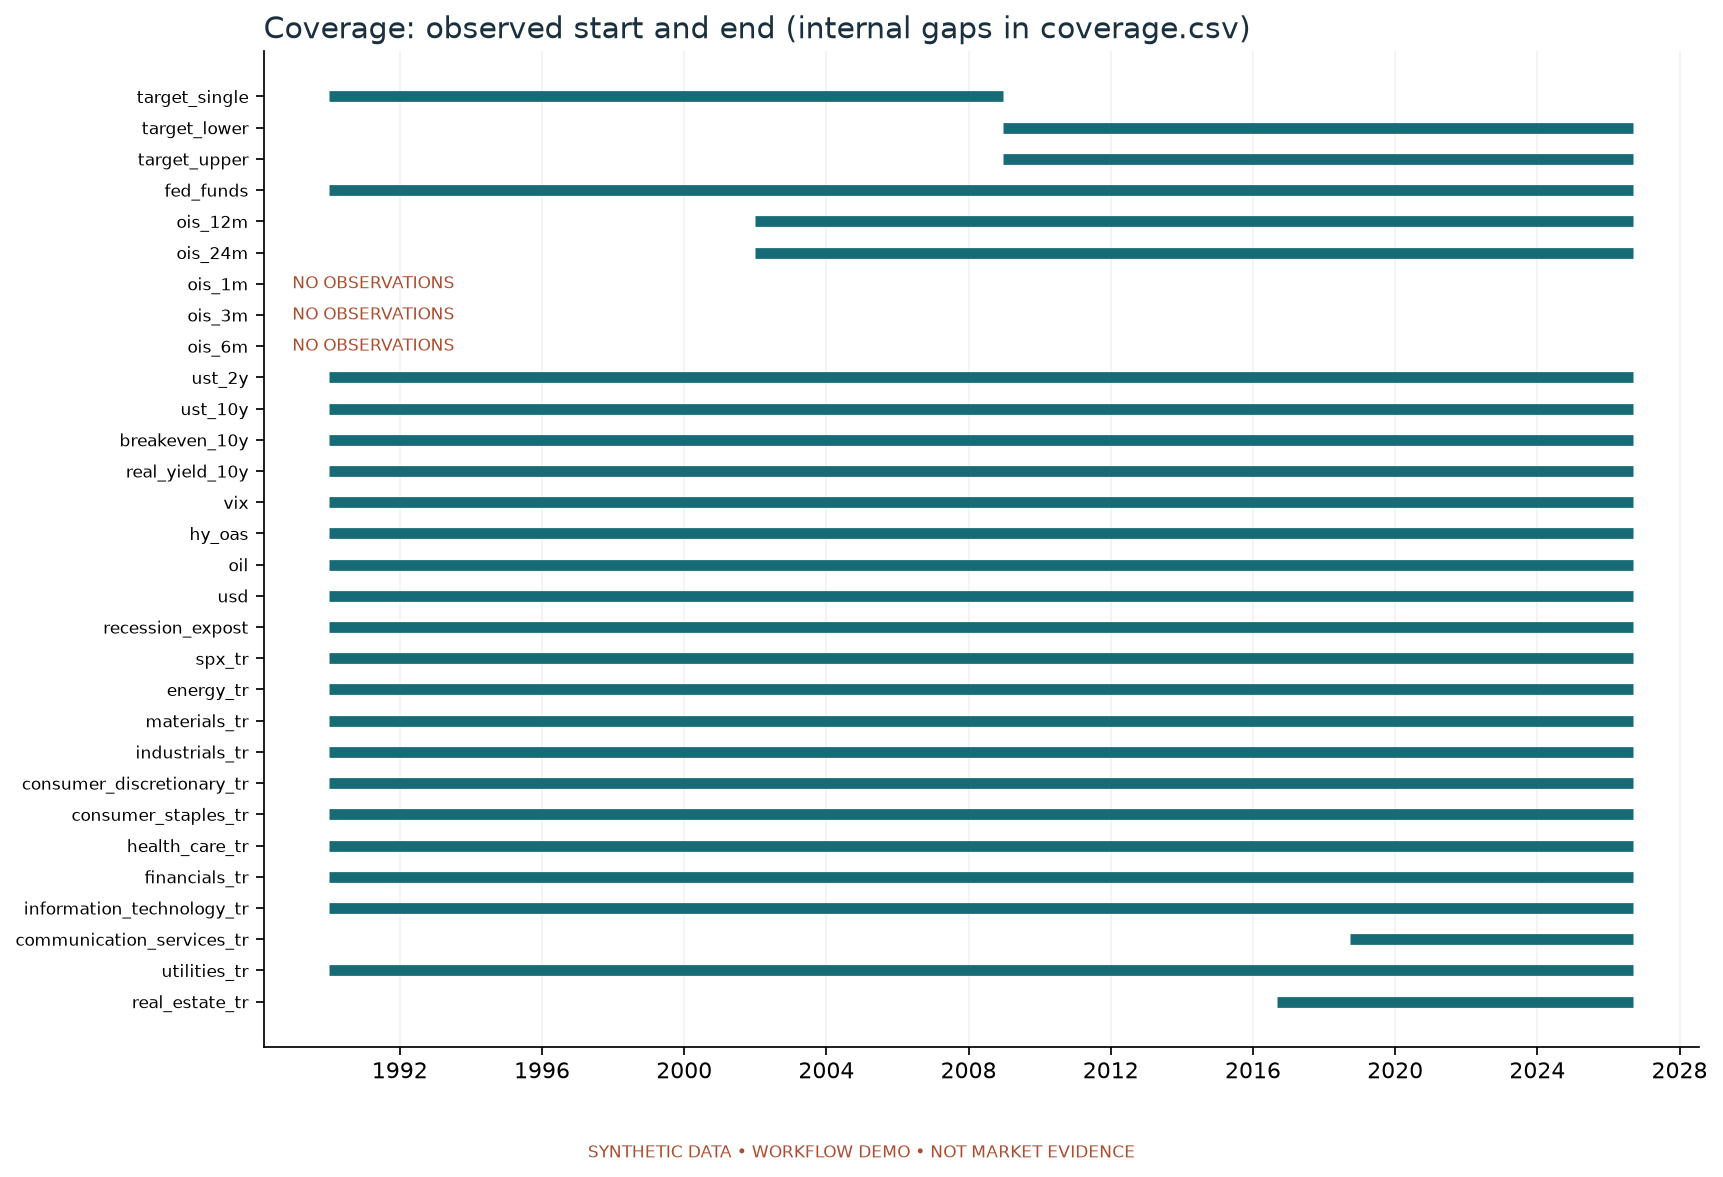

**SYNTHETIC_DEMO** · 利率与预期路径差：图中利差使用上一营业日 EFFR，降低发布时间前视风险；它仍不是会议 surprise。

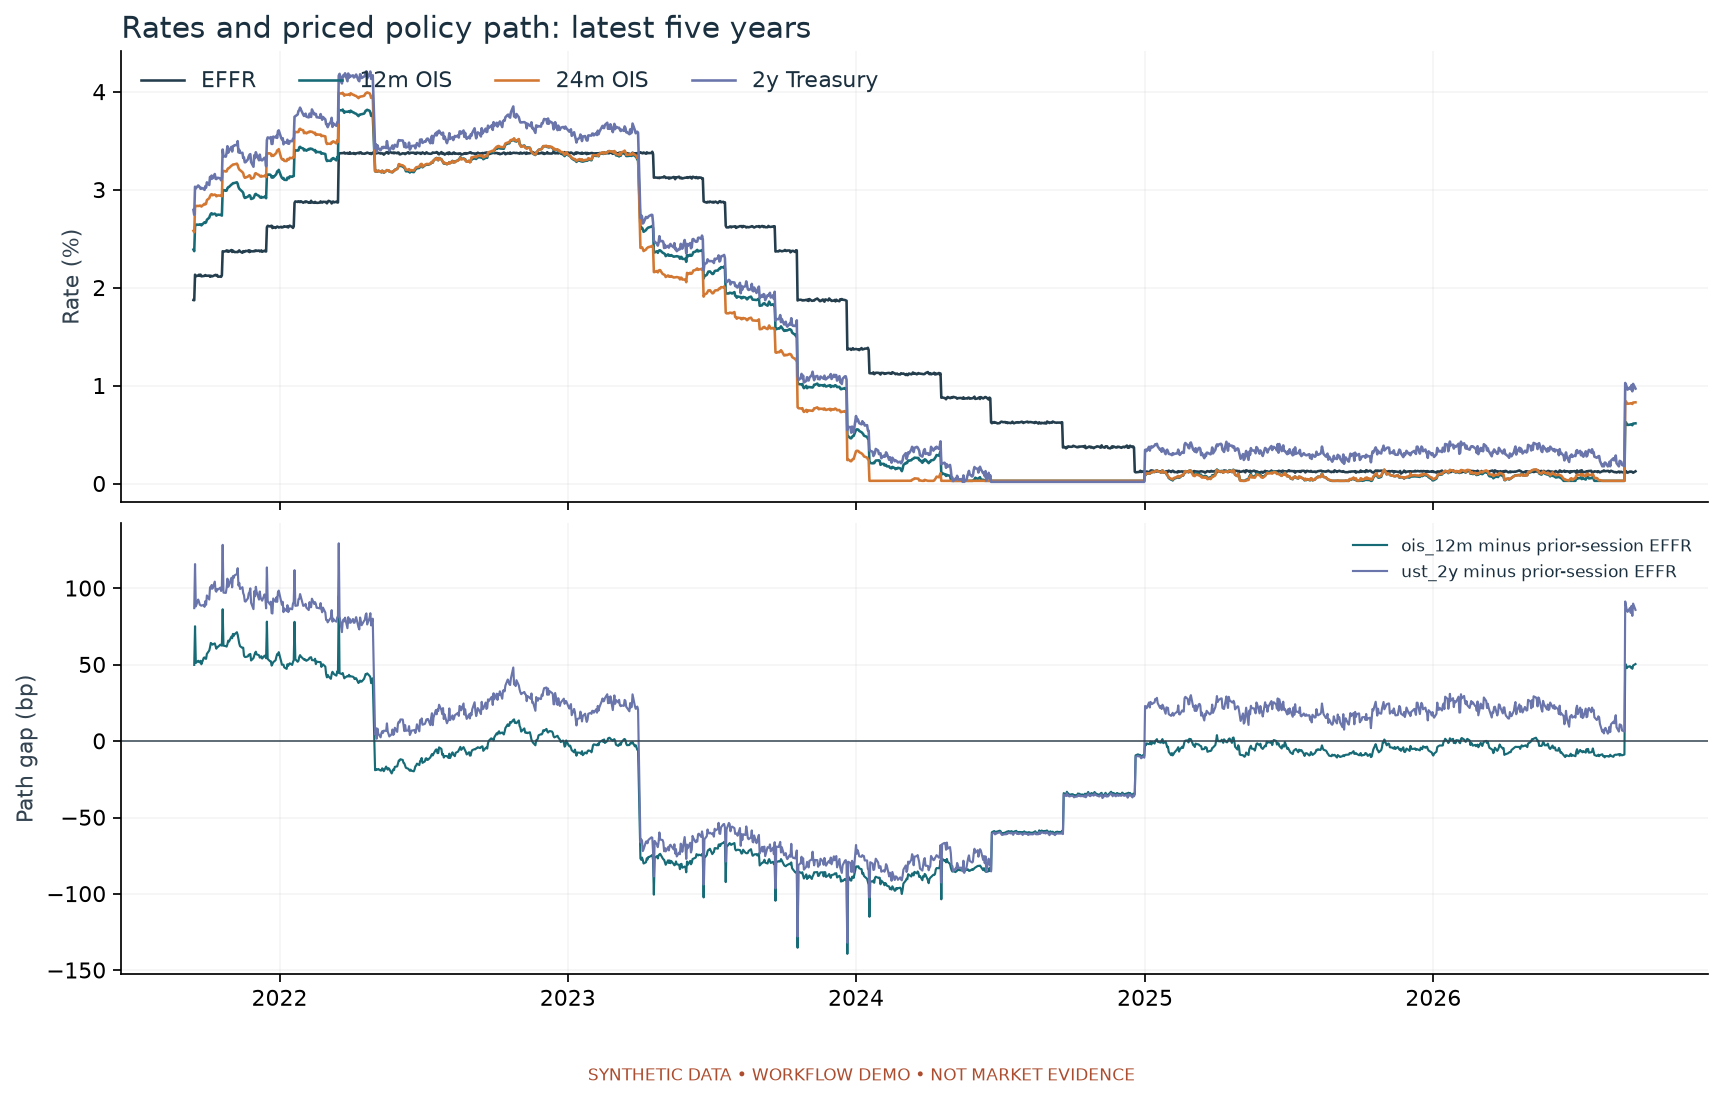

**SYNTHETIC_DEMO** · 相对财富：行业总收益增长倍数 ÷ SPX 总收益增长倍数 − 1；每条曲线从窗口内首个共同有效日归零。

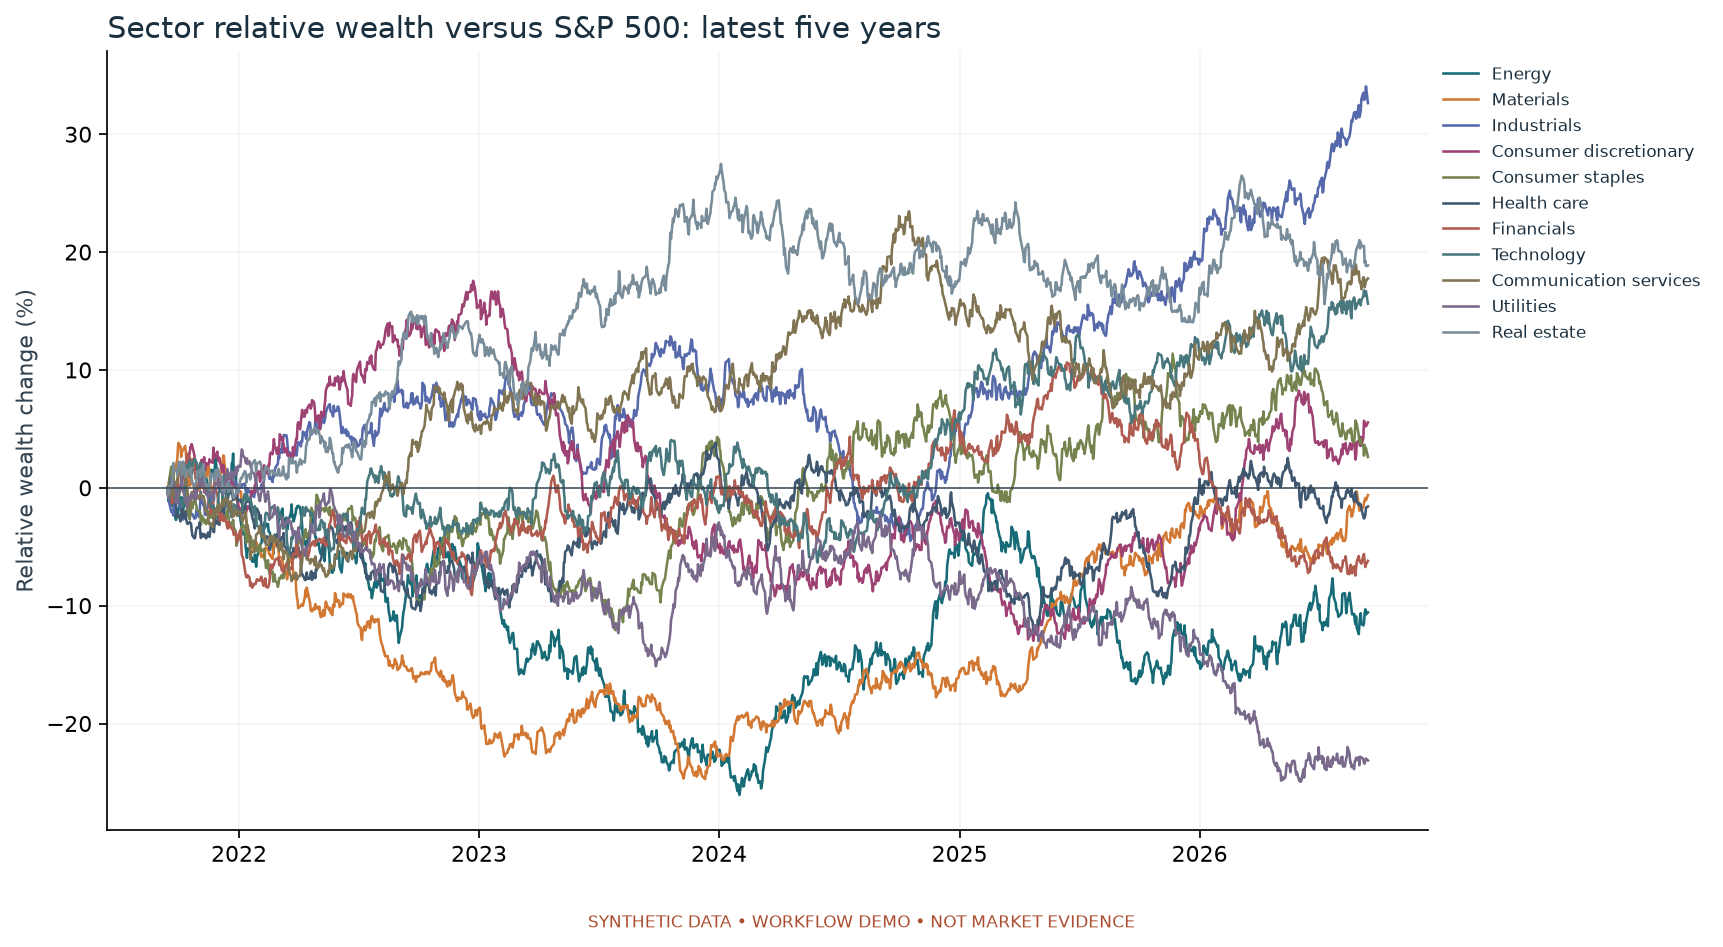

**SYNTHETIC_DEMO** · 周期描述热力图：先复利计算未来三个月收益，再减 SPX；未控制 recession，样本可能重叠，行业历史也不一致。

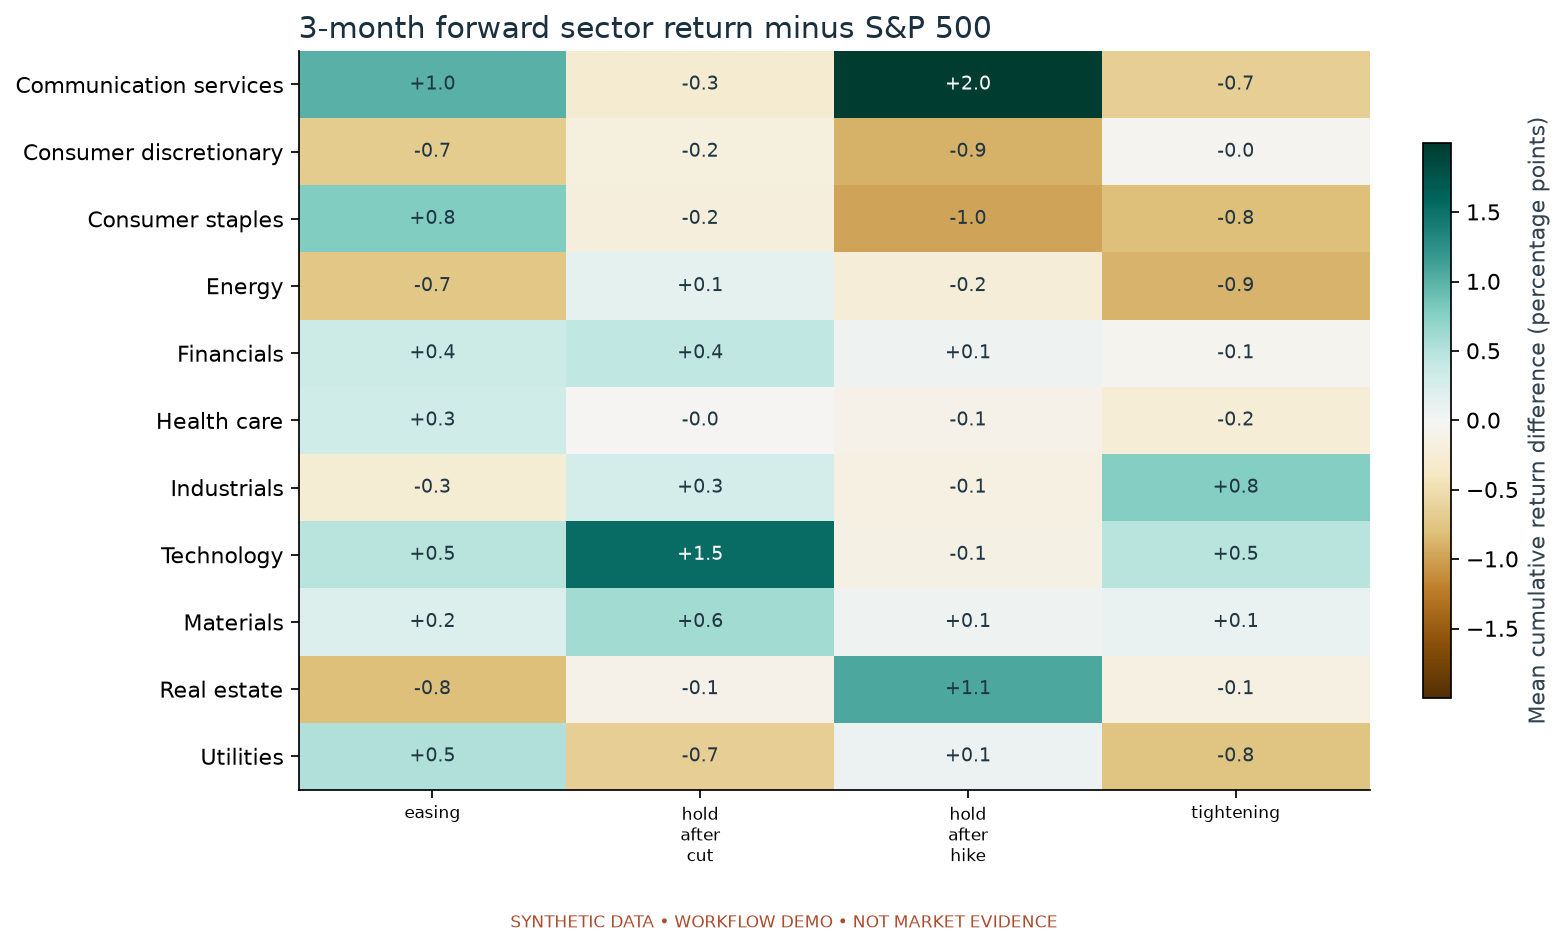

**SYNTHETIC_DEMO** · 同样本增量解释力：利率组含 gap、重定价和实际政策变化；组内变量数量不同，不能据此断言因果主导。SPX 行是绝对收益，其余是相对收益。

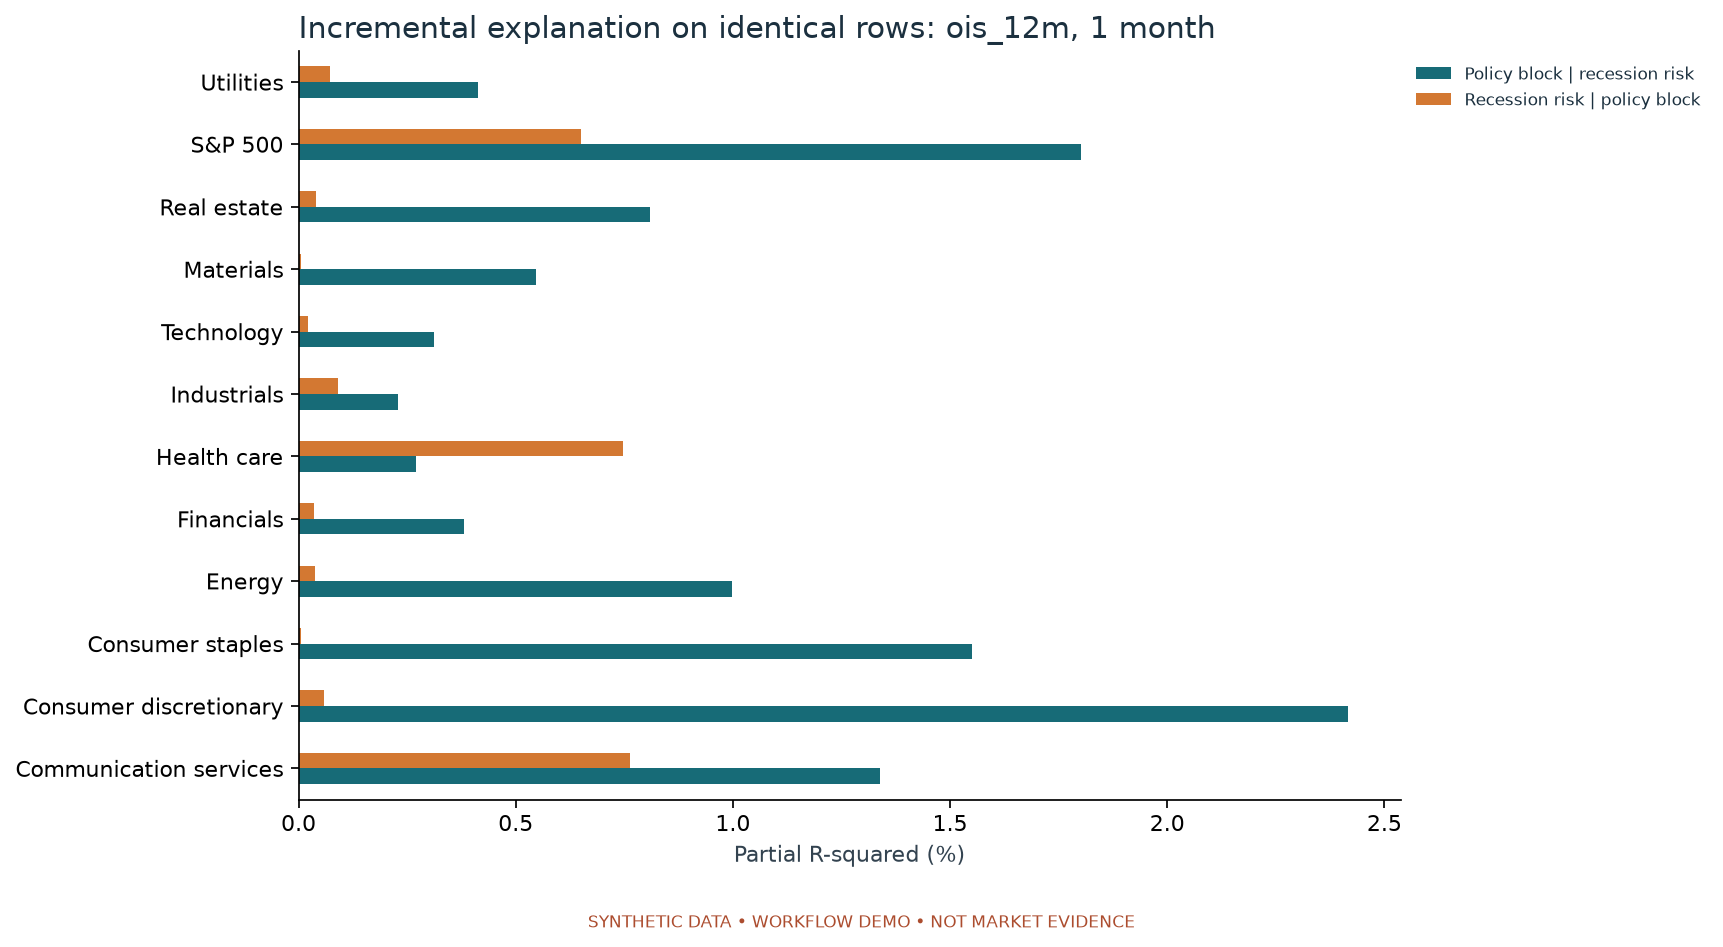

**SYNTHETIC_DEMO** · 事件回归：前收盘至公告当日收盘；不是分时因果冲击。若含 risk 交互，图中主系数对应 risk=0。少周期时 HC3 仅作探索，区间未经多重检验调整。

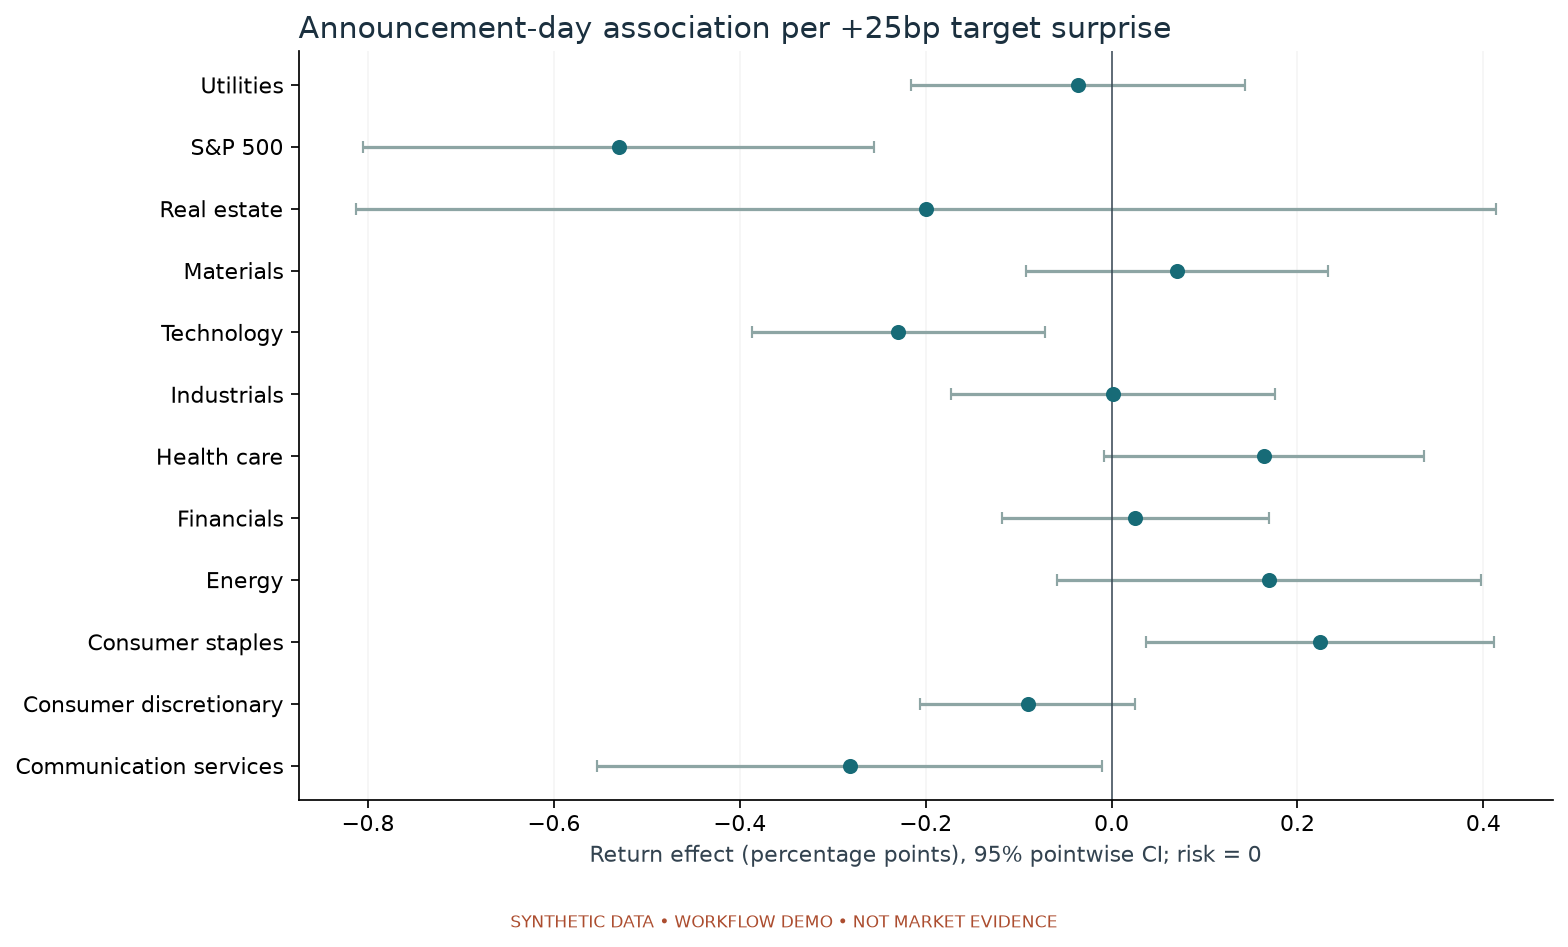

**SYNTHETIC_DEMO** · 样本外预测：负 R² 表示不如训练期均值。训练标签须在预测时点前实现；这是预测评估，尚未加入可执行入场价格、交易成本或组合约束。

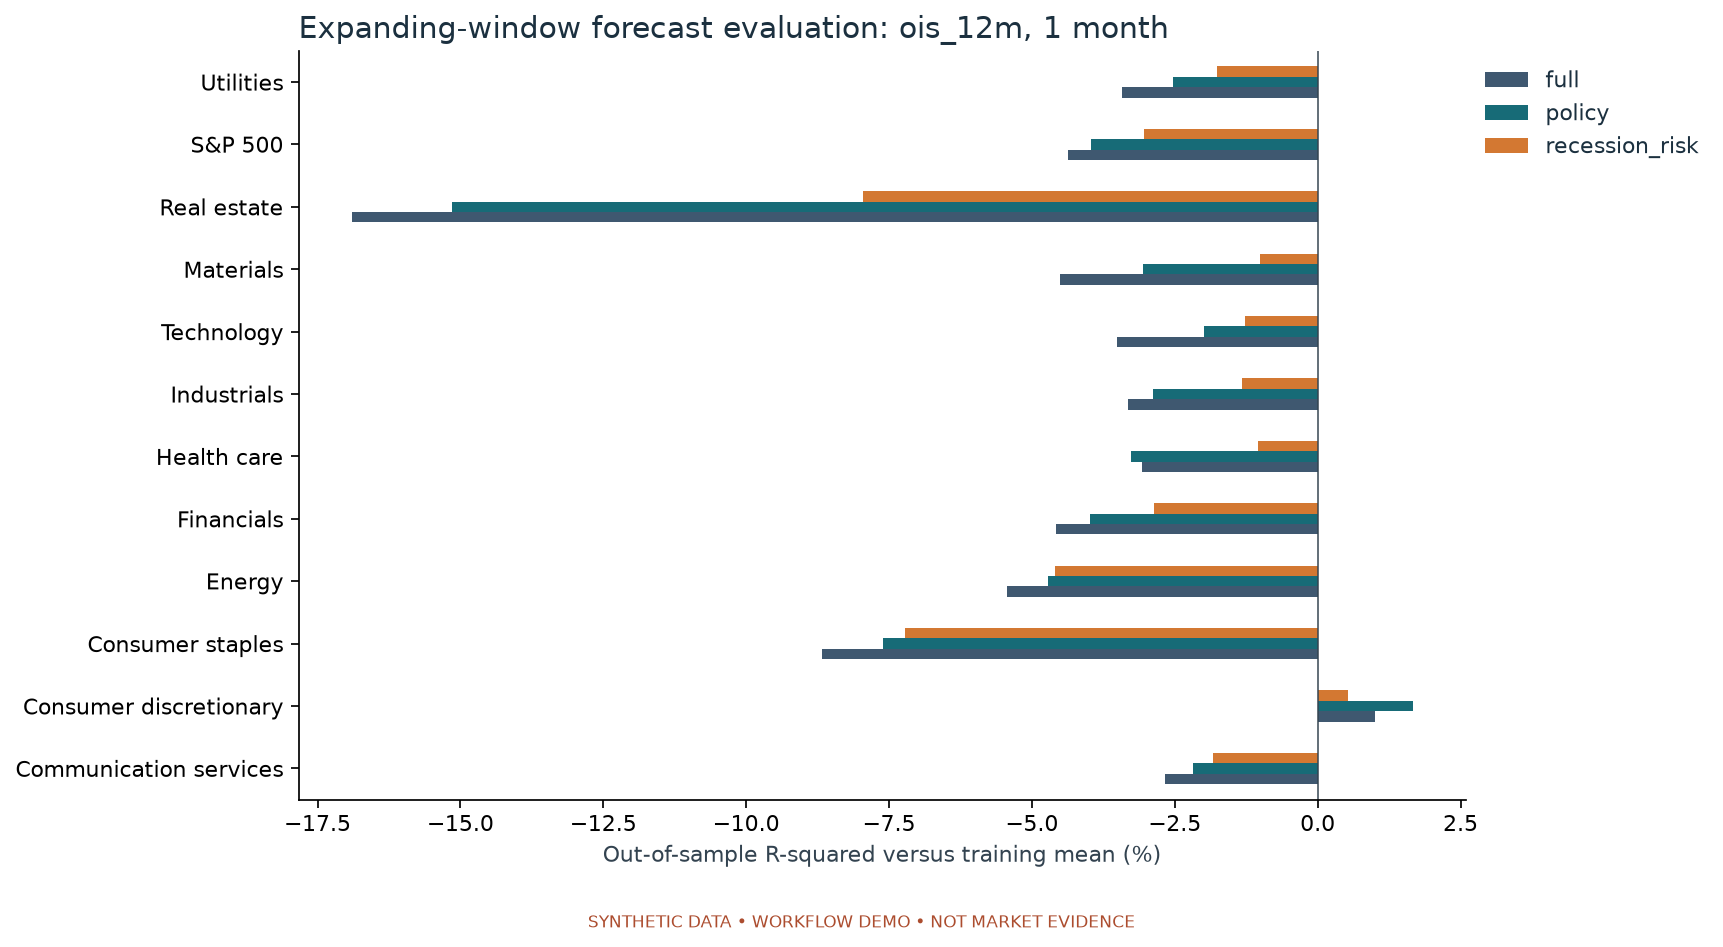

离线交互HTML: /private/var/folders/v5/_fg6d6fj243fh0kt8r14pjpw0000gn/T/rate_notebook_verify_lmzwtwwo/interest_rate_results/outputs/demo/report.html
全部表格Excel: /private/var/folders/v5/_fg6d6fj243fh0kt8r14pjpw0000gn/T/rate_notebook_verify_lmzwtwwo/interest_rate_results/outputs/demo/study_tables.xlsx
逐表CSV: /private/var/folders/v5/_fg6d6fj243fh0kt8r14pjpw0000gn/T/rate_notebook_verify_lmzwtwwo/interest_rate_results/outputs/demo/tables


In [15]:
export_tables(tables, OUTPUT_DIR, provenance)
charts = create_charts(daily, tables, OUTPUT_DIR / "charts", IS_SYNTHETIC)
report_path = write_report(daily, tables, OUTPUT_DIR, provenance, charts)
for caption, path in charts:
    display(Markdown("**" + DATA_KIND + "** · " + caption))
    display(Image(filename=str(path)))
print("离线交互HTML:",report_path)
print("全部表格Excel:",OUTPUT_DIR / "study_tables.xlsx")
print("逐表CSV:",OUTPUT_DIR / "tables")


### 8.1 重点结果表

模拟数值不用于投资解读。换成真数据后，先读样本起止、观测数、周期数、置信区间和 FDR，再看系数。
OIS / 2Y 的正式测度比较看 `matched_proxy_*`；各自长历史结果看 `monthly_models`，不要把不同年代的 p 值直接比较。

In [16]:
def preview(name, n=18):
    frame=tables[name].copy()
    display(Markdown("**"+name+" · "+DATA_KIND+"**"))
    if frame.empty:
        display(Markdown("无足够有效数据，未估计。请核查输入与 data_quality。"))
    else:
        frame.insert(0,"data_kind",DATA_KIND)
        display(frame.head(n))

for name in ["first_hike_summary","incremental_models","matched_proxy_models",
             "matched_proxy_oos_scores","event_summary","event_models","data_quality"]:
    preview(name)


**first_hike_summary · SYNTHETIC_DEMO**

,data_kind,sector,return_kind,horizon_months,event_definition,n_months,n_policy_phases,mean_response,median_response,response_positive_fraction,mean_absolute_return,mean_arithmetic_excess_return,mean_relative_wealth_return,mean_beta_adjusted_return,inference_note
0,SYNTHETIC_DEMO,communication_services,relative_to_spx,1,first_hike_after_pause_180d,1,1,-0.012934,-0.012934,0.000000,-0.019654,-0.012934,-0.013022,-0.014582,descriptive; overlapping horizons; phases are ...
1,SYNTHETIC_DEMO,communication_services,relative_to_spx,3,first_hike_after_pause_180d,1,1,-0.011937,-0.011937,0.000000,-0.105330,-0.011937,-0.013166,-0.034829,descriptive; overlapping horizons; phases are ...
2,SYNTHETIC_DEMO,communication_services,relative_to_spx,6,first_hike_after_pause_180d,1,1,0.019283,0.019283,1.000000,-0.048993,0.019283,0.020696,0.002548,descriptive; overlapping horizons; phases are ...
3,SYNTHETIC_DEMO,communication_services,relative_to_spx,12,first_hike_after_pause_180d,1,1,0.028289,0.028289,1.000000,0.027030,0.028289,0.028324,0.027980,descriptive; overlapping horizons; phases are ...
4,SYNTHETIC_DEMO,consumer_discretionary,relative_to_spx,1,first_hike_after_pause_180d,7,6,-0.011990,-0.014269,0.285714,-0.009679,-0.011990,-0.011979,-0.011989,descriptive; overlapping horizons; phases are ...
5,SYNTHETIC_DEMO,consumer_discretionary,relative_to_spx,3,first_hike_after_pause_180d,7,6,-0.029278,-0.037603,0.142857,0.002713,-0.029278,-0.028851,-0.039993,descriptive; overlapping horizons; phases are ...
6,SYNTHETIC_DEMO,consumer_discretionary,relative_to_spx,6,first_hike_after_pause_180d,7,6,-0.060638,-0.059524,0.000000,-0.039099,-0.060638,-0.059393,-0.068452,descriptive; overlapping horizons; phases are ...
7,SYNTHETIC_DEMO,consumer_discretionary,relative_to_spx,12,first_hike_after_pause_180d,7,6,-0.093947,-0.089343,0.000000,-0.084140,-0.093947,-0.091216,-0.106917,descriptive; overlapping horizons; phases are ...
8,SYNTHETIC_DEMO,consumer_staples,relative_to_spx,1,first_hike_after_pause_180d,7,6,-0.006174,0.002284,0.571429,-0.003863,-0.006174,-0.006250,-0.001753,descriptive; overlapping horizons; phases are ...
9,SYNTHETIC_DEMO,consumer_staples,relative_to_spx,3,first_hike_after_pause_180d,7,6,-0.011355,-0.043511,0.428571,0.020636,-0.011355,-0.010634,0.003814,descriptive; overlapping horizons; phases are ...


**incremental_models · SYNTHETIC_DEMO**

,data_kind,specification,proxy,sector,horizon_months,return_kind,covariance,hac_lags,sample_start,sample_end,interpretation,block,n_observations,partial_r_squared,full_r_squared,reduced_r_squared,wald_statistic,p_value,comparison_note,p_value_bh
0,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,communication_services,1,relative_to_spx,HAC,3,2018-09,2026-07,conditional association; not causal,policy_given_recession_risk,95,0.013375,0.030233,0.017086,0.383161,0.765382,Different block sizes: partial R2 and p-values...,0.962884
1,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,communication_services,1,relative_to_spx,HAC,3,2018-09,2026-07,conditional association; not causal,recession_risk_given_policy,95,0.007621,0.030233,0.022785,0.737457,0.392810,Different block sizes: partial R2 and p-values...,0.962884
2,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,communication_services,3,relative_to_spx,HAC,3,2018-09,2026-05,conditional association; not causal,policy_given_recession_risk,93,0.018271,0.035920,0.017978,0.413426,0.743777,Different block sizes: partial R2 and p-values...,0.962884
3,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,communication_services,3,relative_to_spx,HAC,3,2018-09,2026-05,conditional association; not causal,recession_risk_given_policy,93,0.000008,0.035920,0.035913,0.000506,0.982101,Different block sizes: partial R2 and p-values...,0.995527
4,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,communication_services,6,relative_to_spx,HAC,5,2018-09,2026-02,conditional association; not causal,policy_given_recession_risk,90,0.024642,0.100222,0.077490,0.374019,0.771956,Different block sizes: partial R2 and p-values...,0.962884
5,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,communication_services,6,relative_to_spx,HAC,5,2018-09,2026-02,conditional association; not causal,recession_risk_given_policy,90,0.027428,0.100222,0.074848,2.418446,0.123719,Different block sizes: partial R2 and p-values...,0.877249
6,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,communication_services,12,relative_to_spx,HAC,11,2018-09,2025-08,conditional association; not causal,policy_given_recession_risk,84,0.043975,0.074722,0.032161,2.077095,0.110139,Different block sizes: partial R2 and p-values...,0.845870
7,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,communication_services,12,relative_to_spx,HAC,11,2018-09,2025-08,conditional association; not causal,recession_risk_given_policy,84,0.003262,0.074722,0.071694,0.394141,0.531988,Different block sizes: partial R2 and p-values...,0.962884
8,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,consumer_discretionary,1,relative_to_spx,HAC,3,2002-02,2026-07,conditional association; not causal,policy_given_recession_risk,294,0.024168,0.042742,0.019034,3.136037,0.025870,Different block sizes: partial R2 and p-values...,0.413920
9,SYNTHETIC_DEMO,same_sample_incremental_blocks,ois_12m,consumer_discretionary,1,relative_to_spx,HAC,3,2002-02,2026-07,conditional association; not causal,recession_risk_given_policy,294,0.000591,0.042742,0.042176,0.179872,0.671801,Different block sizes: partial R2 and p-values...,0.962884


**matched_proxy_models · SYNTHETIC_DEMO**

...

,data_kind,sector,return_kind,horizon_sessions_after_announcement,surprise_bucket,n_events,n_cycles,mean_response,median_response,positive_fraction,mean_absolute_return,mean_arithmetic_excess_return,mean_pre_window_absolute_return,mean_pre_window_arithmetic_excess_return,n_windows_containing_another_event,n_first_hike_after_pause_180d,n_first_hike_after_no_hike_180d,inference_note
0,SYNTHETIC_DEMO,communication_services,relative_to_spx,0,dovish_below_minus_5bp,5,1,0.001893,0.001731,0.800000,-0.006242,0.001893,0.018987,0.003689,0,0,0,descriptive; an anticipated 25bp hike may fall...
1,SYNTHETIC_DEMO,communication_services,relative_to_spx,0,hawkish_above_5bp,5,1,-0.003731,-0.003204,0.200000,-0.010530,-0.003731,0.036361,0.014768,0,0,0,descriptive; an anticipated 25bp hike may fall...
2,SYNTHETIC_DEMO,communication_services,relative_to_spx,0,within_plus_minus_5bp,53,3,0.000192,-0.000421,0.433962,0.001226,0.000192,0.018092,0.001656,0,1,1,descriptive; an anticipated 25bp hike may fall...
3,SYNTHETIC_DEMO,communication_services,relative_to_spx,1,dovish_below_minus_5bp,5,1,0.001162,0.002956,0.600000,-0.007943,0.001162,0.018987,0.003689,0,0,0,descriptive; an anticipated 25bp hike may fall...
4,SYNTHETIC_DEMO,communication_services,relative_to_spx,1,hawkish_above_5bp,5,1,-0.003072,-0.003176,0.000000,-0.019492,-0.003072,0.036361,0.014768,0,0,0,descriptive; an anticipated 25bp hike may fall...
5,SYNTHETIC_DEMO,communication_services,relative_to_spx,1,within_plus_minus_5bp,53,3,-0.000379,-0.000982,0.433962,0.002688,-0.000379,0.018092,0.001656,0,1,1,descriptive; an anticipated 25bp hike may fall...
6,SYNTHETIC_DEMO,communication_services,relative_to_spx,5,dovish_below_minus_5bp,5,1,-0.001234,0.001242,0.600000,-0.017474,-0.001234,0.018987,0.003689,0,0,0,descriptive; an anticipated 25bp hike may fall...
7,SYNTHETIC_DEMO,communication_services,relative_to_spx,5,hawkish_above_5bp,5,1,-0.011889,-0.016254,0.200000,-0.046628,-0.011889,0.036361,0.014768,0,0,0,descriptive; an anticipated 25bp hike may fall...
8,SYNTHETIC_DEMO,communication_services,relative_to_spx,5,within_plus_minus_5bp,53,3,0.001082,0.000550,0.528302,0.006911,0.001082,0.018092,0.001656,0,1,1,descriptive; an anticipated 25bp hike may fall...
9,SYNTHETIC_DEMO,communication_services,relative_to_spx,21,dovish_below_minus_5bp,5,1,-0.001228,-0.001348,0.400000,-0.012860,-0.001228,0.018987,0.003689,1,0,0,descriptive; an anticipated 25bp hike may fall...


**event_models · SYNTHETIC_DEMO**

,data_kind,specification,sector,return_kind,horizon_sessions_after_announcement,n_cycles,covariance,inference_note,term,coefficient,std_error,p_value,ci_lower,ci_upper,coefficient_per_25bp,standardized_coefficient,n_observations,r_squared,p_value_bh
0,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,0,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,const,0.000548,0.000822,0.507919,-0.001098,0.002193,NaN,NaN,63,0.184838,NaN
1,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,0,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,target_surprise_bp,-0.000113,0.000054,0.042223,-0.000221,-0.000004,-0.002818,-0.268024,63,0.184838,0.405339
2,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,0,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,path_surprise_bp,-0.000173,0.000052,0.001534,-0.000278,-0.000069,-0.004334,-0.339184,63,0.184838,0.049075
3,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,0,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,recession_risk,-0.001437,0.004032,0.722817,-0.009508,0.006634,NaN,-0.065428,63,0.184838,0.972966
4,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,0,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,surprise_x_recession_risk,-0.000020,0.000272,0.941456,-0.000565,0.000525,NaN,-0.019851,63,0.184838,0.992721
5,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,1,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,const,-0.000692,0.001004,0.493220,-0.002701,0.001317,NaN,NaN,63,0.126341,NaN
6,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,1,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,target_surprise_bp,-0.000180,0.000100,0.078119,-0.000381,0.000021,-0.004500,-0.349837,63,0.126341,0.473880
7,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,1,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,path_surprise_bp,-0.000171,0.000070,0.017688,-0.000312,-0.000031,-0.004280,-0.273834,63,0.126341,0.305832
8,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,1,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,recession_risk,0.002403,0.004045,0.554679,-0.005693,0.010500,NaN,0.089459,63,0.126341,0.894945
9,SYNTHETIC_DEMO,event_target_path_risk,communication_services,relative_to_spx,1,3,HC3_few_or_missing_cycles,Fewer than 10 complete clusters: HC3 is explor...,surprise_x_recession_risk,0.000312,0.000272,0.255960,-0.000232,0.000856,NaN,0.252345,63,0.126341,0.763533


**data_quality · SYNTHETIC_DEMO**

,data_kind,check,series,first_observation,last_observation,n_valid,missing_fraction,note
0,SYNTHETIC_DEMO,series_coverage,target_single,1990-01-01,2008-12-15,4946.0,0.483500,No backward fill; short histories do not exten...
1,SYNTHETIC_DEMO,series_coverage,target_lower,2008-12-16,2026-09-14,4630.0,0.516500,No backward fill; short histories do not exten...
2,SYNTHETIC_DEMO,series_coverage,target_upper,2008-12-16,2026-09-14,4630.0,0.516500,No backward fill; short histories do not exten...
3,SYNTHETIC_DEMO,series_coverage,fed_funds,1990-01-01,2026-09-14,9576.0,0.000000,No backward fill; short histories do not exten...
4,SYNTHETIC_DEMO,series_coverage,ois_12m,2002-01-01,2026-09-14,6445.0,0.326963,No backward fill; short histories do not exten...
5,SYNTHETIC_DEMO,series_coverage,ois_24m,2002-01-01,2026-09-14,6445.0,0.326963,No backward fill; short histories do not exten...
6,SYNTHETIC_DEMO,series_coverage,ois_1m,NaT,NaT,0.0,1.000000,No backward fill; short histories do not exten...
7,SYNTHETIC_DEMO,series_coverage,ois_3m,NaT,NaT,0.0,1.000000,No backward fill; short histories do not exten...
8,SYNTHETIC_DEMO,series_coverage,ois_6m,NaT,NaT,0.0,1.000000,No backward fill; short histories do not exten...
9,SYNTHETIC_DEMO,series_coverage,ust_2y,1990-01-01,2026-09-14,9576.0,0.000000,No backward fill; short histories do not exten...


## 9. 如何读出投资意义

1. 先确定会议与概率快照；“加息兑现”与“超预期紧缩”分开。90% 的 25bp 情景只带来 +2.5bp 目标 surprise，后续路径消息可能更重要。
2. 把行业反应放到增长、通胀、曲线和信用环境里解释。银行的净息差收益可能被存款成本和信用损失抵消；科技/REIT 的久期压力也可能被盈利增长抵消。这里是待检验机制。
3. 利率与 recession 的比较看同样本增量解释力、经济效应和样本外改善。不同变量组大小会影响 partial R²；显著性不是因果强弱。
4. 对现有持仓先做情景与暴露分析，再考虑轮动。跨周期不稳定、加入成本后消失、依赖事后 recession 标签的结果，不能升级为交易信号。

**接入真实数据后的优先顺序：** 核验 total return 与 OIS benchmark → 检查 raw coverage/errors → 补齐历史公告和会前预期 → 补齐按可得日期组织的 macro → 再运行并解释系数。缺少会议预期时，月频研究仍可运行，但不会生成假的 policy surprise。

本 Notebook 已执行的检查只能覆盖明确测试的路径；Bloomberg 连接、权限、候选 ticker 和字段经济含义仍需在你的终端环境验证。